# 02 · Models and Evaluation (Mô hình, đánh giá và kết luận)

This notebook uses the verified feature dataset from Notebook 01
to compare forecasting methods, evaluate low-speed warnings,
examine vehicle-composition features and spatial transfer, and
explain model predictions. Empirical conclusions are written
only after the experiments have been executed and reviewed.

(Notebook này sử dụng bảng đặc trưng đã kiểm chứng từ Notebook 01
để so sánh phương pháp dự báo, đánh giá cảnh báo tốc độ thấp,
xem xét đóng góp của thành phần xe và khả năng chuyển giao
không gian, đồng thời giải thích dự đoán. Kết luận thực nghiệm
chỉ được viết sau khi chạy và rà soát kết quả.)

## Contents (Mục lục)

1. [Modelling design and environment
   (Thiết kế mô hình và môi trường)](#models)
2. [RQ2: forecasting comparison and validation
   (RQ2: so sánh dự báo và validation)](#rq2)
3. [RQ3: warning, ablation and spatial transfer
   (RQ3: cảnh báo, bỏ biến và chuyển giao không gian)](#rq3)
4. [SHAP and diagnosis
   (SHAP và chẩn đoán)](#explain)
5. [Evidence and conclusions
   (Bằng chứng và kết luận)](#paper)

## Data dependency and setup (Đầu vào dữ liệu và thiết lập)

Notebook 02 reads `feat.parquet` and `manifest.json` produced
by Notebook 01 under the same `PROJECT_ROOT` and `RUN_ID`.
It does not repeat raw-trajectory processing.

(Notebook 02 đọc `feat.parquet` và `manifest.json` do Notebook 01
tạo ra trong cùng `PROJECT_ROOT` và `RUN_ID`. Không lặp lại
quá trình xử lý quỹ đạo thô.)

The current study uses recordings from 24, 29 and 30 October
and 1 November 2018, aggregated into 100 m × 100 m cells
in EPSG:32634 and 10-second intervals.

(Nghiên cứu hiện tại sử dụng các lần ghi hình ngày 24, 29,
30/10 và 01/11/2018, tổng hợp theo ô 100 m × 100 m trong
EPSG:32634 và khoảng thời gian 10 giây.)

The environment section installs missing dependencies and records
the software versions used. Before modelling, the handover checks
verify file integrity, configuration, required columns and unique
recording–cell–time keys. Missing inputs require checking the
configured paths and the Notebook 01 export.

(Phần môi trường cài thư viện còn thiếu và ghi nhận phiên bản
được sử dụng. Trước khi mô hình hóa, bước kiểm tra bàn giao xác
minh tính toàn vẹn của file, cấu hình, các cột cần thiết và khóa
lần ghi hình–ô–thời gian duy nhất. Khi thiếu đầu vào, cần kiểm tra
đường dẫn cấu hình và kết quả xuất từ Notebook 01.)

A matching checksum confirms consistency with the saved manifest.
It does not, by itself, prove the absence of data leakage or
establish scientific validity.

(Mã băm khớp xác nhận tính nhất quán với manifest đã lưu.
Riêng kiểm tra này chưa chứng minh không có rò rỉ dữ liệu
hoặc bảo đảm tính đúng đắn khoa học.)

<a id="models"></a>

# Part I · Modelling design (Phần I · Thiết kế mô hình)

## From observations to forecasting examples
## Từ quan sát đến mẫu dự báo

Each example combines information available after the current
10-second interval has been observed with a target from a later
interval in the same recording and cell. Historical features
must refer to the specified time offsets, not merely preceding
row positions.

(Mỗi mẫu kết hợp thông tin đã có sau khi quan sát xong khoảng
10 giây hiện tại với nhãn ở một khoảng tương lai trong cùng
lần ghi hình và ô. Đặc trưng lịch sử phải lấy đúng độ lệch
thời gian, không chỉ dựa vào vị trí dòng đứng trước.)

The planned speed-forecasting comparison covers +30 and +60 seconds,
with +60 seconds as the primary horizon. Eligibility is evaluated
separately for each horizon. Future targets are used for fitting
on training data and scoring on test data; they are never predictors.

(Phép so sánh dự báo tốc độ theo thiết kế gồm hai mốc +30 và +60 giây,
trong đó +60 giây là mốc chính. Điều kiện mẫu được xét riêng cho
từng mốc. Nhãn tương lai dùng để học trên train và chấm điểm trên
test; không được đưa vào biến dự báo.)

Missing historical observations or future targets are not filled
using future information. Eligible sample counts are reported
after applying the relevant requirements.

(Không dùng thông tin tương lai để điền quan sát lịch sử hoặc
nhãn tương lai bị thiếu. Số mẫu đủ điều kiện được báo cáo sau
khi áp dụng các yêu cầu tương ứng.)

## Fair comparison (Nguyên tắc so sánh)

Within each horizon, all five methods are evaluated on the same
eligible test rows and the same held-out recordings. The recording
split is shared across horizons, although eligible row counts
may differ.

(Trong từng mốc, cả năm phương pháp được đánh giá trên cùng
các dòng test đủ điều kiện và cùng các lần ghi hình giữ riêng.
Hai mốc dùng chung cách chia recording, nhưng số dòng đủ điều kiện
có thể khác nhau.)

The input representations differ: Persistence uses current speed;
LTSF-Linear uses six consecutive speed observations; the tabular
models use the declared traffic and spatial features. The comparison
therefore evaluates each method together with its inputs, rather
than isolating architecture alone.

(Cách biểu diễn đầu vào khác nhau: Persistence dùng tốc độ hiện tại;
LTSF-Linear dùng sáu quan sát tốc độ liên tiếp; các mô hình dạng bảng
dùng những đặc trưng giao thông và không gian đã khai báo. Vì vậy,
phép so sánh đánh giá từng phương pháp cùng đầu vào của nó, chưa
tách riêng tác động của kiến trúc.)

Learned preprocessing is fitted on training data only. Parameter
selection uses validation within the training recordings. Test
results do not determine preprocessing, hyperparameters or the
selection of a more favourable test subset.

(Các bước tiền xử lý cần học tham số chỉ được fit trên train.
Việc chọn tham số dùng validation trong các lần ghi hình train.
Kết quả test không được dùng để quyết định tiền xử lý, siêu tham số
hoặc chọn lại tập test thuận lợi hơn.)

Separating recording identifiers prevents the same recording from
appearing in both sets. It does not automatically guarantee
independence between simultaneous recordings, nearby cells or
recordings from the same date.

(Tách mã recording ngăn cùng một lần ghi hình xuất hiện trong
cả hai tập. Điều này không tự bảo đảm tính độc lập giữa các lần
ghi hình đồng thời, các ô gần nhau hoặc các recording cùng ngày.)

## Five forecasting methods (Năm phương pháp dự báo)

| Method (Phương pháp) | Role and interpretation (Vai trò và diễn giải) |
|---|---|
| **Persistence** | Predicts future speed as current speed; no model is fitted. It is the reference for assessing added predictive value. (Dự báo tốc độ tương lai bằng tốc độ hiện tại; không huấn luyện. Đây là mốc để đánh giá giá trị dự báo tăng thêm.) |
| **Ridge** | A linear regression with a penalty on coefficient size. Scaling parameters are learned from training data. (Hồi quy tuyến tính có phạt độ lớn hệ số. Tham số chuẩn hóa được học từ train.) |
| **Random Forest** | Averages predictions from multiple decision trees to represent nonlinear relationships and interactions. (Lấy trung bình dự đoán từ nhiều cây quyết định để biểu diễn quan hệ phi tuyến và tương tác.) |
| **LightGBM** | Builds a sequence of trees that progressively improves the fitted prediction. Hyperparameters are selected using training-data validation. (Xây dựng chuỗi cây để cải thiện dần dự đoán đã học. Siêu tham số được chọn bằng validation trên dữ liệu train.) |
| **LTSF-Linear** | Maps six consecutive speed observations, `[s(t−50), …, s(t)]`, to one future speed using a trainable linear layer. This is the project's simple linear sequence baseline. (Ánh xạ sáu tốc độ liên tiếp sang một tốc độ tương lai bằng một lớp tuyến tính có thể học. Đây là baseline chuỗi tuyến tính đơn giản của dự án.) |

Spatial predictors must use correctly interpreted grid metadata.
The `cell` identifier contains projected grid indices; splitting
it does not produce latitude and longitude.

(Biến dự báo không gian phải sử dụng đúng thông tin lưới.
Mã `cell` chứa chỉ số lưới tọa độ phẳng; tách mã này không
tạo ra kinh độ và vĩ độ.)

The LTSF-Linear implementation is a specified project baseline,
not a claim to reproduce all settings or results of an external
forecasting benchmark.

(LTSF-Linear ở đây là baseline được định nghĩa cho dự án,
không phải tuyên bố tái lập toàn bộ thiết lập hoặc kết quả
của một benchmark dự báo bên ngoài.)

## Training and evaluation sequence (Trình tự huấn luyện và đánh giá)

1. Define the horizon, eligible rows, predictors and recording split.
   (Xác định mốc dự báo, mẫu đủ điều kiện, đầu vào và cách chia recording.)
2. Fit preprocessing and models using training data.
   (Fit tiền xử lý và mô hình bằng dữ liệu train.)
3. Use training-recording validation for parameter selection.
   (Dùng validation theo recording trong train để chọn tham số.)
4. Generate predictions for the fixed test rows.
   (Dự đoán trên các dòng test đã cố định.)
5. Report errors, training time, sample counts and results by seed.
   (Báo sai số, thời gian huấn luyện, số mẫu và kết quả theo seed.)
6. Inspect residuals and spatial variation without changing the test set.
   (Xem phần dư và khác biệt không gian mà không thay đổi tập test.)

Repeated training seeds use the same data split. Their standard
deviation measures sensitivity to training randomness, not
uncertainty across independent test datasets. Deterministic
methods may return identical results across seeds.

(Các seed huấn luyện lặp lại dùng cùng cách chia dữ liệu.
Độ lệch chuẩn đo độ nhạy với ngẫu nhiên khi huấn luyện, không
đo bất định trên những tập test độc lập. Phương pháp xác định
có thể cho kết quả giống nhau giữa các seed.)

## Reading MAE and RMSE (Đọc MAE và RMSE)

MAE is the mean absolute prediction error. RMSE is the square root
of the mean squared error and is more sensitive to large errors.
Both are reported in km/h; lower values indicate smaller errors.

(MAE là trung bình sai số tuyệt đối. RMSE là căn bậc hai của
trung bình sai số bình phương và nhạy hơn với sai số lớn.
Cả hai có đơn vị km/h; giá trị thấp hơn biểu thị sai số nhỏ hơn.)

For illustrative targets `[10, 20, 30]` and predictions
`[12, 17, 34]`, absolute errors are `[2, 3, 4]` km/h:
MAE = 3 km/h and RMSE ≈ 3.11 km/h.

(Với nhãn minh họa `[10, 20, 30]` và dự đoán `[12, 17, 34]`,
sai số tuyệt đối là `[2, 3, 4]` km/h:
MAE = 3 km/h và RMSE ≈ 3,11 km/h.)

These are teaching values, not experimental results.
Aggregate errors should be read alongside sample counts,
recording coverage and error distributions.

(Đây là số minh họa, không phải kết quả thực nghiệm.
Sai số tổng hợp cần được đọc cùng số mẫu, độ phủ recording
và phân phối sai số.)

## Validation and tuning (Validation và tinh chỉnh)

Validation folds are formed from training recordings. Each candidate
is fitted on part of the training recordings and evaluated on
other training recordings. Original and tuned configurations are
compared using the same validation folds.

(Các fold validation được tạo từ recording thuộc train.
Mỗi ứng viên học trên một phần recording train và được đánh giá
trên phần recording train còn lại. Cấu hình gốc và tuned được
so sánh bằng cùng các fold validation.)

A lower validation error does not guarantee a meaningful test gain.
Report the measured difference together with training variability
and computational cost.

(Sai số validation thấp hơn không bảo đảm cải thiện test có ý nghĩa
thực tế. Cần báo mức chênh lệch cùng dao động huấn luyện và
chi phí tính toán.)

The supplied tuning code currently uses different seeds for the
original and tuned LightGBM configurations. Until those seeds are
matched, their difference reflects both configuration and training
randomness, not the isolated effect of tuning.

(Code tuning hiện có dùng seed khác nhau cho cấu hình LightGBM
gốc và tuned. Khi chưa đồng nhất seed, chênh lệch phản ánh cả
cấu hình lẫn ngẫu nhiên huấn luyện, chưa tách riêng tác động
của tuning.)

## Environment (Môi trường)

This step detects required packages, installs missing ones and
checks that all required modules can actually be imported.
It includes the modelling, plotting, spatial and explanation tools
used later in this notebook.

(Bước này kiểm tra thư viện cần thiết, cài những thư viện còn thiếu
và kiểm tra khả năng import thực tế. Bao gồm các công cụ mô hình,
biểu đồ, không gian và giải thích được dùng phía sau.)

Existing packages are not explicitly upgraded. Installing missing
packages may also install or update their dependencies.
The active package versions are displayed for inspection and
will be recorded after the project paths are configured.

(Không chủ động nâng cấp các thư viện đã có. Việc cài thư viện thiếu
có thể cài hoặc cập nhật thư viện phụ thuộc. Phiên bản đang dùng
được hiển thị để kiểm tra và sẽ được ghi lại sau khi cấu hình
đường dẫn dự án.)

Continue when the output reports `ENVIRONMENT CHECK PASSED`.
If an import fails, inspect the reported error. Restart the runtime
if required after installation, then rerun this cell.

(Tiếp tục khi đầu ra báo `ENVIRONMENT CHECK PASSED`.
Nếu import thất bại, xem lỗi được báo. Nếu việc cài đặt yêu cầu
khởi động lại phiên, thực hiện rồi chạy lại ô này.)

In [1]:
# Notebook 02 — dependencies and actual import checks.
# Run before configuration, shared tools and modelling.

import importlib
import importlib.metadata
import importlib.util
import subprocess
import sys

ENVIRONMENT_VERIFIED = False

# Import name -> package distribution name.
packages = {
    "numpy": "numpy",
    "pandas": "pandas",
    "pyarrow": "pyarrow",
    "duckdb": "duckdb",
    "matplotlib": "matplotlib",
    "seaborn": "seaborn",
    "scipy": "scipy",
    "sklearn": "scikit-learn",
    "lightgbm": "lightgbm",
    "torch": "torch",
    "shap": "shap",
    "joblib": "joblib",
    "threadpoolctl": "threadpoolctl",
    "pyproj": "pyproj",
    "contextily": "contextily",
    "rasterio": "rasterio",
    "xyzservices": "xyzservices",
    "IPython": "ipython",
}

print("Python:", sys.version.split()[0])
print("Checking Notebook 02 dependencies...")

missing_packages = []
for module, package in packages.items():
    try:
        available = importlib.util.find_spec(module) is not None
    except (ImportError, ModuleNotFoundError, ValueError):
        available = module in sys.modules

    if not available:
        missing_packages.append(package)

# Use the current notebook's Python environment.
# Do not request a blanket upgrade of existing packages.
if missing_packages:
    print("Installing missing packages:", ", ".join(missing_packages))
    try:
        subprocess.check_call([
            sys.executable,
            "-m", "pip", "install",
            "--disable-pip-version-check",
            *sorted(set(missing_packages)),
        ])
    except subprocess.CalledProcessError as exc:
        raise RuntimeError(
            "Cài thư viện thất bại. Kiểm tra thông báo phía trên "
            "trước khi chạy tiếp."
        ) from exc

    importlib.invalidate_caches()
else:
    print("Không thiếu thư viện trong danh sách.")

# Actual imports detect broken installations and binary incompatibilities.
versions = {}
import_errors = {}

for module, package in packages.items():
    try:
        importlib.import_module(module)
        versions[package] = importlib.metadata.version(package)
    except Exception as exc:
        import_errors[package] = f"{type(exc).__name__}: {exc}"

if import_errors:
    details = "\n".join(
        f"- {package}: {message}"
        for package, message in import_errors.items()
    )
    raise RuntimeError(
        "Chưa thể xác nhận môi trường:\n"
        + details
        + "\nNếu pip vừa thay đổi thư viện đã được nạp, "
          "cần khởi động lại runtime rồi chạy từ đầu. "
          "Không bỏ qua lỗi import."
    )

# Check the mapping interfaces used later, without downloading map tiles.
from pyproj import CRS, Transformer
import contextily as ctx

grid_crs_check = CRS.from_epsg(32634)
coordinate_check = Transformer.from_crs(
    "EPSG:4326", grid_crs_check, always_xy=True
)
test_x, test_y = coordinate_check.transform(23.73, 37.98)

import math
if not all(math.isfinite(value) for value in (test_x, test_y)):
    raise RuntimeError("Không chuyển đổi được tọa độ sang lưới mét.")

if not callable(ctx.add_basemap):
    raise RuntimeError("contextily không cung cấp hàm add_basemap.")

# Confirm that the configured basemap provider is available locally.
basemap_provider_check = ctx.providers.OpenStreetMap.Mapnik

import pandas as pd
from IPython.display import display

display(pd.DataFrame(
    sorted(versions.items()),
    columns=["package", "version"],
))

ENVIRONMENT_VERIFIED = True
print("ENVIRONMENT CHECK PASSED")
print("Đã kiểm tra import và công cụ chuyển đổi tọa độ.")
print("Tải nền đường tại bước vẽ vẫn cần kết nối mạng.")
print("Chưa nạp dữ liệu hoặc huấn luyện mô hình.")

Python: 3.13.15
Checking Notebook 02 dependencies...
Installing missing packages: contextily


,package,version
0,contextily,1.7.1
1,duckdb,1.3.2
2,ipython,7.34.0
3,joblib,1.6.0
4,lightgbm,4.6.0
5,matplotlib,3.10.0
6,numpy,2.1.3
7,pandas,2.2.3
8,pyarrow,23.0.1
9,pyproj,3.8.0


ENVIRONMENT CHECK PASSED
Đã kiểm tra import và công cụ chuyển đổi tọa độ.
Tải nền đường tại bước vẽ vẫn cần kết nối mạng.
Chưa nạp dữ liệu hoặc huấn luyện mô hình.


## Project configuration and data handover
## Cấu hình dự án và dữ liệu bàn giao

Notebook 02 uses the same `PROJECT_ROOT` and `RUN_ID` as
Notebook 01. The current run is `pneuma_4days_100m_v1`,
covering four recording dates with a 100 m grid in EPSG:32634
and 10-second intervals.

(Notebook 02 dùng cùng `PROJECT_ROOT` và `RUN_ID` với
Notebook 01. Lần chạy hiện tại là `pneuma_4days_100m_v1`,
gồm bốn ngày ghi hình, lưới 100 m trong EPSG:32634
và khoảng thời gian 10 giây.)

This step checks that the feature file and manifest exist and
that the manifest configuration matches the experiment.
File checksums and table contents are verified in the
subsequent handover-loading step.

(Bước này kiểm tra sự hiện diện của file đặc trưng và manifest,
đồng thời đối chiếu cấu hình manifest với thí nghiệm.
Mã băm và nội dung bảng được kiểm tra ở bước nạp bàn giao
phía sau.)

Notebook 02 writes its configuration separately as
`report/model_config_02.json`. It does not overwrite the
Notebook 01 configuration or reprocess raw trajectories.

(Notebook 02 lưu cấu hình riêng tại
`report/model_config_02.json`. Không ghi đè cấu hình
Notebook 01 hoặc xử lý lại quỹ đạo thô.)

Reports and models are saved under the current run directory.
Rerunning with the same output filenames may replace earlier
reports and models.

(Báo cáo và mô hình được lưu trong thư mục lần chạy hiện tại.
Chạy lại với cùng tên file đầu ra có thể thay thế báo cáo
và mô hình đã lưu trước đó.)

In [7]:
# Notebook 02 — project configuration and handover paths.

from pathlib import Path
import hashlib
import importlib.util
import importlib.metadata
import json
import platform


# ============================================================
# 1. Thông tin lần chạy
# ============================================================

NOTEBOOK_ID = "02"
NOTEBOOK_02_CONFIG_VERIFIED = False

# Phải khớp Notebook 01.
RUN_ID = "pneuma_4days_100m_v1"

# Để trống khi dùng đường dẫn Colab mặc định.
# Khi chạy ở máy khác, có thể điền đường dẫn tuyệt đối.
PROJECT_ROOT_OVERRIDE = ""

DATE_FILTER = [
    "20181024",
    "20181029",
    "20181030",
    "20181101",
]

GRID_CRS = "EPSG:32634"
GRID_SIZE_M = 100.0
GRID_ORIGIN_X_M = 0.0
GRID_ORIGIN_Y_M = 0.0

BIN_SECONDS = 10
MIN_CELL_RECORDS = 200

SEED = 42
MODEL_SEEDS = [0, 1, 2, 3, 4]
TEST_FLIGHT_FRACTION = 0.20

FORECAST_HORIZONS = {
    30: "y_30s",
    60: "y_60s",
}

PRIMARY_HORIZON_SECONDS = 60
TARGET_COL = FORECAST_HORIZONS[PRIMARY_HORIZON_SECONDS]

CONGESTION_SPEED_THRESHOLD = 10.0

DUCKDB_MEMORY_LIMIT = "2GB"
DUCKDB_THREADS = 2

# Không dùng lại cấu hình lưới theo độ từ code cũ.
globals().pop("GRID_DEG", None)


# ============================================================
# 2. Xác định môi trường và đường dẫn
# ============================================================

try:
    IN_COLAB = (
        importlib.util.find_spec("google.colab") is not None
    )
except (ModuleNotFoundError, ValueError):
    IN_COLAB = False

if IN_COLAB:
    from google.colab import drive

    if not Path("/content/drive/MyDrive").is_dir():
        drive.mount("/content/drive")

    default_root = Path(
        "/content/drive/MyDrive/PNEUMA_Nhom9_Research"
    )
else:
    default_root = (
        Path.home() / "Documents" / "PNEUMA_Nhom9_Research"
    )

if PROJECT_ROOT_OVERRIDE.strip():
    PROJECT_ROOT = Path(
        PROJECT_ROOT_OVERRIDE.strip()
    ).expanduser()

    if not PROJECT_ROOT.is_absolute():
        raise ValueError(
            "PROJECT_ROOT_OVERRIDE phải là đường dẫn tuyệt đối."
        )
else:
    PROJECT_ROOT = default_root

PROJECT_ROOT = PROJECT_ROOT.resolve()

PROJECT_DIR = PROJECT_ROOT / "runs" / RUN_ID
PROCESSED_DIR = PROJECT_DIR / "data" / "processed"
REPORT_DIR = PROJECT_DIR / "report"
MODEL_DIR = PROJECT_DIR / "models"

PANEL_FILE = PROCESSED_DIR / "pneuma.parquet"
FEATURE_FILE = PROCESSED_DIR / "feat.parquet"
MANIFEST_FILE = PROCESSED_DIR / "manifest.json"


# ============================================================
# 3. Hàm dùng chung
# ============================================================

def digest(path, algorithm="sha256"):
    checksum = hashlib.new(algorithm)

    with Path(path).open("rb") as reader:
        for block in iter(
            lambda: reader.read(8 * 1024 * 1024),
            b"",
        ):
            checksum.update(block)

    return checksum.hexdigest()


def save_json(path, value):
    path = Path(path)
    path.parent.mkdir(parents=True, exist_ok=True)

    path.write_text(
        json.dumps(
            value,
            ensure_ascii=False,
            indent=2,
            default=str,
        ),
        encoding="utf-8",
    )


# ============================================================
# 4. Kiểm tra file đầu vào
# ============================================================

missing_files = [
    str(path)
    for path in [FEATURE_FILE, MANIFEST_FILE]
    if not path.is_file()
]

if missing_files:
    raise FileNotFoundError(
        "Không tìm thấy đầy đủ dữ liệu bàn giao:\n"
        + "\n".join(missing_files)
        + "\nKiểm tra Drive, PROJECT_ROOT và RUN_ID trước. "
        "Không cần xử lý lại raw chỉ vì sai đường dẫn."
    )

with MANIFEST_FILE.open("r", encoding="utf-8") as reader:
    handover_config = json.load(reader)

if not isinstance(handover_config, dict):
    raise ValueError("Manifest phải chứa một đối tượng JSON.")

if handover_config.get("run_id") != RUN_ID:
    raise ValueError(
        "RUN_ID trong manifest không khớp Notebook 02."
    )

manifest_dates = handover_config.get("recording_dates")

if (
    not isinstance(manifest_dates, list)
    or sorted(map(str, manifest_dates)) != sorted(DATE_FILTER)
):
    raise ValueError(
        "Ngày ghi hình trong manifest không khớp.\n"
        f"Manifest: {manifest_dates}\n"
        f"Notebook 02: {DATE_FILTER}"
    )

if handover_config.get("grid_crs") != GRID_CRS:
    raise ValueError(
        "Hệ tọa độ trong manifest không khớp.\n"
        f"Manifest: {handover_config.get('grid_crs')}\n"
        f"Notebook 02: {GRID_CRS}"
    )

expected_numeric_config = {
    "grid_size_m": GRID_SIZE_M,
    "grid_origin_x_m": GRID_ORIGIN_X_M,
    "grid_origin_y_m": GRID_ORIGIN_Y_M,
    "bin_seconds": BIN_SECONDS,
}

for field, expected_value in expected_numeric_config.items():
    actual_value = handover_config.get(field)

    try:
        matches = float(actual_value) == float(expected_value)
    except (TypeError, ValueError, OverflowError):
        matches = False

    if not matches:
        raise ValueError(
            f"Cấu hình {field} không khớp: "
            f"manifest={actual_value!r}, "
            f"Notebook 02={expected_value!r}."
        )


# ============================================================
# 5. Tạo thư mục đầu ra và lưu cấu hình riêng
# ============================================================

REPORT_DIR.mkdir(parents=True, exist_ok=True)
MODEL_DIR.mkdir(parents=True, exist_ok=True)

model_config = {
    "notebook_id": NOTEBOOK_ID,
    "run_id": RUN_ID,
    "project_root": str(PROJECT_ROOT),
    "feature_file": str(FEATURE_FILE),
    "manifest_file": str(MANIFEST_FILE),
    "recording_dates": DATE_FILTER,
    "grid_crs": GRID_CRS,
    "grid_size_m": GRID_SIZE_M,
    "grid_origin_x_m": GRID_ORIGIN_X_M,
    "grid_origin_y_m": GRID_ORIGIN_Y_M,
    "bin_seconds": BIN_SECONDS,
    "split_seed": SEED,
    "model_seeds": MODEL_SEEDS,
    "test_flight_fraction": TEST_FLIGHT_FRACTION,
    "forecast_horizons": FORECAST_HORIZONS,
    "primary_horizon_seconds": PRIMARY_HORIZON_SECONDS,
    "congestion_speed_threshold": CONGESTION_SPEED_THRESHOLD,
}

config_path = REPORT_DIR / "model_config_02.json"
save_json(config_path, model_config)

NOTEBOOK_02_CONFIG_VERIFIED = True

print("NOTEBOOK 02 CONFIGURATION READY")
print("Run:", RUN_ID)
print("Recording dates:", ", ".join(DATE_FILTER))
print("Grid:", GRID_CRS, "— 100 m × 100 m")
print("Time bin:", BIN_SECONDS, "seconds")
print("Forecast horizons:", sorted(FORECAST_HORIZONS), "seconds")
print("Primary horizon:", PRIMARY_HORIZON_SECONDS, "seconds")
print("Feature file:", FEATURE_FILE)
print("Reports:", REPORT_DIR)
print("Models:", MODEL_DIR)
print("Saved configuration:", config_path)
print(
    "\nĐã kiểm tra sự hiện diện của file và cấu hình manifest. "
    "Chưa kiểm tra SHA-256 hoặc nạp bảng đặc trưng."
)

NOTEBOOK 02 CONFIGURATION READY
Run: pneuma_4days_100m_v1
Recording dates: 20181024, 20181029, 20181030, 20181101
Grid: EPSG:32634 — 100 m × 100 m
Time bin: 10 seconds
Forecast horizons: [30, 60] seconds
Primary horizon: 60 seconds
Feature file: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/data/processed/feat.parquet
Reports: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report
Models: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/models
Saved configuration: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report/model_config_02.json

Đã kiểm tra sự hiện diện của file và cấu hình manifest. Chưa kiểm tra SHA-256 hoặc nạp bảng đặc trưng.


## Shared tools, plotting and environment records
## Công cụ dùng chung, biểu đồ và ghi nhận môi trường

This step imports shared libraries, defines plotting helpers and
records the software versions used by Notebook 02. It does not
load the feature dataset or train models.

(Bước này import thư viện dùng chung, định nghĩa hàm hỗ trợ biểu đồ
và ghi nhận phiên bản phần mềm của Notebook 02. Chưa nạp bảng
đặc trưng hoặc huấn luyện mô hình.)

`save_figure` saves each figure as PNG and PDF, displays it and
closes it. Reusing the same filename updates the existing figure
files in the current run's report directory.

(`save_figure` lưu mỗi hình thành PNG và PDF, hiển thị rồi đóng hình.
Dùng lại cùng tên file sẽ cập nhật các hình đã có trong thư mục
báo cáo của lần chạy hiện tại.)

The environment record and version list are saved separately for
Notebook 02. Recording package versions supports reproducibility
but does not guarantee identical results across hardware,
operating systems or execution settings.

(Bản ghi môi trường và danh sách phiên bản được lưu riêng cho
Notebook 02. Ghi nhận phiên bản hỗ trợ tái lập nhưng không bảo đảm
kết quả giống hệt giữa phần cứng, hệ điều hành hoặc thiết lập chạy.)

Outputs:
- `report/environment_02.json`
- `report/requirements_02.txt`

These files describe the environment used; they do not install
or change packages.

(Các file này mô tả môi trường đang dùng; không cài hoặc thay đổi
thư viện.)

In [3]:
# Notebook 02 — shared tools and environment records.

from pathlib import Path
from datetime import datetime, timezone
import importlib.metadata
import platform
import random
import sys

import numpy as np
import pandas as pd
import duckdb
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display, Markdown


# ============================================================
# 1. Kiểm tra cấu hình từ bước trước
# ============================================================

required = [
    "NOTEBOOK_ID",
    "RUN_ID",
    "REPORT_DIR",
    "SEED",
    "save_json",
    "packages",
]

missing = [
    name for name in required if name not in globals()
]

if missing:
    raise ValueError(
        f"Thiếu biến: {missing}. "
        "Hãy chạy ô môi trường và cấu hình phía trên trước."
    )

if globals().get("NOTEBOOK_02_CONFIG_VERIFIED") is not True:
    raise ValueError(
        "Cấu hình Notebook 02 chưa được kiểm chứng. "
        "Hãy hoàn tất ô cấu hình phía trên."
    )

REPORT_DIR = Path(REPORT_DIR)
REPORT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Seed và định dạng chung
# Seed huấn luyện từng mô hình được thiết lập ở bước huấn luyện.
# ============================================================

random.seed(SEED)
np.random.seed(SEED)

TEAL = "#1B6B6D"
ORANGE = "#F4A261"

plt.rcParams.update({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "axes.spines.top": False,
    "axes.spines.right": False,
    "axes.titleweight": "normal",
    "font.weight": "normal",
    "axes.labelweight": "normal",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "savefig.facecolor": "white",
})


# ============================================================
# 3. Hàm hỗ trợ biểu đồ
# ============================================================

def style(ax):
    """Apply the shared axis style."""
    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)


def save_figure(fig, name):
    """
    Save PNG/PDF in REPORT_DIR, display and close the figure.
    Pass a filename stem, for example: fig_rq2_models.
    """
    try:
        if (
            not isinstance(name, str)
            or not name.strip()
            or name in {".", ".."}
            or any(character in name for character in '/\\:')
        ):
            raise ValueError(
                "Tên hình phải là tên file, không chứa đường dẫn."
            )

        if name.lower().endswith((".png", ".pdf")):
            raise ValueError(
                "Truyền tên hình không kèm .png hoặc .pdf. "
                "Ví dụ: save_figure(fig, 'fig_rq2_models')."
            )

        REPORT_DIR.mkdir(parents=True, exist_ok=True)
        fig.tight_layout()

        saved_paths = []

        for extension in ("png", "pdf"):
            path = REPORT_DIR / f"{name}.{extension}"
            existed = path.exists()

            fig.savefig(
                path,
                dpi=300,
                bbox_inches="tight",
                facecolor="white",
            )

            action = "Updated" if existed else "Saved"
            print(f"{action}: {path}")
            saved_paths.append(path)

        display(fig)
        return saved_paths

    finally:
        plt.close(fig)


# ============================================================
# 4. Ghi nhận phiên bản thực tế
# ============================================================

versions = {}
version_errors = {}

for package in sorted(set(packages.values())):
    try:
        versions[package] = importlib.metadata.version(package)
    except importlib.metadata.PackageNotFoundError:
        version_errors[package] = "Package metadata not found"

if version_errors:
    raise RuntimeError(
        "Không đọc được phiên bản của: "
        + ", ".join(version_errors)
        + ". Hãy kiểm tra lại ô môi trường."
    )

environment_record = {
    "notebook_id": NOTEBOOK_ID,
    "run_id": RUN_ID,
    "recorded_at_utc": datetime.now(timezone.utc).isoformat(),
    "python": platform.python_version(),
    "python_executable": sys.executable,
    "platform": platform.platform(),
    "machine": platform.machine(),
    "matplotlib_backend": matplotlib.get_backend(),
    "general_seed": SEED,
    "packages": versions,
}

environment_path = REPORT_DIR / "environment_02.json"
requirements_path = REPORT_DIR / "requirements_02.txt"

save_json(environment_path, environment_record)

requirements_path.write_text(
    "\n".join(
        f"{package}=={version}"
        for package, version in sorted(versions.items())
    ) + "\n",
    encoding="utf-8",
)

display(
    pd.DataFrame(
        sorted(versions.items()),
        columns=["package", "version"],
    )
)

print("\nSHARED TOOLS READY")
print("Run:", RUN_ID)
print("Saved:", environment_path)
print("Saved:", requirements_path)
print("Chưa nạp dữ liệu hoặc huấn luyện mô hình.")

,package,version
0,contextily,1.7.1
1,duckdb,1.3.2
2,ipython,7.34.0
3,joblib,1.6.0
4,lightgbm,4.6.0
5,matplotlib,3.10.0
6,numpy,2.1.3
7,pandas,2.2.3
8,pyarrow,23.0.1
9,pyproj,3.8.0



SHARED TOOLS READY
Run: pneuma_4days_100m_v1
Saved: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report/environment_02.json
Saved: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report/requirements_02.txt
Chưa nạp dữ liệu hoặc huấn luyện mô hình.


## Evaluation protocol (Giao thức đánh giá)

1. Verify the feature file and manifest from Notebook 01.
   (Kiểm chứng file đặc trưng và manifest từ Notebook 01.)

2. Define eligible examples separately for the +30-second and
   +60-second targets, using exact historical time offsets.
   (Xác định mẫu đủ điều kiện riêng cho nhãn +30 và +60 giây,
   sử dụng đúng các mốc lịch sử.)

3. Freeze a shared recording-level train/test split.
   (Cố định cách chia train/test theo recording dùng chung.)

4. Compare five forecasting methods on identical test rows
   within each horizon. Select hyperparameters using validation
   inside the training recordings.
   (So sánh năm phương pháp trên cùng các dòng test trong từng
   mốc. Chọn siêu tham số bằng validation trong recording train.)

5. Evaluate low-speed warnings, composition ablation and
   transfer to cells excluded from fitting.
   (Đánh giá cảnh báo tốc độ thấp, bỏ biến thành phần xe và
   chuyển giao sang các ô không được dùng khi huấn luyện.)

6. Inspect errors and SHAP explanations, then export the
   evidence supporting each research conclusion.
   (Phân tích sai số và giải thích SHAP, sau đó xuất bằng chứng
   hỗ trợ từng kết luận nghiên cứu.)

This is the intended evaluation sequence, not a statement that
the experiments have already completed.

(Đây là trình tự đánh giá dự kiến, không phải xác nhận các
thí nghiệm đã hoàn tất.)

<a id="rq2"></a>

# Part II · RQ2 and model selection (Phần II · RQ2 và lựa chọn mô hình)


## Verify and load the data handover
## Kiểm chứng và nạp dữ liệu bàn giao

This step verifies the feature-file SHA-256 against the manifest,
then checks configuration, row count, column names and order,
unique keys, time labels and spatial grid identifiers.

(Bước này đối chiếu SHA-256 của file đặc trưng với manifest,
sau đó kiểm tra cấu hình, số dòng, tên và thứ tự cột,
khóa duy nhất, nhãn thời gian và mã ô không gian.)

The required modelling columns and spatial metadata must be
present. Additional columns are retained when they are recorded
in the manifest; they are not automatically selected as predictors.

(Các cột cần cho mô hình và thông tin không gian phải có đầy đủ.
Cột bổ sung được giữ khi đã được ghi trong manifest; chúng
không tự động trở thành biến dự báo.)

Missing historical features and future labels are preserved.
Eligibility filtering and train/test assignment occur later.
No raw data are reprocessed.

(Giữ nguyên đặc trưng lịch sử và nhãn tương lai bị thiếu.
Việc lọc mẫu đủ điều kiện và chia train/test được thực hiện sau.
Không xử lý lại dữ liệu thô.)

After all checks pass, the table is registered as `feat` in an
in-memory DuckDB connection. These checks establish consistency
with the handover; they do not replace the temporal audit or
the model-evaluation safeguards.

(Sau khi các kiểm tra đạt, bảng được đăng ký với tên `feat`
trong kết nối DuckDB trên RAM. Các kiểm tra xác nhận tính nhất
quán với bàn giao, không thay thế audit thời gian hoặc các
kiểm soát trong đánh giá mô hình.)

In [4]:
# Notebook 02 — verify and load the Notebook 01 handover.

from pathlib import Path
import hashlib
import json

import duckdb
import numpy as np
import pandas as pd
from IPython.display import display


# ============================================================
# 1. Kiểm tra cấu hình
# ============================================================

HANDOVER_VERIFIED = False

required_variables = [
    "FEATURE_FILE", "MANIFEST_FILE", "REPORT_DIR",
    "RUN_ID", "DATE_FILTER",
    "GRID_CRS", "GRID_SIZE_M",
    "GRID_ORIGIN_X_M", "GRID_ORIGIN_Y_M",
    "BIN_SECONDS", "CONGESTION_SPEED_THRESHOLD",
    "DUCKDB_MEMORY_LIMIT", "DUCKDB_THREADS",
]

missing_variables = [
    name for name in required_variables
    if name not in globals()
]

if missing_variables:
    raise ValueError(
        f"Thiếu cấu hình: {missing_variables}. "
        "Hãy chạy ô cấu hình Notebook 02 trước."
    )

if globals().get("NOTEBOOK_02_CONFIG_VERIFIED") is not True:
    raise ValueError("Cấu hình Notebook 02 chưa được kiểm chứng.")

FEATURE_FILE = Path(FEATURE_FILE)
MANIFEST_FILE = Path(MANIFEST_FILE)
REPORT_DIR = Path(REPORT_DIR)

for path in [FEATURE_FILE, MANIFEST_FILE]:
    if not path.is_file():
        raise FileNotFoundError(
            f"Không tìm thấy: {path}\n"
            "Kiểm tra Drive, PROJECT_ROOT và RUN_ID."
        )

with MANIFEST_FILE.open("r", encoding="utf-8") as reader:
    manifest = json.load(reader)

if not isinstance(manifest, dict):
    raise ValueError("Manifest phải chứa một đối tượng JSON.")


# ============================================================
# 2. Đối chiếu cấu hình và định nghĩa nhãn
# ============================================================

if manifest.get("run_id") != RUN_ID:
    raise ValueError("RUN_ID trong manifest không khớp.")

manifest_dates = manifest.get("recording_dates")

if (
    not isinstance(manifest_dates, list)
    or sorted(map(str, manifest_dates)) != sorted(DATE_FILTER)
):
    raise ValueError("Ngày ghi hình trong manifest không khớp.")

if manifest.get("grid_crs") != GRID_CRS:
    raise ValueError("Hệ tọa độ trong manifest không khớp.")

for field, expected in {
    "grid_size_m": GRID_SIZE_M,
    "grid_origin_x_m": GRID_ORIGIN_X_M,
    "grid_origin_y_m": GRID_ORIGIN_Y_M,
    "bin_seconds": BIN_SECONDS,
}.items():
    try:
        matches = float(manifest.get(field)) == float(expected)
    except (TypeError, ValueError, OverflowError):
        matches = False

    if not matches:
        raise ValueError(
            f"Manifest không khớp cấu hình {field}."
        )

if manifest.get("cell_encoding") != "grid_x_grid_y":
    raise ValueError("Manifest không mô tả mã ô grid_x_grid_y.")

if manifest.get("speed_target_offsets_seconds") != [30, 60]:
    raise ValueError("Manifest không xác nhận nhãn +30/+60 giây.")

if (
    manifest.get("prediction_timing")
    != "after_current_10_second_interval"
):
    raise ValueError("Thời điểm dự báo trong manifest không khớp.")

warning_definition = manifest.get("warning_definition", {})

if not isinstance(warning_definition, dict):
    raise ValueError("Định nghĩa nhãn cảnh báo không hợp lệ.")

if (
    warning_definition.get("future_offsets_seconds")
    != [10, 20, 30, 40, 50, 60]
    or warning_definition.get("require_all_intervals") is not True
    or warning_definition.get("positive_when")
    != "any_future_interval_speed_below_threshold"
    or warning_definition.get("threshold_kmh")
    != CONGESTION_SPEED_THRESHOLD
):
    raise ValueError("Định nghĩa nhãn cảnh báo không khớp.")

if manifest.get("temporal_audit_passed") is not True:
    raise ValueError(
        "Manifest chưa xác nhận temporal audit đạt ở Notebook 01."
    )


# ============================================================
# 3. Xác minh SHA-256 trước khi đọc bảng
# ============================================================

def handover_sha256(path):
    checksum = hashlib.sha256()

    with Path(path).open("rb") as reader:
        for block in iter(
            lambda: reader.read(8 * 1024 * 1024),
            b"",
        ):
            checksum.update(block)

    return checksum.hexdigest()


expected_sha256 = manifest.get("sha256")

if (
    not isinstance(expected_sha256, str)
    or len(expected_sha256) != 64
    or any(
        character not in "0123456789abcdef"
        for character in expected_sha256.lower()
    )
):
    raise ValueError("Manifest thiếu SHA-256 hợp lệ.")

print("Checking feature-file SHA-256...")

actual_sha256 = handover_sha256(FEATURE_FILE)

if actual_sha256 != expected_sha256.lower():
    raise ValueError(
        "SHA-256 của feat.parquet không khớp manifest.\n"
        "Kiểm tra đúng cặp file và đúng RUN_ID. "
        "Không chỉnh hash trong manifest để bỏ qua lỗi."
    )

loaded_feat = pd.read_parquet(FEATURE_FILE)


# ============================================================
# 4. Kiểm tra số dòng và schema
# ============================================================

if loaded_feat.empty:
    raise ValueError("Bảng đặc trưng rỗng.")

if not loaded_feat.columns.is_unique:
    raise ValueError("Bảng đặc trưng có tên cột bị trùng.")

if len(loaded_feat) != manifest.get("rows"):
    raise ValueError(
        f"Số dòng không khớp: file={len(loaded_feat):,}, "
        f"manifest={manifest.get('rows')}."
    )

if list(loaded_feat.columns) != manifest.get("cols"):
    raise ValueError(
        "Tên hoặc thứ tự cột trong file không khớp manifest."
    )

required_columns = [
    "flight", "cell", "t10",
    "speed", "n_veh", "share_2w", "share_heavy",
    "date_block", "grid_x", "grid_y", "lat", "lon",
    "s_lag1", "s_lag3", "s_ma1m",
    "n_lag1", "n_ma1m",
    "y_30s", "y_60s", "y_cong_60s",
]

missing_columns = (
    set(required_columns) - set(loaded_feat.columns)
)

if missing_columns:
    raise ValueError(
        f"Thiếu cột bắt buộc: {sorted(missing_columns)}"
    )


# ============================================================
# 5. Kiểm tra khóa, thời gian và các cột số
# ============================================================

keys = ["flight", "cell", "t10"]

if loaded_feat[keys].isna().any().any():
    raise ValueError("Khóa flight/cell/t10 có giá trị thiếu.")

if loaded_feat.duplicated(keys).any():
    raise ValueError("Có khóa flight–cell–t10 trùng.")

for column in ["flight", "cell", "date_block"]:
    values = loaded_feat[column]

    if (
        values.isna().any()
        or not values.map(
            lambda value: isinstance(value, str)
            and bool(value.strip())
        ).all()
    ):
        raise ValueError(f"{column} phải chứa mã chuỗi không rỗng.")

numeric_columns = [
    column for column in required_columns
    if column not in ["flight", "cell", "date_block"]
]

for column in numeric_columns:
    values = loaded_feat[column]

    if not pd.api.types.is_numeric_dtype(values):
        raise ValueError(f"{column} phải là cột số.")

    observed = values.dropna().to_numpy(dtype=float)

    if not np.isfinite(observed).all():
        raise ValueError(f"{column} có giá trị vô cực.")

# Các biến hiện tại và metadata phải đầy đủ.
# Các biến lịch sử và nhãn tương lai vẫn được phép thiếu.
complete_columns = [
    "t10", "speed", "n_veh", "share_2w", "share_heavy",
    "grid_x", "grid_y", "lat", "lon",
]

if loaded_feat[complete_columns].isna().any().any():
    raise ValueError(
        "Biến hiện tại hoặc thông tin không gian có giá trị thiếu."
    )

time_values = loaded_feat["t10"].to_numpy(dtype=float)
ticks = time_values / BIN_SECONDS

if (
    (time_values < 0).any()
    or not np.isclose(
        ticks, np.rint(ticks), rtol=0, atol=1e-8
    ).all()
):
    raise ValueError("t10 không nằm đúng lưới thời gian.")

actual_dates = sorted(
    loaded_feat["flight"].str.split("_").str[0].unique()
)

if actual_dates != sorted(DATE_FILTER):
    raise ValueError("Ngày ghi hình thực tế không khớp cấu hình.")

for column in ["speed", "y_30s", "y_60s"]:
    if not loaded_feat[column].dropna().between(
        0, 130, inclusive="left"
    ).all():
        raise ValueError(f"{column} nằm ngoài [0, 130) km/h.")

for column in ["share_2w", "share_heavy"]:
    if not loaded_feat[column].between(0, 1).all():
        raise ValueError(f"{column} nằm ngoài [0, 1].")

counts = loaded_feat["n_veh"].to_numpy(dtype=float)

if (counts < 1).any() or not np.equal(
    counts, np.floor(counts)
).all():
    raise ValueError("n_veh phải là số nguyên dương.")

if not loaded_feat["y_cong_60s"].dropna().isin([0, 1]).all():
    raise ValueError("Nhãn cảnh báo có giá trị ngoài 0/1.")


# ============================================================
# 6. Kiểm tra mã ô theo chỉ số lưới
# Không tách cell thành kinh độ/vĩ độ.
# ============================================================

for column in ["grid_x", "grid_y"]:
    values = loaded_feat[column].to_numpy(dtype=float)

    if (
        not np.equal(values, np.floor(values)).all()
        or (values < -(2**63)).any()
        or (values >= 2**63).any()
    ):
        raise ValueError(f"{column} không phải chỉ số int64 hợp lệ.")

expected_cell = (
    loaded_feat["grid_x"].astype("int64").astype(str)
    + "_"
    + loaded_feat["grid_y"].astype("int64").astype(str)
)

if not loaded_feat["cell"].eq(expected_cell).all():
    raise ValueError("Mã cell không khớp grid_x/grid_y.")

if (
    not loaded_feat["lat"].between(-90, 90).all()
    or not loaded_feat["lon"].between(-180, 180).all()
):
    raise ValueError("Tọa độ tâm ô nằm ngoài phạm vi WGS84.")

spatial_counts = (
    loaded_feat.groupby("cell")[["grid_x", "grid_y", "lat", "lon"]]
    .nunique()
)

if spatial_counts.gt(1).any().any():
    raise ValueError("Một mã cell có nhiều thông tin vị trí khác nhau.")


# ============================================================
# 7. Đăng ký bảng sau khi kiểm tra thành công
# ============================================================

new_con = duckdb.connect(database=":memory:")

try:
    memory_limit = str(DUCKDB_MEMORY_LIMIT).replace("'", "''")
    new_con.execute(f"SET memory_limit = '{memory_limit}'")
    new_con.execute(f"SET threads = {int(DUCKDB_THREADS)}")
    new_con.register("feat", loaded_feat)
except Exception:
    new_con.close()
    raise

old_con = globals().get("con")

if isinstance(old_con, duckdb.DuckDBPyConnection):
    old_con.close()

feat = loaded_feat
con = new_con
del loaded_feat


# ============================================================
# 8. Báo cáo thực tế, không cố định số dòng bằng kết quả cũ
# ============================================================

handover_summary = pd.DataFrame([{
    "run_id": RUN_ID,
    "rows": len(feat),
    "columns": len(feat.columns),
    "flights": feat["flight"].nunique(),
    "cells": feat["cell"].nunique(),
    "available_30s": int(feat["y_30s"].notna().sum()),
    "available_60s": int(feat["y_60s"].notna().sum()),
    "available_warning": int(feat["y_cong_60s"].notna().sum()),
    "sha256": actual_sha256,
}])

REPORT_DIR.mkdir(parents=True, exist_ok=True)

handover_summary.to_csv(
    REPORT_DIR / "table_model_handover_check.csv",
    index=False,
    encoding="utf-8-sig",
)

HANDOVER_VERIFIED = True

display(handover_summary.drop(columns="sha256"))

print("\nMODEL HANDOVER LOADED AND VERIFIED")
print("Feature file:", FEATURE_FILE)
print("Run:", RUN_ID)
print("Grid:", GRID_CRS, "— 100 m × 100 m")
print("SHA-256:", actual_sha256)
print("DuckDB table: feat")
print("Giữ nguyên các cột và vị trí thiếu.")
print("Chưa lọc mẫu mô hình, chưa chia train/test.")

Checking feature-file SHA-256...


,run_id,rows,columns,flights,cells,available_30s,available_60s,available_warning
0,pneuma_4days_100m_v1,316008,22,199,154,291246,280603,261215



MODEL HANDOVER LOADED AND VERIFIED
Feature file: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/data/processed/feat.parquet
Run: pneuma_4days_100m_v1
Grid: EPSG:32634 — 100 m × 100 m
SHA-256: c9c129df9bf1da000ea48d3283f45834e3785e8a7081f4d9e016b4c29727716f
DuckDB table: feat
Giữ nguyên các cột và vị trí thiếu.
Chưa lọc mẫu mô hình, chưa chia train/test.


## Model eligibility and recording-level split
## Điều kiện mẫu mô hình và cách chia theo lần ghi hình

Each forecasting example requires six observed speed intervals
at t−50, t−40, t−30, t−20, t−10 and t within the same recording
and cell. Exact-time joins enforce this requirement without
interpolation.

(Mỗi mẫu dự báo yêu cầu sáu khoảng tốc độ tại t−50, t−40,
t−30, t−20, t−10 và t trong cùng recording và ô. Phép ghép
đúng thời gian bảo đảm điều kiện này, không nội suy.)

Eligibility is then evaluated separately for +30 and +60 seconds.
A sample needs its own target, not both speed targets.
The six-future-interval requirement belongs to the warning label,
not to either individual speed target.

(Sau đó xét điều kiện riêng cho +30 và +60 giây. Mẫu chỉ cần
nhãn của mốc đang xét, không bắt buộc có cả hai nhãn tốc độ.
Yêu cầu đủ sáu khoảng tương lai thuộc nhãn cảnh báo, không
áp dụng cho từng nhãn tốc độ riêng.)

One recording assignment is generated from all verified recording
identifiers using the configured split seed. Approximately 20%
are assigned to test. The assignment is shared across horizons;
all rows of a recording remain in the same partition.

(Tạo một cách phân chia từ toàn bộ mã recording đã kiểm chứng
bằng seed đã cấu hình. Khoảng 20% được đưa vào test. Hai mốc
dùng chung cách phân chia; mọi dòng thuộc một recording nằm
trong cùng một tập.)

Spatial predictors use the exported WGS84 cell-centre latitude
and longitude. The metric cell identifier is not interpreted
as geographic coordinates.

(Biến dự báo không gian dùng kinh–vĩ độ WGS84 của tâm ô đã xuất.
Không diễn giải mã ô theo mét thành tọa độ địa lý.)

All five methods will use the same eligible rows within each
horizon. Their input representations differ: the tabular models
use the declared predictors, LTSF-Linear uses six speeds, and
Persistence uses current speed.

(Cả năm phương pháp sẽ dùng cùng mẫu đủ điều kiện trong từng
mốc. Đầu vào khác nhau: mô hình dạng bảng dùng các biến đã
khai báo, LTSF-Linear dùng sáu tốc độ và Persistence dùng
tốc độ hiện tại.)

This step does not fit scaling or models. Recording separation
does not guarantee independence between simultaneous recordings
or nearby locations. The earlier full-dataset cell-coverage
filter remains a limitation of the retrospective design.

(Bước này chưa fit chuẩn hóa hoặc mô hình. Tách recording
không bảo đảm độc lập giữa các lần ghi hình đồng thời hoặc
vị trí gần nhau. Bộ lọc độ phủ ô dùng toàn bộ dữ liệu ở bước
trước vẫn là giới hạn của thiết kế hồi cứu.)

In [5]:
# Model eligibility and recording split — pandas exact-time lookup.
# Không dùng năm phép self-join SQL; không nội suy hoặc sửa feat.

import gc
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from sklearn.metrics import mean_absolute_error, mean_squared_error

MODEL_SPLIT_VERIFIED = False


# ============================================================
# 1. Kiểm tra đầu vào
# ============================================================

required = [
    "feat", "REPORT_DIR", "SEED",
    "TEST_FLIGHT_FRACTION",
    "FORECAST_HORIZONS", "PRIMARY_HORIZON_SECONDS",
    "BIN_SECONDS",
]

missing = [name for name in required if name not in globals()]

if missing:
    raise ValueError(f"Thiếu biến: {missing}")

if globals().get("HANDOVER_VERIFIED") is not True:
    raise ValueError("Hãy nạp và kiểm chứng bàn giao trước.")

if not isinstance(feat, pd.DataFrame) or feat.empty:
    raise ValueError("feat phải là DataFrame không rỗng.")

if BIN_SECONDS != 10:
    raise ValueError("Thiết kế hiện tại yêu cầu bin 10 giây.")

if FORECAST_HORIZONS != {30: "y_30s", 60: "y_60s"}:
    raise ValueError("Cần cấu hình hai mốc +30/+60 giây.")

if PRIMARY_HORIZON_SECONDS not in FORECAST_HORIZONS:
    raise ValueError("Mốc dự báo chính không hợp lệ.")

keys = ["flight", "cell", "t10"]

if feat[keys].isna().any().any() or feat.duplicated(keys).any():
    raise ValueError("Khóa flight/cell/t10 bị thiếu hoặc trùng.")

REPORT_DIR = Path(REPORT_DIR)
REPORT_DIR.mkdir(parents=True, exist_ok=True)


# ============================================================
# 2. Giải phóng kết quả trung gian của lần chạy ô trước
# Giữ nguyên feat và các file trên Drive.
# ============================================================

for variable in [
    "history_data", "model_sets", "model_data",
    "primary", "eligible", "horizon_train", "horizon_test",
    "train", "test", "frame",
    "X_tr", "X_te", "y_tr", "y_te",
    "X_ltsf_tr", "X_ltsf_te",
    "lag_values", "speed_index",
]:
    globals().pop(variable, None)

# Đóng kết nối SQL của bước trước để giải phóng tài nguyên.
# Ô này và bước huấn luyện sử dụng DataFrame pandas.
existing_con = globals().get("con")

if existing_con is not None:
    existing_con.close()
    con = None

gc.collect()


# ============================================================
# 3. Tra cứu tốc độ tại đúng năm mốc quá khứ
# ============================================================

print("Looking up exact historical intervals...", flush=True)

speed_index = feat.set_index(keys)["speed"]

lag_values = {}
complete_history = np.isfinite(
    feat["speed"].to_numpy(dtype=float)
)

for offset in [50, 40, 30, 20, 10]:
    lookup_keys = pd.MultiIndex.from_arrays(
        [
            feat["flight"].to_numpy(),
            feat["cell"].to_numpy(),
            feat["t10"].to_numpy() - offset,
        ],
        names=keys,
    )

    values = speed_index.reindex(lookup_keys).to_numpy(
        dtype=float,
        na_value=np.nan,
    )

    lag_values[f"speed_lag{offset}"] = values
    complete_history &= np.isfinite(values)

    del lookup_keys
    print(f"Checked t-{offset} seconds.", flush=True)

if not complete_history.any():
    raise ValueError("Không có dòng đủ sáu mốc lịch sử.")

history_data = feat.loc[complete_history].copy()

for column, values in lag_values.items():
    history_data[column] = values[complete_history]

history_data = (
    history_data
    .sort_values(keys)
    .reset_index(drop=True)
)

# Lấy tọa độ tâm ô đã xuất từ Notebook 01.
history_data["cell_lat"] = history_data["lat"]
history_data["cell_lon"] = history_data["lon"]

del speed_index, lag_values, values, complete_history
gc.collect()

print(
    "Rows with complete history:",
    f"{len(history_data):,}",
    flush=True,
)


# ============================================================
# 4. Khai báo đặc trưng
# ============================================================

X_cols = [
    "speed", "s_lag1", "s_lag3", "s_ma1m",
    "n_veh", "n_lag1", "n_ma1m",
    "share_2w", "share_heavy",
    "cell_lat", "cell_lon",
]

LTSF_SEQUENCE_COLS = [
    "speed_lag50",
    "speed_lag40",
    "speed_lag30",
    "speed_lag20",
    "speed_lag10",
    "speed",
]

input_columns = list(dict.fromkeys(
    X_cols + LTSF_SEQUENCE_COLS
))

if any(column.startswith("y_") for column in input_columns):
    raise ValueError("Có nhãn tương lai trong đầu vào.")

if history_data[input_columns].isna().any().any():
    raise ValueError(
        "Đầu vào vẫn có giá trị thiếu sau khi kiểm tra lịch sử. "
        "Không tự điền hoặc bỏ thêm dòng."
    )

if not np.isfinite(
    history_data[input_columns].to_numpy(dtype=float)
).all():
    raise ValueError("Đầu vào có giá trị không hữu hạn.")


# ============================================================
# 5. Một cách chia recording dùng chung cho hai mốc
# ============================================================

all_flights = np.array(sorted(feat["flight"].unique()))

if len(all_flights) < 3:
    raise ValueError("Cần ít nhất ba recording.")

if not 0 < TEST_FLIGHT_FRACTION < 1:
    raise ValueError("Tỷ lệ test phải nằm giữa 0 và 1.")

number_test_flights = int(
    np.ceil(len(all_flights) * TEST_FLIGHT_FRACTION)
)

if not 1 <= number_test_flights <= len(all_flights) - 2:
    raise ValueError("Cách chia không để lại đủ recording train.")

split_rng = np.random.RandomState(SEED)

test_flights = np.sort(
    split_rng.choice(
        all_flights,
        size=number_test_flights,
        replace=False,
    )
)

train_flights = np.array(
    sorted(set(all_flights) - set(test_flights))
)

flight_split = pd.DataFrame({"flight": all_flights})
flight_split["recording_date"] = (
    flight_split["flight"].str.split("_").str[0]
)
flight_split["split"] = np.where(
    flight_split["flight"].isin(test_flights),
    "test",
    "train",
)


# ============================================================
# 6. Xét nhãn riêng cho từng mốc
# ============================================================

model_sets = {}
eligibility_rows = []
coverage_rows = []

for horizon, target in sorted(FORECAST_HORIZONS.items()):
    eligible = history_data.loc[
        history_data[target].notna()
    ].copy()

    if eligible.empty:
        raise ValueError(f"Không có mẫu cho +{horizon} giây.")

    if not np.isfinite(
        eligible[target].to_numpy(dtype=float)
    ).all():
        raise ValueError(f"{target} có giá trị không hữu hạn.")

    horizon_train = eligible.loc[
        eligible["flight"].isin(train_flights)
    ].copy()

    horizon_test = eligible.loc[
        eligible["flight"].isin(test_flights)
    ].copy()

    if horizon_train.empty or horizon_test.empty:
        raise ValueError(
            f"+{horizon} giây có train hoặc test rỗng. "
            "Không tự thay seed hoặc chọn lại test."
        )

    if horizon_train["flight"].nunique() < 2:
        raise ValueError(
            f"+{horizon} giây không đủ recording train "
            "cho validation theo nhóm."
        )

    if set(horizon_train["flight"]) & set(horizon_test["flight"]):
        raise ValueError("Recording train/test bị trùng.")

    if len(horizon_train) + len(horizon_test) != len(eligible):
        raise ValueError("Có dòng chưa được phân vào train/test.")

    model_sets[horizon] = {
        "target": target,
        "data": eligible,
        "train": horizon_train,
        "test": horizon_test,
    }

    eligibility_rows.append({
        "horizon_seconds": horizon,
        "target": target,
        "handover_rows": len(feat),
        "rows_without_complete_history": len(feat) - len(history_data),
        "rows_with_complete_history": len(history_data),
        "history_rows_missing_this_target": (
            len(history_data) - len(eligible)
        ),
        "eligible_rows": len(eligible),
        "train_rows": len(horizon_train),
        "test_rows": len(horizon_test),
        "train_flights": horizon_train["flight"].nunique(),
        "test_flights": horizon_test["flight"].nunique(),
    })

    for split_name, frame in [
        ("train", horizon_train),
        ("test", horizon_test),
    ]:
        by_date = (
            frame.groupby(
                frame["flight"].str.split("_").str[0]
            )
            .agg(
                rows=("flight", "size"),
                flights=("flight", "nunique"),
                cells=("cell", "nunique"),
            )
            .rename_axis("recording_date")
            .reset_index()
        )

        by_date["horizon_seconds"] = horizon
        by_date["split"] = split_name
        coverage_rows.append(by_date)

eligibility_summary = pd.DataFrame(eligibility_rows)
split_coverage = pd.concat(coverage_rows, ignore_index=True)


# ============================================================
# 7. Các biến tương thích với phần mô hình ở mốc chính
# ============================================================

primary = model_sets[PRIMARY_HORIZON_SECONDS]

TARGET_COL = primary["target"]
model_data = primary["data"]
train = primary["train"]
test = primary["test"]

X_tr = train[X_cols].copy()
y_tr = train[TARGET_COL].copy()
X_te = test[X_cols].copy()
y_te = test[TARGET_COL].copy()

X_ltsf_tr = train[LTSF_SEQUENCE_COLS].to_numpy(dtype=np.float32)
X_ltsf_te = test[LTSF_SEQUENCE_COLS].to_numpy(dtype=np.float32)

naive_pred = test["speed"].to_numpy()
naive_mae = mean_absolute_error(y_te, naive_pred)
naive_rmse = mean_squared_error(y_te, naive_pred) ** 0.5


# ============================================================
# 8. Xuất báo cáo
# ============================================================

feature_table = pd.DataFrame([
    ["speed", "Current mean speed", "km/h"],
    ["s_lag1", "Mean speed exactly 10 seconds earlier", "km/h"],
    ["s_lag3", "Mean speed exactly 30 seconds earlier", "km/h"],
    ["s_ma1m", "Mean speed across six intervals from t-50 to t", "km/h"],
    ["n_veh", "Current distinct track count", "tracks per cell-bin"],
    ["n_lag1", "Track count exactly 10 seconds earlier", "tracks per cell-bin"],
    ["n_ma1m", "Mean track count across six historical intervals", "tracks per cell-bin"],
    ["share_2w", "Current motorcycle observation share", "fraction"],
    ["share_heavy", "Current heavy-group observation share", "fraction"],
    ["cell_lat", "Exported WGS84 cell-centre latitude", "degrees"],
    ["cell_lon", "Exported WGS84 cell-centre longitude", "degrees"],
], columns=["feature", "description", "unit"])

for table, filename in [
    (feature_table, "table_features.csv"),
    (flight_split, "table_recording_split.csv"),
    (eligibility_summary, "table_model_eligibility.csv"),
    (split_coverage, "table_split_coverage_by_date.csv"),
]:
    table.to_csv(
        REPORT_DIR / filename,
        index=False,
        encoding="utf-8-sig",
    )

MODEL_SPLIT_VERIFIED = True

print("\nMODEL ELIGIBILITY AND SPLIT READY")
print("Assigned train recordings:", len(train_flights))
print("Assigned test recordings:", len(test_flights))

display(eligibility_summary)
display(split_coverage)

print("Primary horizon:", PRIMARY_HORIZON_SECONDS, "seconds")
print("Primary Persistence MAE:", round(naive_mae, 4), "km/h")
print("Primary Persistence RMSE:", round(naive_rmse, 4), "km/h")
print("Đã chuẩn bị model_sets[30] và model_sets[60].")
print("Không sửa feat hoặc file bàn giao.")

Looking up exact historical intervals...
Checked t-50 seconds.
Checked t-40 seconds.
Checked t-30 seconds.
Checked t-20 seconds.
Checked t-10 seconds.
Rows with complete history: 267,516

MODEL ELIGIBILITY AND SPLIT READY
Assigned train recordings: 159
Assigned test recordings: 40


,horizon_seconds,target,handover_rows,rows_without_complete_history,rows_with_complete_history,history_rows_missing_this_target,eligible_rows,train_rows,test_rows,train_flights,test_flights
0,30,y_30s,316008,48492,267516,13359,254157,202434,51723,159,40
1,60,y_60s,316008,48492,267516,22399,245117,195230,49887,159,40


,recording_date,rows,flights,cells,horizon_seconds,split
0,20181024,55533,44,133,30,train
1,20181029,44172,35,123,30,train
2,20181030,51906,40,133,30,train
3,20181101,50823,40,133,30,train
4,20181024,7848,6,65,30,test
5,20181029,19935,15,112,30,test
6,20181030,11641,9,84,30,test
7,20181101,12299,10,84,30,test
8,20181024,53469,44,131,60,train
9,20181029,42511,35,123,60,train


Primary horizon: 60 seconds
Primary Persistence MAE: 8.876 km/h
Primary Persistence RMSE: 11.763 km/h
Đã chuẩn bị model_sets[30] và model_sets[60].
Không sửa feat hoặc file bàn giao.


## Save and verify the model datasets
## Lưu và kiểm chứng các tập dữ liệu mô hình

Lưu riêng train và test cho hai tầm dự báo +30 và +60 giây.
Hai tầm dùng chung cách chia recording, nhưng xét riêng điều kiện
đủ mẫu và nhãn tương lai.

Mỗi lần chạy, chương trình kiểm tra nguồn dữ liệu và các bảng trong
RAM, ghi bốn file tạm rồi đọc lại để đối chiếu đầy đủ. Sau khi cả
bốn bảng vượt qua kiểm tra, chương trình thay các file đầu ra cũ
và cập nhật manifest chia dữ liệu. Không cần xóa file thủ công.

Manifest lưu mã băm nguồn, danh sách recording, thứ tự đặc trưng,
số mẫu và mã băm từng file. Nếu việc ghi bị gián đoạn, không chuyển
sang huấn luyện; chạy lại ô này để hoàn tất cập nhật.

Bước này chưa chuẩn hóa hoặc huấn luyện mô hình. Các mô hình và
kết quả đánh giá từ dữ liệu cũ cần được chạy lại ở các bước sau.

In [6]:
# Save and verify train/test datasets for both forecast horizons.
# Repeated runs replace the same outputs after validation.

from pathlib import Path
import json
import os
import tempfile

import numpy as np
import pandas as pd
from IPython.display import display

MODEL_DATASETS_SAVED = False

required = [
    "model_sets", "train_flights", "test_flights",
    "X_cols", "LTSF_SEQUENCE_COLS",
    "FEATURE_FILE", "MANIFEST_FILE",
    "PROCESSED_DIR", "REPORT_DIR",
    "RUN_ID", "SEED", "TEST_FLIGHT_FRACTION",
    "FORECAST_HORIZONS", "PRIMARY_HORIZON_SECONDS",
    "digest", "actual_sha256",
]
missing = [name for name in required if name not in globals()]
if missing:
    raise RuntimeError(
        f"Thiếu biến: {missing}. "
        "Chạy bước kiểm chứng bàn giao và chia dữ liệu trước."
    )

if globals().get("MODEL_SPLIT_VERIFIED") is not True:
    raise RuntimeError("Bước chọn mẫu và chia recording chưa hoàn tất.")

if set(model_sets) != set(FORECAST_HORIZONS):
    raise ValueError("model_sets không khớp các tầm dự báo đã cấu hình.")

PROCESSED_DIR = Path(PROCESSED_DIR)
REPORT_DIR = Path(REPORT_DIR)
PROCESSED_DIR.mkdir(parents=True, exist_ok=True)
REPORT_DIR.mkdir(parents=True, exist_ok=True)

# 1. Verify the source, including the version loaded into this session.
print("Checking source feature-file SHA-256...", flush=True)

with Path(MANIFEST_FILE).open("r", encoding="utf-8") as reader:
    source_manifest = json.load(reader)

feature_sha256 = digest(FEATURE_FILE)

if (
    source_manifest.get("run_id") != RUN_ID
    or source_manifest.get("sha256") != feature_sha256
):
    raise ValueError("File đặc trưng không khớp manifest nguồn.")

if actual_sha256 != feature_sha256:
    raise ValueError(
        "File nguồn đã thay đổi sau khi nạp vào RAM. "
        "Chạy lại bước kiểm chứng bàn giao và bước chia dữ liệu."
    )

assigned_train = sorted(map(str, train_flights))
assigned_test = sorted(map(str, test_flights))

if (
    not assigned_train
    or not assigned_test
    or set(assigned_train) & set(assigned_test)
):
    raise ValueError("Danh sách recording train/test không hợp lệ.")

keys = ["flight", "cell", "t10"]
jobs = []

# 2. Validate all four in-memory tables before writing.
for horizon, target in sorted(FORECAST_HORIZONS.items()):
    bundle = model_sets[horizon]
    if bundle["target"] != target:
        raise ValueError(f"Sai nhãn dự báo tại +{horizon} giây.")

    eligible = bundle["data"]
    required_columns = list(dict.fromkeys(
        keys + [target] + list(X_cols) + list(LTSF_SEQUENCE_COLS)
    ))

    absent = set(required_columns) - set(eligible.columns)
    if absent:
        raise ValueError(f"+{horizon} giây thiếu cột: {sorted(absent)}")

    if eligible.empty or eligible.duplicated(keys).any():
        raise ValueError(f"+{horizon} giây rỗng hoặc trùng khóa.")

    if eligible[required_columns].isna().any().any():
        raise ValueError(f"+{horizon} giây còn thiếu đầu vào hoặc nhãn.")

    numeric_columns = list(dict.fromkeys(
        [target] + list(X_cols) + list(LTSF_SEQUENCE_COLS)
    ))
    if not np.isfinite(
        eligible[numeric_columns].to_numpy(dtype=float)
    ).all():
        raise ValueError(f"+{horizon} giây có giá trị không hữu hạn.")

    for split_name, assigned in [
        ("train", assigned_train),
        ("test", assigned_test),
    ]:
        frame = bundle[split_name]
        expected = eligible.loc[
            eligible["flight"].astype(str).isin(assigned)
        ]

        if frame.empty:
            raise ValueError(f"{split_name} +{horizon} giây rỗng.")

        pd.testing.assert_frame_equal(
            frame, expected, check_exact=True
        )

        jobs.append({
            "horizon": horizon,
            "split": split_name,
            "frame": frame,
            "destination": (
                PROCESSED_DIR
                / f"model_{split_name}_{horizon}s.parquet"
            ),
        })

    if len(bundle["train"]) + len(bundle["test"]) != len(eligible):
        raise ValueError(f"Phân chia +{horizon} giây chưa đầy đủ.")

# 3. Stage and read back every output before replacing old files.
temporary_paths = []
dataset_records = {
    str(horizon): {
        "target": target,
        "eligible_rows": int(len(model_sets[horizon]["data"])),
    }
    for horizon, target in sorted(FORECAST_HORIZONS.items())
}
summary_rows = []

def temporary_file(directory, suffix):
    with tempfile.NamedTemporaryFile(
        dir=directory, suffix=suffix, delete=False
    ) as handle:
        path = Path(handle.name)
    temporary_paths.append(path)
    return path

try:
    for job in jobs:
        frame = job["frame"]
        staging = temporary_file(PROCESSED_DIR, ".tmp.parquet")
        job["staging"] = staging

        frame.to_parquet(staging, index=True)
        readback = pd.read_parquet(staging)
        pd.testing.assert_frame_equal(
            readback, frame, check_exact=True
        )
        del readback

        destination = job["destination"]
        action = "replaced_and_verified" if destination.exists() else "created_and_verified"

        record = {
            "filename": destination.name,
            "rows": int(len(frame)),
            "columns": int(len(frame.columns)),
            "flights": int(frame["flight"].nunique()),
            "cells": int(frame["cell"].nunique()),
            "sha256": digest(staging),
            "bytes": int(staging.stat().st_size),
            "storage_action": action,
            "recording_ids": sorted(
                frame["flight"].astype(str).unique().tolist()
            ),
        }
        job["record"] = record
        dataset_records[str(job["horizon"])][job["split"]] = record

        summary_rows.append({
            "horizon_seconds": job["horizon"],
            "split": job["split"],
            "rows": record["rows"],
            "columns": record["columns"],
            "flights": record["flights"],
            "cells": record["cells"],
            "file": record["filename"],
            "storage_action": action,
        })
        print(
            f"Read-back verified: {destination.name} "
            f"({len(frame):,} rows)",
            flush=True,
        )

    split_manifest = {
        "manifest_version": 2,
        "run_id": RUN_ID,
        "feature_file": str(FEATURE_FILE),
        "feature_sha256": feature_sha256,
        "split_unit": "flight",
        "split_seed": int(SEED),
        "test_flight_fraction": float(TEST_FLIGHT_FRACTION),
        "assignment_scope": "all_verified_recordings",
        "train_flights": assigned_train,
        "test_flights": assigned_test,
        "primary_horizon_seconds": int(PRIMARY_HORIZON_SECONDS),
        "history_offsets_seconds": [-50, -40, -30, -20, -10, 0],
        "eligibility": (
            "Complete six-bin speed history and the target "
            "for the specified horizon; no imputation."
        ),
        "X_cols": list(X_cols),
        "sequence_columns": list(LTSF_SEQUENCE_COLS),
        "spatial_predictors": {
            "cell_lat": "Exported WGS84 cell-centre latitude",
            "cell_lon": "Exported WGS84 cell-centre longitude",
        },
        "index_preserved": True,
        "datasets": dataset_records,
        "preprocessing_fitted": False,
        "models_trained": False,
    }

    manifest_path = REPORT_DIR / "split_manifest.json"
    manifest_staging = temporary_file(REPORT_DIR, ".tmp.json")
    manifest_staging.write_text(
        json.dumps(split_manifest, ensure_ascii=False, indent=2),
        encoding="utf-8",
    )
    with manifest_staging.open("r", encoding="utf-8") as reader:
        if json.load(reader) != split_manifest:
            raise ValueError("Manifest đọc lại không khớp.")

    saved_dataset_summary = pd.DataFrame(summary_rows)
    summary_path = REPORT_DIR / "table_saved_model_datasets.csv"
    summary_staging = temporary_file(REPORT_DIR, ".tmp.csv")
    saved_dataset_summary.to_csv(
        summary_staging, index=False, encoding="utf-8-sig"
    )
    pd.testing.assert_frame_equal(
        pd.read_csv(summary_staging),
        saved_dataset_summary,
        check_exact=True,
    )

    # Detect source changes during staging.
    if digest(FEATURE_FILE) != feature_sha256:
        raise ValueError(
            "File nguồn thay đổi trong lúc xuất. "
            "Chưa thay các file dữ liệu mô hình."
        )

    # 4. Replace the four outputs, then publish the manifest last.
    for job in jobs:
        os.replace(job["staging"], job["destination"])

    for job in jobs:
        if digest(job["destination"]) != job["record"]["sha256"]:
            raise IOError(
                f"Kiểm tra file đích thất bại: {job['destination'].name}"
            )

    os.replace(summary_staging, summary_path)
    os.replace(manifest_staging, manifest_path)

    with manifest_path.open("r", encoding="utf-8") as reader:
        if json.load(reader) != split_manifest:
            raise IOError("Manifest đích không khớp bản đã kiểm tra.")

    MODEL_DATASETS_SAVED = True

finally:
    for path in temporary_paths:
        if path.exists():
            path.unlink()

display(saved_dataset_summary)
print("\nMODEL DATASETS SAVED AND VERIFIED")
print("Đã cập nhật cùng bốn file train/test và manifest chia dữ liệu.")
print("File nguồn feat.parquet và manifest Notebook 01 được giữ nguyên.")
print("Tiếp theo: huấn luyện lại các mô hình trên dữ liệu vừa lưu.")

Checking source feature-file SHA-256...
Read-back verified: model_train_30s.parquet (202,434 rows)
Read-back verified: model_test_30s.parquet (51,723 rows)
Read-back verified: model_train_60s.parquet (195,230 rows)
Read-back verified: model_test_60s.parquet (49,887 rows)


,horizon_seconds,split,rows,columns,flights,cells,file,storage_action
0,30,train,202434,29,159,142,model_train_30s.parquet,replaced_and_verified
1,30,test,51723,29,40,134,model_test_30s.parquet,replaced_and_verified
2,60,train,195230,29,159,141,model_train_60s.parquet,replaced_and_verified
3,60,test,49887,29,40,134,model_test_60s.parquet,replaced_and_verified



MODEL DATASETS SAVED AND VERIFIED
Đã cập nhật cùng bốn file train/test và manifest chia dữ liệu.
File nguồn feat.parquet và manifest Notebook 01 được giữ nguyên.
Tiếp theo: huấn luyện lại các mô hình trên dữ liệu vừa lưu.


### Five forecasting methods and evaluation (Năm phương pháp dự báo và đánh giá)

For each horizon (+30 and +60 seconds), five methods use the same eligible training and test rows and the previously fixed recording split. The primary horizon is +60 seconds.

(Với mỗi mốc +30 và +60 giây, năm phương pháp dùng cùng các hàng train/test hợp lệ và cách chia recording đã cố định. Mốc chính là +60 giây.)

**Inputs (Đầu vào):**

- Persistence predicts the current speed. (Persistence dự báo bằng tốc độ hiện tại.)
- Ridge, Random Forest and LightGBM use the eleven tabular predictors. Ridge scaling is fitted on training data only. (Ba mô hình dùng 11 biến dạng bảng; chuẩn hóa của Ridge chỉ học từ train.)
- LTSF-Linear maps six speeds at t−50, t−40, t−30, t−20, t−10 and t to one future speed. Input and target scaling are fitted on training data only. This is a six-input linear baseline inspired by linear time-series forecasting. (LTSF-Linear ánh xạ sáu tốc độ thành một tốc độ tương lai; chuẩn hóa đầu vào và nhãn chỉ học từ train.)

**Fixed settings (Cấu hình cố định):**

Random Forest uses 300 trees, maximum depth 20, at most 2,048 leaves per tree and at least five training samples per leaf. These limits control memory use and form part of the baseline specification. They are fixed before inspecting test scores.

(Random Forest dùng 300 cây, độ sâu tối đa 20, tối đa 2.048 lá mỗi cây và ít nhất năm mẫu train mỗi lá. Các giới hạn này giúp kiểm soát RAM, là một phần cấu hình baseline và được đặt trước khi xem điểm test.)

LightGBM uses 800 boosting rounds. LTSF-Linear uses a Linear(6, 1) layer trained for 200 full-batch epochs with Adam. Models run on CPU with at most two computational threads in the main numerical libraries.

(LightGBM dùng 800 vòng boosting. LTSF-Linear dùng lớp Linear(6, 1), huấn luyện 200 epoch toàn bộ tập train bằng Adam. Mô hình chạy CPU, giới hạn hai luồng ở các thư viện tính toán chính.)

**Metrics (Chỉ số):**

MAE and RMSE are measured in km/h; lower is better. Improvement over Persistence is 100 × (1 − model MAE / Persistence MAE), calculated separately for each horizon. Negative improvement means worse performance than Persistence.

(MAE và RMSE có đơn vị km/h; thấp hơn là tốt hơn. Mức cải thiện được tính riêng cho từng mốc dự báo; giá trị âm nghĩa là kém hơn Persistence.)

Results report the mean and sample standard deviation across five seeds on one fixed split. This standard deviation describes seed variability, not uncertainty across future days. Persistence and Ridge can produce identical scores across seeds.

(Kết quả báo cáo trung bình và độ lệch chuẩn mẫu qua năm seed trên cùng một cách chia. Độ lệch chuẩn phản ánh dao động theo seed, không phải độ bất định trên các ngày tương lai. Persistence và Ridge có thể cho điểm giống nhau giữa các seed.)

Training time includes fitting preprocessing and the estimator; prediction time is recorded separately. Persistence has zero training time. Timing depends on hardware.

(Thời gian huấn luyện bao gồm học bước tiền xử lý và mô hình; thời gian dự đoán được ghi riêng. Persistence có thời gian huấn luyện bằng 0. Thời gian phụ thuộc phần cứng.)

Seed-0 predictions are retained for figures and diagnosis. Test scores describe the fixed baselines; subsequent hyperparameter selection must use training-only validation.

(Dự đoán seed 0 được giữ để vẽ hình và chẩn đoán. Điểm test dùng mô tả các baseline đã cố định; chọn siêu tham số ở bước sau phải dùng validation trong tập train.)

In [ ]:
# Five methods × five seeds × two horizons.
# CPU training; train-only scaling; separate fit/prediction timing.

import gc
import time
import random
import platform

import numpy as np
import pandas as pd
import torch
import torch.nn as nn

from IPython.display import display
from lightgbm import LGBMRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.linear_model import Ridge
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from threadpoolctl import threadpool_limits

RQ2_BENCHMARK_VERIFIED = False

if not globals().get("MODEL_SPLIT_VERIFIED", False):
    raise RuntimeError("Chạy thành công ô tạo mẫu và chia recording trước.")

if not globals().get("MODEL_DATASETS_SAVED", False):
    raise RuntimeError("Chạy thành công ô lưu và kiểm tra train/test trước.")

required_variables = [
    "model_sets", "MODEL_SEEDS", "FORECAST_HORIZONS",
    "PRIMARY_HORIZON_SECONDS", "X_cols", "LTSF_SEQUENCE_COLS",
    "REPORT_DIR", "RUN_ID", "save_json", "digest",
]

missing_variables = [
    name for name in required_variables if name not in globals()
]
if missing_variables:
    raise RuntimeError(f"Thiếu biến: {missing_variables}")

seeds = [int(value) for value in MODEL_SEEDS]
if len(seeds) != 5 or len(set(seeds)) != 5 or 0 not in seeds:
    raise ValueError("MODEL_SEEDS phải chứa năm seed khác nhau, gồm seed 0.")

if set(model_sets) != set(FORECAST_HORIZONS):
    raise ValueError("model_sets không khớp các mốc dự báo đã cấu hình.")

if len(X_cols) != 11 or len(LTSF_SEQUENCE_COLS) != 6:
    raise ValueError("Cần đúng 11 biến dạng bảng và sáu biến chuỗi.")

N_THREADS = 2
torch.set_num_threads(N_THREADS)

RF_PARAMS = {
    "n_estimators": 300,
    "max_depth": 20,
    "max_leaf_nodes": 2048,
    "min_samples_leaf": 5,
    "max_features": 1.0,
    "n_jobs": N_THREADS,
}

LGBM_PARAMS = {
    "n_estimators": 800,
    "learning_rate": 0.03,
    "num_leaves": 31,
    "subsample": 0.8,
    "subsample_freq": 1,
    "colsample_bytree": 0.8,
    "verbosity": -1,
    "n_jobs": N_THREADS,
    "deterministic": True,
    "force_col_wise": True,
}

LTSF_PARAMS = {
    "epochs": 200,
    "learning_rate": 0.01,
    "weight_decay": 1e-4,
}

METHOD_ORDER = [
    "Persistence", "Ridge", "Random Forest",
    "LightGBM", "LTSF-Linear",
]

benchmark_config = {
    "run_id": RUN_ID,
    "split_manifest_sha256": digest(REPORT_DIR / "split_manifest.json"),
    "horizons": {
        str(h): target for h, target in FORECAST_HORIZONS.items()
    },
    "primary_horizon_seconds": PRIMARY_HORIZON_SECONDS,
    "seeds": seeds,
    "X_cols": list(X_cols),
    "sequence_columns": list(LTSF_SEQUENCE_COLS),
    "ridge": {"alpha": 1.0, "solver": "cholesky"},
    "random_forest": RF_PARAMS,
    "lightgbm": LGBM_PARAMS,
    "ltsf_linear": LTSF_PARAMS,
    "device": "cpu",
    "numerical_threads": N_THREADS,
    "python": platform.python_version(),
    "prediction_clipping": False,
    "test_used_for_hyperparameter_selection": False,
}

save_json(REPORT_DIR / "benchmark_config_02.json", benchmark_config)


class LTSFLinear(nn.Module):
    def __init__(self, sequence_length):
        super().__init__()
        self.linear = nn.Linear(sequence_length, 1)

    def forward(self, x):
        return self.linear(x).squeeze(-1)


def fit_predict_ltsf_linear(
    X_train,
    y_train,
    X_test,
    seed,
    epochs=200,
    learning_rate=0.01,
):
    torch.manual_seed(int(seed))
    start = time.perf_counter()

    x_train = np.asarray(X_train, dtype=np.float32)
    x_test = np.asarray(X_test, dtype=np.float32)
    target = np.asarray(y_train, dtype=np.float32)

    # Learn all scaling parameters from training data only.
    x_mean = x_train.mean(axis=0, keepdims=True)
    x_std = x_train.std(axis=0, keepdims=True)
    x_std = np.where(x_std == 0, 1.0, x_std)

    y_mean = float(target.mean())
    y_std = float(target.std())
    if y_std == 0:
        y_std = 1.0

    x_tensor = torch.from_numpy(
        np.ascontiguousarray((x_train - x_mean) / x_std)
    )
    y_tensor = torch.from_numpy(
        np.ascontiguousarray((target - y_mean) / y_std)
    )

    fitted_model = LTSFLinear(x_train.shape[1]).cpu()
    optimizer = torch.optim.Adam(
        fitted_model.parameters(),
        lr=learning_rate,
        weight_decay=LTSF_PARAMS["weight_decay"],
    )
    loss_function = nn.MSELoss()

    fitted_model.train()
    for epoch in range(epochs):
        optimizer.zero_grad(set_to_none=True)
        loss = loss_function(fitted_model(x_tensor), y_tensor)
        if not torch.isfinite(loss).item():
            raise ValueError(
                f"LTSF loss không hữu hạn: seed={seed}, epoch={epoch}."
            )
        loss.backward()
        optimizer.step()

    fit_seconds = time.perf_counter() - start

    start = time.perf_counter()
    fitted_model.eval()
    with torch.no_grad():
        test_tensor = torch.from_numpy(
            np.ascontiguousarray((x_test - x_mean) / x_std)
        )
        prediction = (
            fitted_model(test_tensor).numpy() * y_std + y_mean
        )
    predict_seconds = time.perf_counter() - start

    fitted = {
        "model": fitted_model,
        "x_mean": x_mean,
        "x_std": x_std,
        "y_mean": y_mean,
        "y_std": y_std,
        "sequence_columns": list(LTSF_SEQUENCE_COLS),
        "fit_seconds": fit_seconds,
        "predict_seconds": predict_seconds,
    }
    return prediction, fitted


def regression_metrics(y_true, prediction):
    actual = np.asarray(y_true, dtype=float)
    predicted = np.asarray(prediction, dtype=float)

    if actual.shape != predicted.shape:
        raise ValueError("Kích thước nhãn và dự đoán không khớp.")
    if not np.isfinite(actual).all() or not np.isfinite(predicted).all():
        raise ValueError("Nhãn hoặc dự đoán chứa NaN/inf.")

    return (
        float(mean_absolute_error(actual, predicted)),
        float(np.sqrt(mean_squared_error(actual, predicted))),
    )


tabular_model_factories = {
    "Ridge": lambda seed: Pipeline([
        ("scale", StandardScaler()),
        ("model", Ridge(alpha=1.0, solver="cholesky")),
    ]),
    "Random Forest": lambda seed: RandomForestRegressor(
        random_state=seed, **RF_PARAMS
    ),
    "LightGBM": lambda seed: LGBMRegressor(
        random_state=seed, **LGBM_PARAMS
    ),
}

# Check every dataset before starting any fit.
for horizon in sorted(model_sets):
    bundle = model_sets[horizon]
    target_column = bundle["target"]

    if target_column != FORECAST_HORIZONS[horizon]:
        raise ValueError(f"Sai nhãn cho mốc {horizon}s.")

    training = bundle["train"]
    testing = bundle["test"]

    if set(training["flight"]) & set(testing["flight"]):
        raise ValueError("Recording train/test bị giao nhau.")

    for split_name, frame in (("train", training), ("test", testing)):
        needed = list(dict.fromkeys(
            X_cols + LTSF_SEQUENCE_COLS + [target_column]
        ))
        if frame.empty:
            raise ValueError(f"Tập {split_name}, {horizon}s rỗng.")
        if not np.isfinite(
            frame[needed].to_numpy(dtype=np.float64)
        ).all():
            raise ValueError(
                f"Tập {split_name}, {horizon}s chứa đầu vào/nhãn thiếu."
            )

# Reset benchmark outputs when deliberately rerunning this cell.
predictions_seed0 = {}
models_seed0 = {}
predictions_by_horizon = {}
models_by_horizon = {}
run_rows = []
gc.collect()

partial_file = REPORT_DIR / "table_rq2_runs_partial.csv"
total_runs = len(model_sets) * len(METHOD_ORDER) * len(seeds)

with threadpool_limits(limits=N_THREADS):
    for horizon in sorted(model_sets):
        bundle = model_sets[horizon]
        training = bundle["train"]
        testing = bundle["test"]
        target_column = bundle["target"]

        x_train = training[X_cols]
        x_test = testing[X_cols]
        target_train = training[target_column]
        target_test = testing[target_column]

        sequence_train = training[LTSF_SEQUENCE_COLS].to_numpy(
            dtype=np.float32
        )
        sequence_test = testing[LTSF_SEQUENCE_COLS].to_numpy(
            dtype=np.float32
        )

        predictions_by_horizon[horizon] = {}
        models_by_horizon[horizon] = {}

        print(
            f"\nHORIZON +{horizon}s | "
            f"train={len(training):,} | test={len(testing):,}",
            flush=True,
        )

        for model_name in METHOD_ORDER:
            for seed in seeds:
                random.seed(seed)
                np.random.seed(seed)
                torch.manual_seed(seed)

                print(
                    f"[{len(run_rows) + 1}/{total_runs}] "
                    f"+{horizon}s | {model_name} | seed={seed}",
                    flush=True,
                )

                fitted = None

                if model_name == "Persistence":
                    fit_seconds = 0.0
                    start = time.perf_counter()
                    prediction = testing["speed"].to_numpy(copy=True)
                    predict_seconds = time.perf_counter() - start

                elif model_name == "LTSF-Linear":
                    prediction, fitted = fit_predict_ltsf_linear(
                        sequence_train,
                        target_train.to_numpy(),
                        sequence_test,
                        seed=seed,
                        epochs=LTSF_PARAMS["epochs"],
                        learning_rate=LTSF_PARAMS["learning_rate"],
                    )
                    fit_seconds = fitted["fit_seconds"]
                    predict_seconds = fitted["predict_seconds"]

                else:
                    start = time.perf_counter()
                    fitted = tabular_model_factories[model_name](seed)
                    fitted.fit(x_train, target_train)
                    fit_seconds = time.perf_counter() - start

                    start = time.perf_counter()
                    prediction = fitted.predict(x_test)
                    predict_seconds = time.perf_counter() - start

                mae, rmse = regression_metrics(target_test, prediction)

                run_rows.append({
                    "horizon_seconds": horizon,
                    "target": target_column,
                    "model": model_name,
                    "seed": seed,
                    "train_rows": len(training),
                    "test_rows": len(testing),
                    "MAE_kmh": mae,
                    "RMSE_kmh": rmse,
                    "train_seconds": fit_seconds,
                    "predict_seconds": predict_seconds,
                })

                if seed == 0:
                    predictions_by_horizon[horizon][model_name] = (
                        np.asarray(prediction).copy()
                    )
                    if fitted is not None:
                        models_by_horizon[horizon][model_name] = fitted

                # Save completed measurements after each run.
                # This is a progress file, not an automatic resume mechanism.
                pd.DataFrame(run_rows).to_csv(
                    partial_file, index=False, encoding="utf-8-sig"
                )

                print(
                    f"  MAE={mae:.4f} | RMSE={rmse:.4f} | "
                    f"fit={fit_seconds:.2f}s | "
                    f"predict={predict_seconds:.2f}s",
                    flush=True,
                )

                del fitted, prediction
                gc.collect()

        del sequence_train, sequence_test

rq2_runs_all = pd.DataFrame(run_rows)

if len(rq2_runs_all) != total_runs:
    raise RuntimeError("Chưa hoàn thành đủ các lượt đánh giá.")

if rq2_runs_all.duplicated(
    ["horizon_seconds", "model", "seed"]
).any():
    raise RuntimeError("Kết quả bị trùng horizon/model/seed.")

rq2_results_all = (
    rq2_runs_all
    .groupby(["horizon_seconds", "model"], sort=False)
    .agg(
        n_runs=("seed", "size"),
        MAE_mean=("MAE_kmh", "mean"),
        MAE_sd=("MAE_kmh", "std"),
        RMSE_mean=("RMSE_kmh", "mean"),
        RMSE_sd=("RMSE_kmh", "std"),
        train_seconds_mean=("train_seconds", "mean"),
        predict_seconds_mean=("predict_seconds", "mean"),
    )
    .reset_index()
)

baseline_mae = (
    rq2_results_all
    .loc[rq2_results_all["model"].eq("Persistence")]
    .set_index("horizon_seconds")["MAE_mean"]
)
denominator = rq2_results_all["horizon_seconds"].map(baseline_mae)

rq2_results_all["improvement_vs_persistence_pct"] = (
    100 * (1 - rq2_results_all["MAE_mean"] / denominator.where(
        denominator.ne(0)
    ))
)

# Save both horizons explicitly.
rq2_runs_all.to_csv(
    REPORT_DIR / "table_rq2_runs_all_horizons.csv",
    index=False, encoding="utf-8-sig",
)
rq2_results_all.to_csv(
    REPORT_DIR / "table_rq2_all_horizons.csv",
    index=False, encoding="utf-8-sig",
)

for horizon in sorted(model_sets):
    testing = model_sets[horizon]["test"]
    target_column = model_sets[horizon]["target"]

    prediction_table = testing[
        ["flight", "cell", "t10", target_column]
    ].copy()

    for name, values in predictions_by_horizon[horizon].items():
        prediction_table[f"prediction_{name}"] = values

    prediction_table.to_parquet(
        REPORT_DIR / f"rq2_predictions_seed0_{horizon}s.parquet",
        index=True,
    )

# Keep the original downstream names attached to the primary horizon.
primary_horizon = PRIMARY_HORIZON_SECONDS

rq2_runs = rq2_runs_all.loc[
    rq2_runs_all["horizon_seconds"].eq(primary_horizon)
].drop(columns=["horizon_seconds"]).reset_index(drop=True)

rq2_results = rq2_results_all.loc[
    rq2_results_all["horizon_seconds"].eq(primary_horizon)
].drop(columns=["horizon_seconds"]).reset_index(drop=True)

predictions_seed0 = predictions_by_horizon[primary_horizon]
models_seed0 = models_by_horizon[primary_horizon]

rq2_results.to_csv(
    REPORT_DIR / "table_rq2.csv",
    index=False, encoding="utf-8-sig",
)

# Descriptive test ranking only; not a tuning decision.
best_model_name = rq2_results.loc[
    rq2_results["MAE_mean"].idxmin(), "model"
]

RQ2_BENCHMARK_VERIFIED = True

print("\nRQ2 BENCHMARK COMPLETE")
display(rq2_results_all.round(4))
print("Completed measurements:", len(rq2_runs_all))
print("Primary horizon:", primary_horizon, "seconds")
print("Lowest primary-horizon mean test MAE:", best_model_name)
print("Đã lưu kết quả hai mốc và dự đoán seed 0.")
print("Chưa tuning; chưa chọn siêu tham số bằng test.")


HORIZON +30s | train=202,434 | test=51,723
[1/50] +30s | Persistence | seed=0
  MAE=8.7046 | RMSE=11.5569 | fit=0.00s | predict=0.00s
[2/50] +30s | Persistence | seed=1
  MAE=8.7046 | RMSE=11.5569 | fit=0.00s | predict=0.00s
[3/50] +30s | Persistence | seed=2
  MAE=8.7046 | RMSE=11.5569 | fit=0.00s | predict=0.00s
[4/50] +30s | Persistence | seed=3
  MAE=8.7046 | RMSE=11.5569 | fit=0.00s | predict=0.00s
[5/50] +30s | Persistence | seed=4
  MAE=8.7046 | RMSE=11.5569 | fit=0.00s | predict=0.00s
[6/50] +30s | Ridge | seed=0
  MAE=6.0285 | RMSE=7.8735 | fit=0.18s | predict=0.04s
[7/50] +30s | Ridge | seed=1
  MAE=6.0285 | RMSE=7.8735 | fit=0.15s | predict=0.04s
[8/50] +30s | Ridge | seed=2
  MAE=6.0285 | RMSE=7.8735 | fit=0.16s | predict=0.04s
[9/50] +30s | Ridge | seed=3
  MAE=6.0285 | RMSE=7.8735 | fit=0.16s | predict=0.04s
[10/50] +30s | Ridge | seed=4
  MAE=6.0285 | RMSE=7.8735 | fit=0.15s | predict=0.04s
[11/50] +30s | Random Forest | seed=0
  MAE=4.9264 | RMSE=6.5389 | fit=665.07s |

,horizon_seconds,model,n_runs,MAE_mean,MAE_sd,RMSE_mean,RMSE_sd,train_seconds_mean,predict_seconds_mean,improvement_vs_persistence_pct
0,30,Persistence,5,8.7046,0.0000,11.5569,0.0000,0.0000,0.0003,0.0000
1,30,Ridge,5,6.0285,0.0000,7.8735,0.0000,0.1621,0.0389,30.7441
2,30,Random Forest,5,4.9242,0.0021,6.5365,0.0021,670.7122,1.6245,43.4305
3,30,LightGBM,5,4.6858,0.0073,6.2735,0.0079,14.2348,2.2492,46.1693
4,30,LTSF-Linear,5,5.6407,0.1396,7.4374,0.1302,2.0000,0.0016,35.1990
5,60,Persistence,5,8.8760,0.0000,11.7630,0.0000,0.0000,0.0002,0.0000
6,60,Ridge,5,4.2073,0.0000,5.8971,0.0000,0.2452,0.0741,52.5991
7,60,Random Forest,5,4.0468,0.0004,5.6805,0.0007,619.3784,1.5061,54.4076
8,60,LightGBM,5,3.9922,0.0008,5.5831,0.0017,12.7085,1.8864,55.0226
9,60,LTSF-Linear,5,4.2618,0.0487,5.9533,0.0411,1.1141,0.0026,51.9852


Completed measurements: 50
Primary horizon: 60 seconds
Lowest primary-horizon mean test MAE: LightGBM
Đã lưu kết quả hai mốc và dự đoán seed 0.
Chưa tuning; chưa chọn siêu tham số bằng test.


### Save detailed results for the primary horizon
### Lưu kết quả chi tiết cho mốc dự báo chính

This step saves the +60-second benchmark results for each method
and seed, together with seed-0 predictions linked to their
recording–cell–time keys and observed targets.

(Bước này lưu kết quả dự báo +60 giây của từng phương pháp và
từng seed, cùng dự đoán seed 0 gắn với khóa lần ghi hình–ô–thời gian
và nhãn thực tế.)

Outputs:
- `report/table_rq2_runs.csv`: evaluation metrics for all five
  methods across five seeds at +60 seconds.
- `data/processed/rq2_seed0_predictions.parquet`: observed targets
  and predictions from all five methods at seed 0 for the same
  +60-second test rows.

(File đầu ra:
- `report/table_rq2_runs.csv`: các chỉ số đánh giá của năm phương
  pháp qua năm seed tại +60 giây.
- `data/processed/rq2_seed0_predictions.parquet`: nhãn thực tế và
  dự đoán của năm phương pháp tại seed 0 trên cùng các dòng
  kiểm tra +60 giây.)

The preceding benchmark cell already saves results for both
forecast horizons. These files provide the primary-horizon
outputs used by subsequent analysis. Seed-0 predictions describe
one run; they are not predictions averaged across five seeds.

(Ô benchmark phía trên đã lưu kết quả cho cả hai tầm dự báo.
Hai file ở bước này phục vụ phân tích tiếp theo cho mốc chính.
Dự đoán seed 0 thuộc một lượt chạy, không phải dự đoán trung bình
qua năm seed.)

Rerunning this cell updates the same files without retraining
models. Successful execution may produce no visible output.

(Chạy lại ô này cập nhật cùng các file, không huấn luyện lại
mô hình. Ô có thể hoàn tất mà không hiển thị thông báo.)

In [8]:
rq2_runs.to_csv(REPORT_DIR / "table_rq2_runs.csv", index=False)
seed0_predictions = test[["flight", "cell", "t10", TARGET_COL]].copy()
for name, prediction in predictions_seed0.items():
    seed0_predictions[name] = prediction
seed0_predictions.to_parquet(
    PROCESSED_DIR / "rq2_seed0_predictions.parquet",
    index=False,
)

NameError: name 'rq2_runs' is not defined

### Forecasting performance (Hiệu quả dự báo)

Five methods are compared at +30 and +60 seconds using MAE and
RMSE; lower values indicate smaller prediction errors. Within each
horizon, all methods use the same eligible test rows. The primary
forecast horizon is +60 seconds.

(Năm phương pháp được so sánh tại +30 và +60 giây bằng MAE và RMSE;
giá trị thấp hơn thể hiện sai số nhỏ hơn. Trong từng mốc dự báo,
các phương pháp sử dụng cùng các dòng test đủ điều kiện. Mốc dự báo
chính là +60 giây.)

Bars show the mean across five training seeds. Error bars show one
standard deviation across seeds on the fixed recording split; they
do not represent uncertainty across different test samples.

(Cột thể hiện trung bình qua năm seed huấn luyện. Thanh sai số thể
hiện một độ lệch chuẩn giữa các seed trên cách chia recording cố
định; không thể hiện độ bất định khi thay đổi mẫu kiểm tra.)

The two horizons may contain different eligible test rows.
A separate seed-0 comparison on shared forecast origins is retained
as a diagnostic, without changing the main evaluation samples.

(Hai mốc dự báo có thể có các dòng test đủ điều kiện khác nhau.
Bảng đối chiếu riêng ở seed 0 trên các thời điểm dự báo chung được
giữ để kiểm tra, không thay đổi mẫu đánh giá chính.)

Đã nạp kết quả và căn chỉnh dự đoán theo flight/cell/t10. Tiếp tục kiểm tra MAE/RMSE rồi vẽ hình.


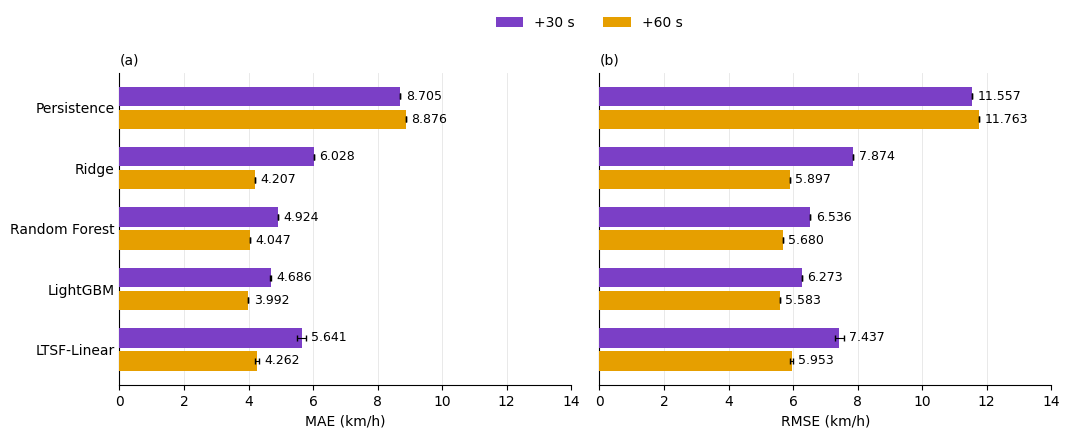

Đã cập nhật fig_rq2_models.png và .pdf.
Test: +30 s = 51,723 dòng; +60 s = 49,887 dòng.
+60 s: LightGBM có MAE trung bình thấp nhất (3.992 km/h), giảm 55.0% so với Persistence.
Đối chiếu dưới đây chỉ dùng seed 0 trên các thời điểm dự báo chung:


MAE_kmh        RMSE_kmh        
horizon_seconds      30     60       30      60
model                                          
Persistence       8.705  8.869   11.547  11.757
Ridge             6.000  4.173    7.832   5.840
Random Forest     4.895  4.012    6.491   5.626
LightGBM          4.660  3.957    6.234   5.532
LTSF-Linear       5.562  4.254    7.339   5.927

Số thời điểm dự báo chung: 49,336.
Bảng sai số theo ô dùng LightGBM, seed 0, +60 s; có kèm số dòng test và số recording.


In [12]:
# 6a.1 — RQ2 benchmark figure and supporting diagnostics
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from IPython.display import display

# Restore saved benchmark results and align predictions to current test keys.
from pathlib import Path

if "REPORT_DIR" not in globals() or "model_sets" not in globals():
    raise RuntimeError(
        "Cần chạy phần cấu hình và khôi phục/tạo tập train–test trước."
    )

report_path = Path(REPORT_DIR)
result_path = report_path / "table_rq2_runs_all_horizons.csv"
prediction_paths = {
    h: report_path / f"rq2_predictions_seed0_{h}s.parquet"
    for h in (30, 60)
}

needed_files = [result_path, *prediction_paths.values()]
missing_files = [str(path) for path in needed_files if not path.is_file()]
if missing_files:
    raise FileNotFoundError(
        "Chưa tìm thấy file kết quả tại REPORT_DIR:\n"
        + "\n".join(missing_files)
        + "\nKiểm tra đúng thư mục run trước; chưa cần huấn luyện lại."
    )

restored_runs = pd.read_csv(result_path)
restored_predictions = {}
restore_methods = [
    "Persistence", "Ridge", "Random Forest",
    "LightGBM", "LTSF-Linear",
]
restore_keys = ["flight", "cell", "t10"]

for h in (30, 60):
    target = model_sets[h]["target"]
    current = model_sets[h]["test"][
        restore_keys + [target]
    ].copy()
    saved = pd.read_parquet(prediction_paths[h])

    prediction_columns = [
        f"prediction_{method}" for method in restore_methods
    ]
    required_columns = restore_keys + [target] + prediction_columns
    absent = sorted(set(required_columns) - set(saved.columns))
    if absent:
        raise ValueError(f"+{h}s: file dự đoán thiếu cột {absent}.")

    for label, frame in [("test hiện tại", current), ("file đã lưu", saved)]:
        if frame[restore_keys].isna().any().any():
            raise ValueError(f"+{h}s: {label} có khóa thiếu.")
        if frame.duplicated(restore_keys).any():
            raise ValueError(f"+{h}s: {label} có khóa trùng.")

    current_index = pd.MultiIndex.from_frame(current[restore_keys])
    saved_index = pd.MultiIndex.from_frame(saved[restore_keys])

    # Require exactly the same test samples, not merely equal row counts.
    if (
        len(current_index) != len(saved_index)
        or not current_index.isin(saved_index).all()
    ):
        raise ValueError(
            f"+{h}s: mẫu test hiện tại khác mẫu trong file dự đoán. "
            "Dừng để tránh dùng kết quả của lần chia dữ liệu khác."
        )

    # Reorder by keys; do not assume saved row order is still valid.
    aligned = saved.set_index(restore_keys).reindex(current_index)
    current_y = current[target].to_numpy(dtype=float)
    saved_y = aligned[target].to_numpy(dtype=float)

    if (
        not np.isfinite(current_y).all()
        or not np.isfinite(saved_y).all()
        or not np.allclose(current_y, saved_y, rtol=1e-7, atol=1e-7)
    ):
        raise ValueError(f"+{h}s: nhãn đã lưu khác nhãn test hiện tại.")

    restored_predictions[h] = {}
    for method in restore_methods:
        prediction = aligned[f"prediction_{method}"].to_numpy(dtype=float)
        if not np.isfinite(prediction).all():
            raise ValueError(f"+{h}s, {method}: dự đoán chứa NaN/inf.")
        restored_predictions[h][method] = prediction.copy()

# Publish restored variables only after both horizons pass the checks.
rq2_runs_all = restored_runs
predictions_by_horizon = restored_predictions

print(
    "Đã nạp kết quả và căn chỉnh dự đoán theo flight/cell/t10. "
    "Tiếp tục kiểm tra MAE/RMSE rồi vẽ hình."
)

methods = [
    "Persistence", "Ridge", "Random Forest",
    "LightGBM", "LTSF-Linear",
]
horizons = [30, 60]
keys = ["flight", "cell", "t10"]
colors = {30: "#7B3FC6", 60: "#E69F00"}

# Recompute the plotted summaries from the individual runs.
runs = rq2_runs_all.copy()
required = {
    "horizon_seconds", "model", "seed", "MAE_kmh", "RMSE_kmh"
}
if not required.issubset(runs.columns):
    raise ValueError(f"Thiếu cột: {sorted(required - set(runs.columns))}")

expected = {
    (h, m, s)
    for h in horizons for m in methods for s in range(5)
}
actual = set(
    runs[["horizon_seconds", "model", "seed"]]
    .itertuples(index=False, name=None)
)
if actual != expected or len(runs) != len(expected):
    raise ValueError("Cần đúng 50 kết quả: 2 mốc × 5 mô hình × 5 seed.")

values = runs[["MAE_kmh", "RMSE_kmh"]].to_numpy(dtype=float)
if not np.isfinite(values).all() or (values < 0).any():
    raise ValueError("MAE/RMSE chứa giá trị không hợp lệ.")

summary = (
    runs.groupby(["horizon_seconds", "model"], as_index=False)
    .agg(
        MAE_mean=("MAE_kmh", "mean"),
        MAE_sd=("MAE_kmh", "std"),
        RMSE_mean=("RMSE_kmh", "mean"),
        RMSE_sd=("RMSE_kmh", "std"),
    )
)

# Check seed-0 predictions against the recorded seed-0 metrics.
# Keep forecast keys so the shared-origin comparison uses exact matches.
prediction_frames = {}
for h in horizons:
    source = model_sets[h]["test"]
    target = model_sets[h]["target"]
    frame = source[keys + [target]].copy()
    frame = frame.rename(columns={target: "observed"})

    if frame[keys].isna().any().any() or frame.duplicated(keys).any():
        raise ValueError(f"+{h}s: khóa test thiếu hoặc trùng.")

    y = frame["observed"].to_numpy(dtype=float)
    if not np.isfinite(y).all():
        raise ValueError(f"+{h}s: nhãn test không hợp lệ.")

    for method in methods:
        prediction = np.asarray(
            predictions_by_horizon[h][method], dtype=float
        )
        if prediction.shape != y.shape or not np.isfinite(prediction).all():
            raise ValueError(f"+{h}s, {method}: dự đoán không hợp lệ.")

        frame[method] = prediction
        error = y - prediction
        calculated = [
            np.mean(np.abs(error)),
            np.sqrt(np.mean(error ** 2)),
        ]
        recorded = runs.loc[
            (runs["horizon_seconds"] == h)
            & (runs["model"] == method)
            & (runs["seed"] == 0),
            ["MAE_kmh", "RMSE_kmh"],
        ].iloc[0].to_numpy(dtype=float)

        if not np.allclose(calculated, recorded, rtol=1e-6, atol=1e-6):
            raise ValueError(
                f"+{h}s, {method}: dự đoán không khớp metric đã ghi."
            )
    prediction_frames[h] = frame

# Diagnostic only: same flight/cell/forecast-origin keys at both horizons.
shared = prediction_frames[30].merge(
    prediction_frames[60],
    on=keys,
    how="inner",
    suffixes=("_30", "_60"),
    validate="one_to_one",
)
if shared.empty:
    raise ValueError("Không có thời điểm dự báo chung giữa hai mốc.")

diagnostic_rows = []
for h in horizons:
    y = shared[f"observed_{h}"].to_numpy(dtype=float)
    for method in methods:
        error = y - shared[f"{method}_{h}"].to_numpy(dtype=float)
        diagnostic_rows.append({
            "horizon_seconds": h,
            "model": method,
            "seed": 0,
            "shared_test_rows": len(shared),
            "MAE_kmh": np.mean(np.abs(error)),
            "RMSE_kmh": np.sqrt(np.mean(error ** 2)),
            "target_mean_kmh": np.mean(y),
            "target_sd_kmh": np.std(y, ddof=0),
        })
common_origin_metrics = pd.DataFrame(diagnostic_rows)

# A compact main figure: identical model order, colours and axis range.
plot_style = {
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
}
maximum = max(
    (summary[f"{metric}_mean"] + summary[f"{metric}_sd"]).max()
    for metric in ["MAE", "RMSE"]
)
xmax = max(2, int(np.ceil(maximum * 1.18 / 2) * 2))
ypos = np.arange(len(methods))

with plt.rc_context(plot_style):
    fig, axes = plt.subplots(
        1, 2, figsize=(10.8, 4.4), sharey=True
    )

    for ax, metric, panel in zip(axes, ["MAE", "RMSE"], ["(a)", "(b)"]):
        for h, offset in [(30, -0.19), (60, 0.19)]:
            rows = (
                summary.loc[summary["horizon_seconds"] == h]
                .set_index("model").loc[methods]
            )
            means = rows[f"{metric}_mean"].to_numpy()
            sds = rows[f"{metric}_sd"].to_numpy()

            ax.barh(
                ypos + offset, means, height=0.32,
                color=colors[h], xerr=sds,
                error_kw={
                    "ecolor": "black", "elinewidth": 0.8, "capsize": 2
                },
                zorder=3,
            )
            for y, mean, sd in zip(ypos + offset, means, sds):
                ax.text(
                    mean + sd + xmax * 0.012, y, f"{mean:.3f}",
                    va="center", fontsize=9,
                    color="black", fontweight="normal",
                )

        ax.set_xlim(0, xmax)
        ax.set_xticks(np.arange(0, xmax + 0.1, 2))
        ax.set_yticks(ypos)
        ax.set_yticklabels(methods)
        ax.set_xlabel(f"{metric} (km/h)")
        ax.set_title(panel, loc="left", fontsize=10)
        ax.grid(axis="x", color="#E5E5E5", linewidth=0.6, zorder=0)
        ax.tick_params(axis="y", length=0)

    axes[0].invert_yaxis()
    fig.legend(
        handles=[
            Patch(facecolor=colors[30], label="+30 s"),
            Patch(facecolor=colors[60], label="+60 s"),
        ],
        loc="upper center", ncol=2, frameon=False,
        bbox_to_anchor=(0.55, 1.0),
    )
    fig.tight_layout(rect=(0, 0, 1, 0.92))

    REPORT_DIR.mkdir(parents=True, exist_ok=True)
    for extension in ["png", "pdf"]:
        fig.savefig(
            REPORT_DIR / f"fig_rq2_models.{extension}",
            dpi=300, bbox_inches="tight", facecolor="white",
        )
    plt.show()
    plt.close(fig)

# Supporting diagnostics remain outside the main figure.
common_origin_metrics.to_csv(
    REPORT_DIR / "table_rq2_common_origins_seed0.csv", index=False
)

primary = (
    summary.loc[summary["horizon_seconds"] == 60]
    .set_index("model").loc[methods]
)
selected = primary["MAE_mean"].idxmin()
detail = prediction_frames[60].copy()
detail["absolute_error"] = (detail["observed"] - detail[selected]).abs()
error_by_unit = (
    detail.groupby("cell")
    .agg(
        MAE_kmh=("absolute_error", "mean"),
        test_records=("absolute_error", "size"),
        recordings=("flight", "nunique"),
    )
    .sort_values("MAE_kmh", ascending=False)
)
error_by_unit.to_csv(REPORT_DIR / "table_rq2_error_by_unit.csv")

baseline = primary.loc["Persistence", "MAE_mean"]
selected_mae = primary.loc[selected, "MAE_mean"]
gain = 100 * (baseline - selected_mae) / baseline if baseline > 0 else np.nan

print("Đã cập nhật fig_rq2_models.png và .pdf.")
print(
    f"Test: +30 s = {len(prediction_frames[30]):,} dòng; "
    f"+60 s = {len(prediction_frames[60]):,} dòng."
)
print(
    f"+60 s: {selected} có MAE trung bình thấp nhất "
    f"({selected_mae:.3f} km/h), giảm {gain:.1f}% so với Persistence."
)
print("Đối chiếu dưới đây chỉ dùng seed 0 trên các thời điểm dự báo chung:")
display(
    common_origin_metrics.pivot(
        index="model", columns="horizon_seconds",
        values=["MAE_kmh", "RMSE_kmh"],
    ).reindex(methods).round(3)
)
print(f"Số thời điểm dự báo chung: {len(shared):,}.")
print(
    f"Bảng sai số theo ô dùng {selected}, seed 0, +60 s; "
    "có kèm số dòng test và số recording."
)

Tại mốc +60 giây, LightGBM đạt MAE trung bình thấp nhất trong năm phương pháp, giảm khoảng 55% so với Persistence. Random Forest đạt kết quả gần tương đương, với MAE cao hơn khoảng 0,055 km/h. Kết quả cho thấy cả hai phương pháp đều cải thiện đáng kể về mức sai số quan sát được so với dự báo giữ nguyên tốc độ hiện tại (persistence) trên tập kiểm tra này.

### LightGBM tuning (Tinh chỉnh LightGBM)

LightGBM hyperparameters are evaluated for the primary +60-second
forecast horizon using grouped cross-validation within the training
recordings. The original configuration and 30 sampled configurations
use the same validation folds, predictors and model seed.

(Các siêu tham số LightGBM được đánh giá cho mốc dự báo chính +60 giây
bằng kiểm định chéo theo recording trong tập huấn luyện. Cấu hình
gốc và 30 cấu hình được lấy mẫu sử dụng cùng các fold validation,
biến đầu vào và seed mô hình.)

The configuration with lower mean validation MAE is selected;
ties retain the original configuration. Test results are reported
after selection and do not determine the selected configuration.

(Cấu hình có MAE validation trung bình thấp hơn được chọn; nếu bằng
nhau, giữ cấu hình gốc. Kết quả test được tính sau khi chọn và không
quyết định cấu hình được sử dụng.)

This analysis compares two configurations at one fixed seed.
It is separate from the five-seed benchmark. Validation scores used
for tuning are selection scores, not independent estimates of
generalisation performance.

(Phân tích này so sánh hai cấu hình tại một seed cố định, tách biệt
với benchmark năm seed. Điểm validation dùng để tuning là điểm phục
vụ lựa chọn, không phải ước lượng độc lập về khả năng khái quát.)

In [13]:
# 6a.2 — LightGBM tuning at +60 s, using training recordings only
import hashlib
import json
import time
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display
from lightgbm import LGBMRegressor
from scipy.stats import loguniform, randint, uniform
from sklearn.metrics import mean_absolute_error, mean_squared_error
from sklearn.model_selection import (
    GroupKFold, RandomizedSearchCV, cross_val_score,
)

TUNING_VERIFIED = False
HORIZON = 60
MODEL_SEED = 0
SEARCH_SEED = 42

report_path = Path(REPORT_DIR)
config_path = report_path / "benchmark_config_02.json"
split_path = report_path / "split_manifest.json"

if not config_path.is_file() or not split_path.is_file():
    raise FileNotFoundError(
        "Thiếu benchmark_config_02.json hoặc split_manifest.json."
    )

with config_path.open(encoding="utf-8") as file:
    benchmark_config = json.load(file)

split_hash = hashlib.sha256(split_path.read_bytes()).hexdigest()
if split_hash != benchmark_config["split_manifest_sha256"]:
    raise ValueError(
        "Manifest chia dữ liệu đã đổi so với benchmark. "
        "Không tiếp tục tuning trên hai phiên bản dữ liệu khác nhau."
    )

# Explicitly use the primary horizon; avoid stale X_tr/y_tr aliases.
bundle = model_sets[HORIZON]
target_column = bundle["target"]
predictors = list(benchmark_config["X_cols"])

if target_column != benchmark_config["horizons"][str(HORIZON)]:
    raise ValueError("Nhãn +60 giây không khớp cấu hình benchmark.")

train = bundle["train"]
test = bundle["test"]
TARGET_COL = target_column

X_tr = train[predictors].copy()
y_tr = train[target_column].copy()
X_te = test[predictors].copy()
y_te = test[target_column].copy()
groups = train["flight"].to_numpy()

for label, frame in [("train", train), ("test", test)]:
    if frame.empty:
        raise ValueError(f"Tập {label} rỗng.")
    if frame[["flight", "cell", "t10"]].isna().any().any():
        raise ValueError(f"Tập {label} có khóa thiếu.")
    if frame.duplicated(["flight", "cell", "t10"]).any():
        raise ValueError(f"Tập {label} có khóa trùng.")
    if not np.isfinite(
        frame[predictors + [target_column]].to_numpy(dtype=float)
    ).all():
        raise ValueError(f"Tập {label} chứa đầu vào hoặc nhãn NaN/inf.")

if set(train["flight"]) & set(test["flight"]):
    raise ValueError("Recording train và test bị giao nhau.")

number_splits = min(5, train["flight"].nunique())
if number_splits < 2:
    raise ValueError("Cần ít nhất hai recording huấn luyện.")

# Materialise once: every configuration uses exactly the same folds.
folds = list(
    GroupKFold(n_splits=number_splits).split(X_tr, y_tr, groups)
)
for fit_index, validation_index in folds:
    if set(groups[fit_index]) & set(groups[validation_index]):
        raise ValueError("Recording bị giao nhau trong validation fold.")

# Rebuild the original model from the saved benchmark configuration.
original_parameters = dict(benchmark_config["lightgbm"])
original_parameters["random_state"] = MODEL_SEED
original_model = LGBMRegressor(**original_parameters)

print(
    f"Tuning +{HORIZON}s | {number_splits} folds theo recording | "
    f"model seed={MODEL_SEED}"
)

start = time.perf_counter()
original_fold_mae = -cross_val_score(
    original_model,
    X_tr,
    y_tr,
    cv=folds,
    scoring="neg_mean_absolute_error",
    n_jobs=1,
    error_score="raise",
)
original_validation_seconds = time.perf_counter() - start
original_cv_mae = float(original_fold_mae.mean())

parameter_space = {
    "learning_rate": loguniform(0.01, 0.1),
    "num_leaves": randint(15, 64),
    "n_estimators": randint(300, 1500),
    "subsample": uniform(0.6, 0.4),
    "colsample_bytree": uniform(0.6, 0.4),
    "min_child_samples": randint(10, 100),
}

search = RandomizedSearchCV(
    estimator=LGBMRegressor(**original_parameters),
    param_distributions=parameter_space,
    n_iter=30,
    scoring="neg_mean_absolute_error",
    cv=folds,
    random_state=SEARCH_SEED,
    n_jobs=1,
    refit=True,
    error_score="raise",
    return_train_score=False,
    verbose=1,
)

start = time.perf_counter()
search.fit(X_tr, y_tr)
tuning_seconds = time.perf_counter() - start
tuned_model = search.best_estimator_
tuned_cv_mae = float(-search.best_score_)

# Make the selection before computing any test metrics.
choose_tuned = tuned_cv_mae < original_cv_mae
selected_lightgbm_version = "tuned" if choose_tuned else "original"

# Fit the original configuration on all training rows as well.
original_model.fit(X_tr, y_tr)
final_lightgbm = tuned_model if choose_tuned else original_model

original_prediction = original_model.predict(X_te)
tuned_prediction = tuned_model.predict(X_te)

for label, prediction in [
    ("original", original_prediction), ("tuned", tuned_prediction)
]:
    if prediction.shape != y_te.shape or not np.isfinite(prediction).all():
        raise ValueError(f"Dự đoán {label} không hợp lệ.")

final_lightgbm_prediction = (
    tuned_prediction if choose_tuned else original_prediction
)

rows = []
for version, prediction, validation_mae in [
    ("original", original_prediction, original_cv_mae),
    ("tuned", tuned_prediction, tuned_cv_mae),
]:
    rows.append({
        "horizon_seconds": HORIZON,
        "model_seed": MODEL_SEED,
        "configuration": version,
        "selected_by_validation": version == selected_lightgbm_version,
        "validation_MAE_kmh": validation_mae,
        "MAE_kmh": mean_absolute_error(y_te, prediction),
        "RMSE_kmh": np.sqrt(mean_squared_error(y_te, prediction)),
        "test_rows": len(y_te),
    })

tuning_results = pd.DataFrame(rows)
original_mae = tuning_results.loc[0, "MAE_kmh"]
tuning_results["MAE_change_vs_original_kmh"] = (
    tuning_results["MAE_kmh"] - original_mae
)

# Save the full search trail, not only the winning parameters.
cv_results = pd.DataFrame(search.cv_results_)
cv_results.to_csv(
    report_path / "table_tuning_search.csv",
    index=False, encoding="utf-8-sig",
)
tuning_results.to_csv(
    report_path / "table_tuning.csv",
    index=False, encoding="utf-8-sig",
)

def json_value(value):
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"Không thể lưu JSON: {type(value).__name__}")

tuning_metadata = {
    "run_id": benchmark_config["run_id"],
    "split_manifest_sha256": split_hash,
    "horizon_seconds": HORIZON,
    "model_seed": MODEL_SEED,
    "search_seed": SEARCH_SEED,
    "predictors": predictors,
    "validation_method": f"{number_splits}-fold GroupKFold by flight",
    "validation_aggregation": "unweighted mean of fold MAEs",
    "original_parameters": original_parameters,
    "best_parameters": search.best_params_,
    "original_validation_MAE_kmh": original_cv_mae,
    "tuned_validation_MAE_kmh": tuned_cv_mae,
    "selected_configuration": selected_lightgbm_version,
    "selection_rule": "lower validation MAE; original on ties",
    "test_used_for_configuration_selection": False,
    "original_validation_seconds": original_validation_seconds,
    "search_and_refit_seconds": tuning_seconds,
}
with (report_path / "params_tuned.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(
        tuning_metadata, file, indent=2,
        ensure_ascii=False, default=json_value,
    )

TUNING_VERIFIED = True
display(tuning_results.round(4))
print("Cấu hình được chọn bằng validation:", selected_lightgbm_version)
print("Đã cập nhật bảng tuning, toàn bộ kết quả tìm kiếm và tham số.")
print("Kết quả này dùng seed 0; không thay thế benchmark năm seed.")

Tuning +60s | 5 folds theo recording | model seed=0
Fitting 5 folds for each of 30 candidates, totalling 150 fits


,horizon_seconds,model_seed,configuration,selected_by_validation,validation_MAE_kmh,MAE_kmh,RMSE_kmh,test_rows,MAE_change_vs_original_kmh
0,60,0,original,False,3.9380,3.9920,5.5855,49887,0.0000
1,60,0,tuned,True,3.9156,3.9691,5.5564,49887,-0.0229


Cấu hình được chọn bằng validation: tuned
Đã cập nhật bảng tuning, toàn bộ kết quả tìm kiếm và tham số.
Kết quả này dùng seed 0; không thay thế benchmark năm seed.


### Save and verify the selected model
### Lưu và kiểm chứng mô hình đã chọn

The selected +60-second LightGBM model is saved together with its
test predictions and handover metadata. The metadata records the
predictor order, target, model seed, validation-based selection,
software versions and file hashes.

(Mô hình LightGBM đã chọn cho mốc +60 giây được lưu cùng dự đoán
test và thông tin bàn giao. Thông tin này ghi thứ tự biến đầu vào,
nhãn, seed mô hình, cách chọn bằng validation, phiên bản thư viện
và mã băm các file.)

The saved model is reloaded and its predictions are checked against
the current results. This verifies the saved checkpoint; it does
not retrain the model or establish performance on new data.

(Mô hình được nạp lại và đối chiếu dự đoán với kết quả hiện tại.
Bước này kiểm chứng bản lưu, không huấn luyện lại và không chứng
minh hiệu quả trên dữ liệu mới.)

In [14]:
import joblib
model_path = MODEL_DIR / "selected_lightgbm.joblib"# Save and verify the selected +60-second LightGBM model.
import hashlib
import json
import os
import tempfile
from importlib.metadata import version
from pathlib import Path

import joblib
import numpy as np
import pandas as pd

if not globals().get("TUNING_VERIFIED", False):
    raise RuntimeError("Chạy thành công ô tuning trước khi lưu mô hình.")

model_dir = Path(MODEL_DIR)
processed_dir = Path(PROCESSED_DIR)
model_dir.mkdir(parents=True, exist_ok=True)
processed_dir.mkdir(parents=True, exist_ok=True)

model_path = model_dir / "selected_lightgbm.joblib"
prediction_path = processed_dir / "selected_predictions.parquet"
handover_path = model_dir / "handover.json"

def file_sha256(path):
    hasher = hashlib.sha256()
    with Path(path).open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(chunk)
    return hasher.hexdigest()

def json_safe(value):
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"Không thể lưu JSON: {type(value).__name__}")

# Use the explicit +60-second dataset and fitted feature order.
bundle = model_sets[60]
target = bundle["target"]
testing = bundle["test"]
feature_order = list(final_lightgbm.feature_name_)
expected = np.asarray(final_lightgbm_prediction, dtype=float)

if testing.duplicated(["flight", "cell", "t10"]).any():
    raise ValueError("Khóa test bị trùng.")

if expected.shape != (len(testing),) or not np.isfinite(expected).all():
    raise ValueError("Dự đoán hiện tại không hợp lệ.")

current_prediction = final_lightgbm.predict(testing[feature_order])
np.testing.assert_allclose(
    current_prediction, expected, rtol=1e-10, atol=1e-10,
    err_msg="Mô hình và dự đoán hiện tại không khớp với tập test.",
)

selection = (
    "tuned" if tuned_cv_mae < original_cv_mae else "original"
)
if selection != selected_lightgbm_version:
    raise ValueError("Cấu hình được chọn không khớp quy tắc validation.")

prediction_table = testing[
    ["flight", "cell", "t10", target]
].copy().reset_index(drop=True)
prediction_table["prediction"] = expected

# Stage files beside their destinations; verify before replacing old files.
with (
    tempfile.TemporaryDirectory(dir=model_dir) as model_tmp,
    tempfile.TemporaryDirectory(dir=processed_dir) as data_tmp,
):
    staged_model = Path(model_tmp) / model_path.name
    staged_predictions = Path(data_tmp) / prediction_path.name
    staged_handover = Path(model_tmp) / handover_path.name

    joblib.dump(final_lightgbm, staged_model, compress=3)
    reloaded_model = joblib.load(staged_model)

    np.testing.assert_allclose(
        reloaded_model.predict(testing[feature_order]),
        expected,
        rtol=1e-10,
        atol=1e-10,
        err_msg="Dự đoán thay đổi sau khi lưu và nạp lại mô hình.",
    )

    prediction_table.to_parquet(staged_predictions, index=False)
    pd.testing.assert_frame_equal(
        pd.read_parquet(staged_predictions),
        prediction_table,
    )

    metadata = {
        "run_id": RUN_ID,
        "horizon_seconds": 60,
        "target": target,
        "predictors_in_order": feature_order,
        "model_seed": 0,
        "selected_version": selected_lightgbm_version,
        "selection_rule": (
            "lower mean training-flight GroupKFold MAE; "
            "retain original on ties"
        ),
        "original_validation_mae": float(original_cv_mae),
        "tuned_validation_mae": float(tuned_cv_mae),
        "train_rows": len(bundle["train"]),
        "test_rows": len(testing),
        "feature_sha256": file_sha256(FEATURE_FILE),
        "split_manifest_sha256": file_sha256(
            Path(REPORT_DIR) / "split_manifest.json"
        ),
        "model_file": str(model_path),
        "model_sha256": file_sha256(staged_model),
        "prediction_file": str(prediction_path),
        "prediction_sha256": file_sha256(staged_predictions),
        "parameters": final_lightgbm.get_params(),
        "training_packages": {
            name: version(name)
            for name in [
                "lightgbm", "scikit-learn", "numpy",
                "pandas", "joblib", "pyarrow",
            ]
        },
        "model_reload_predictions_verified": True,
        "prediction_readback_verified": True,
    }

    staged_handover.write_text(
        json.dumps(
            metadata, indent=2, ensure_ascii=False, default=json_safe
        ),
        encoding="utf-8",
    )

    os.replace(staged_model, model_path)
    os.replace(staged_predictions, prediction_path)
    # Publish metadata last, after both verified files are in place.
    os.replace(staged_handover, handover_path)

print("MODEL CHECKPOINT SAVED AND VERIFIED")
print("Mốc dự báo: +60 giây | Seed: 0")
print("Cấu hình:", selected_lightgbm_version)
print(f"Số dự đoán test đã lưu: {len(prediction_table):,}")
print("Mô hình:", model_path)
print("Dự đoán:", prediction_path)
print("Thông tin bàn giao:", handover_path)
print("Đã nạp lại mô hình và xác nhận dự đoán không thay đổi.")

MODEL CHECKPOINT SAVED AND VERIFIED
Mốc dự báo: +60 giây | Seed: 0
Cấu hình: tuned
Số dự đoán test đã lưu: 49,887
Mô hình: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/models/selected_lightgbm.joblib
Dự đoán: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/data/processed/selected_predictions.parquet
Thông tin bàn giao: /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/models/handover.json
Đã nạp lại mô hình và xác nhận dự đoán không thay đổi.


### Verify the RQ2 experiment
### Kiểm chứng thí nghiệm RQ2

Checks cover unique sample keys, separation of training and test
recordings, finite model inputs, and complete benchmark runs.
Forecast targets and historical features are independently checked
by exact-time lookup within the same recording and grid cell.

(Kiểm tra khóa mẫu duy nhất, recording train/test không giao nhau,
đầu vào hợp lệ và đủ các lượt benchmark. Nhãn dự báo và đặc trưng
lịch sử được đối chiếu độc lập bằng tra cứu đúng thời điểm trong
cùng recording và ô lưới.)

The selected +60-second model is checked against its saved test
predictions. Counts and errors are calculated from the current
datasets; passing does not require beating a baseline.

(Mô hình đã chọn cho mốc +60 giây được đối chiếu với dự đoán test
đã lưu. Số mẫu và sai số được tính từ dữ liệu hiện tại; không yêu
cầu mô hình phải thắng baseline để vượt qua kiểm tra.)

These checks verify the tested data relationships and saved results.
They do not establish statistical significance or generalisation
to new recording dates.

(Các kiểm tra xác nhận những quan hệ dữ liệu và kết quả lưu được
kiểm tra. Chúng không chứng minh ý nghĩa thống kê hoặc khả năng
khái quát sang ngày ghi hình mới.)

In [15]:
# RQ2 integrity: exact-time targets/history, splits and saved predictions.
import hashlib
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display

RQ2_INTEGRITY_VERIFIED = False
keys = ["flight", "cell", "t10"]
expected_models = {
    "Persistence", "Ridge", "Random Forest",
    "LightGBM", "LTSF-Linear",
}
expected_inputs = [
    "speed", "s_lag1", "s_lag3", "s_ma1m",
    "n_veh", "n_lag1", "n_ma1m",
    "share_2w", "share_heavy", "cell_lat", "cell_lon",
]

def require(condition, message):
    if not condition:
        raise ValueError(message)

def sha256_file(path):
    result = hashlib.sha256()
    with Path(path).open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            result.update(chunk)
    return result.hexdigest()

# Verify the checkpoint's source and paired files before using them.
metadata = json.loads(
    (Path(MODEL_DIR) / "handover.json").read_text(encoding="utf-8")
)
require(metadata["run_id"] == RUN_ID, "Checkpoint thuộc run khác.")
require(metadata["horizon_seconds"] == 60, "Checkpoint không phải +60 s.")
require(
    metadata["predictors_in_order"] == expected_inputs,
    "Thứ tự đầu vào checkpoint khác thiết kế.",
)

for path, expected_hash in [
    (FEATURE_FILE, metadata["feature_sha256"]),
    (
        Path(REPORT_DIR) / "split_manifest.json",
        metadata["split_manifest_sha256"],
    ),
    (
        Path(MODEL_DIR) / "selected_lightgbm.joblib",
        metadata["model_sha256"],
    ),
    (
        Path(PROCESSED_DIR) / "selected_predictions.parquet",
        metadata["prediction_sha256"],
    ),
]:
    require(
        sha256_file(path) == expected_hash,
        f"File đã thay đổi so với checkpoint: {path}",
    )

# Read current quantities directly from the exported feature source.
source = pd.read_parquet(
    FEATURE_FILE, columns=keys + ["speed", "n_veh"]
)
require(
    not source[keys].isna().any().any()
    and not source.duplicated(keys).any(),
    "Khóa dữ liệu nguồn bị thiếu hoặc trùng.",
)
source_index = source.set_index(keys)

def lookup(frame, column, offset):
    query = pd.MultiIndex.from_arrays(
        [
            frame["flight"].to_numpy(),
            frame["cell"].to_numpy(),
            frame["t10"].to_numpy() + offset,
        ],
        names=keys,
    )
    return source_index[column].reindex(query).to_numpy(dtype=float)

def check_values(actual, expected, label):
    actual = np.asarray(actual, dtype=float)
    expected = np.asarray(expected, dtype=float)
    require(actual.shape == expected.shape, f"{label}: sai kích thước.")
    valid = (
        np.isfinite(actual)
        & np.isfinite(expected)
        & np.isclose(actual, expected, rtol=1e-7, atol=1e-7)
    )
    require(
        valid.all(),
        f"{label}: {np.count_nonzero(~valid):,} giá trị thiếu hoặc lệch.",
    )

# Check the complete benchmark, not a potentially stale summary variable.
runs = pd.read_csv(
    Path(REPORT_DIR) / "table_rq2_runs_all_horizons.csv"
)
expected_runs = {
    (h, method, seed)
    for h in (30, 60)
    for method in expected_models
    for seed in range(5)
}
actual_runs = set(
    runs[["horizon_seconds", "model", "seed"]]
    .itertuples(index=False, name=None)
)
require(
    len(runs) == 50 and actual_runs == expected_runs,
    "Benchmark thiếu hoặc trùng horizon/model/seed.",
)
metric_values = runs[["MAE_kmh", "RMSE_kmh"]].to_numpy(dtype=float)
require(
    np.isfinite(metric_values).all() and (metric_values >= 0).all(),
    "Metric benchmark không hợp lệ.",
)

records = []
flight_roles = {}

for h in (30, 60):
    bundle = model_sets[h]
    target = bundle["target"]
    require(target == f"y_{h}s", f"+{h}s: sai tên nhãn.")

    training = bundle["train"]
    testing = bundle["test"]
    require(
        set(training["flight"]).isdisjoint(set(testing["flight"])),
        f"+{h}s: recording train/test giao nhau.",
    )

    combined = pd.concat([training, testing], ignore_index=True)
    require(
        not combined[keys].isna().any().any()
        and not combined.duplicated(keys).any(),
        f"+{h}s: khóa mẫu thiếu hoặc trùng.",
    )

    for split_name, frame in [("train", training), ("test", testing)]:
        require(not frame.empty, f"+{h}s: {split_name} rỗng.")
        require(
            np.isfinite(
                frame[expected_inputs + [target]].to_numpy(dtype=float)
            ).all(),
            f"+{h}s: {split_name} có đầu vào/nhãn NaN hoặc inf.",
        )

        # A recording must keep its role across both horizons.
        for flight in frame["flight"].unique():
            require(
                flight_roles.get(flight, split_name) == split_name,
                "Recording đổi vai trò train/test giữa hai mốc.",
            )
            flight_roles[flight] = split_name

        check_values(
            frame[target], lookup(frame, "speed", h),
            f"+{h}s {split_name}: nhãn tại t+{h}",
        )

        past_speed = {}
        past_count = {}
        for offset in (0, 10, 20, 30, 40, 50):
            past_speed[offset] = lookup(frame, "speed", -offset)
            past_count[offset] = lookup(frame, "n_veh", -offset)
            speed_column = "speed" if offset == 0 else f"speed_lag{offset}"
            check_values(
                frame[speed_column], past_speed[offset],
                f"+{h}s {split_name}: {speed_column}",
            )

        expected_history = {
            "s_lag1": past_speed[10],
            "s_lag3": past_speed[30],
            "s_ma1m": np.mean(list(past_speed.values()), axis=0),
            "n_veh": past_count[0],
            "n_lag1": past_count[10],
            "n_ma1m": np.mean(list(past_count.values()), axis=0),
        }
        for column, values in expected_history.items():
            check_values(
                frame[column], values, f"+{h}s {split_name}: {column}"
            )

    horizon_runs = runs.loc[runs["horizon_seconds"] == h]
    require(
        horizon_runs["train_rows"].eq(len(training)).all()
        and horizon_runs["test_rows"].eq(len(testing)).all(),
        f"+{h}s: số mẫu hiện tại khác benchmark.",
    )

    records.append({
        "horizon_seconds": h,
        "eligible_rows": len(combined),
        "train_rows": len(training),
        "test_rows": len(testing),
        "train_flights": training["flight"].nunique(),
        "test_flights": testing["flight"].nunique(),
        "persistence_MAE_kmh": np.mean(
            np.abs(testing[target] - testing["speed"])
        ),
        "target_and_history_checks": "passed",
    })
    print(f"+{h}s: đã kiểm tra nhãn và lịch sử trên cả train/test.")

# Match saved predictions to the explicit +60-second test keys.
testing = model_sets[60]["test"]
target = model_sets[60]["target"]
saved = pd.read_parquet(
    Path(PROCESSED_DIR) / "selected_predictions.parquet"
)
require(
    not saved[keys].isna().any().any()
    and not saved.duplicated(keys).any(),
    "Khóa dự đoán đã lưu thiếu hoặc trùng.",
)
test_index = pd.MultiIndex.from_frame(testing[keys])
saved_index = pd.MultiIndex.from_frame(saved[keys])
require(
    len(saved) == len(testing) and test_index.isin(saved_index).all(),
    "Dự đoán đã lưu không thuộc đúng tập test +60 s.",
)
aligned = saved.set_index(keys).reindex(test_index)
check_values(aligned[target], testing[target], "Nhãn checkpoint")

require(
    list(final_lightgbm.feature_name_) == expected_inputs,
    "Đầu vào mô hình trong RAM khác checkpoint.",
)
prediction = final_lightgbm.predict(testing[expected_inputs])
check_values(prediction, aligned["prediction"], "Dự đoán checkpoint")
check_values(
    final_lightgbm_prediction, aligned["prediction"],
    "Dự đoán trong RAM",
)

run_check = pd.DataFrame(records)
run_check["selected_LightGBM_MAE_kmh"] = np.nan
run_check.loc[
    run_check["horizon_seconds"] == 60, "selected_LightGBM_MAE_kmh"
] = np.mean(np.abs(testing[target].to_numpy() - prediction))

run_check.to_csv(
    Path(REPORT_DIR) / "table_run_integrity.csv",
    index=False, encoding="utf-8-sig",
)
RQ2_INTEGRITY_VERIFIED = True
display(run_check.round(4))
print("RQ2 INTEGRITY CHECKS PASSED")
print("Không dùng điều kiện mô hình phải thắng Persistence.")

+30s: đã kiểm tra nhãn và lịch sử trên cả train/test.
+60s: đã kiểm tra nhãn và lịch sử trên cả train/test.


,horizon_seconds,eligible_rows,train_rows,test_rows,train_flights,test_flights,persistence_MAE_kmh,target_and_history_checks,selected_LightGBM_MAE_kmh
0,30,254157,202434,51723,159,40,8.7046,passed,NaN
1,60,245117,195230,49887,159,40,8.8760,passed,3.9691


RQ2 INTEGRITY CHECKS PASSED
Không dùng điều kiện mô hình phải thắng Persistence.


## RQ2 findings and handover (Kết quả RQ2 và bàn giao)

At the primary +60-second horizon, LightGBM achieved the lowest
mean test MAE among the five evaluated methods: approximately
3.992 km/h across five seeds, compared with 8.876 km/h for
Persistence, a reduction of approximately 55.0%. Random Forest
was close, with a mean MAE of approximately 4.047 km/h.
These results apply to 49,887 eligible test rows from 40 held-out
recordings under the evaluated configurations.

(Tại mốc chính +60 giây, LightGBM đạt MAE test trung bình thấp nhất
trong năm phương pháp: khoảng 3,992 km/h qua năm seed, so với
8,876 km/h của Persistence, tương đương giảm khoảng 55,0%.
Random Forest đạt kết quả gần tương đương, với MAE trung bình
khoảng 4,047 km/h. Kết quả áp dụng cho 49.887 dòng test đủ điều
kiện từ 40 recording giữ riêng, với các cấu hình đã đánh giá.)

A separate tuning experiment selected LightGBM parameters using
five-fold validation within the training recordings. At seed 0,
test MAE decreased from 3.9920 to 3.9691 km/h, approximately 0.57%.
Tuning therefore produced a small observed improvement. This
single-seed result does not replace the five-seed benchmark.

(Thí nghiệm tuning riêng chọn tham số LightGBM bằng validation
năm fold trong các recording huấn luyện. Tại seed 0, MAE test
giảm từ 3,9920 xuống 3,9691 km/h, khoảng 0,57%. Tuning đem lại
mức cải thiện quan sát được nhỏ. Kết quả một seed này không
thay thế benchmark năm seed.)

The checked targets and historical features matched exact-time
lookups within each recording and cell. Training and test recordings
were disjoint, and the saved model reproduced its saved predictions.
These checks support consistency of the experiment; they do not
establish statistical superiority or performance on new dates.

(Nhãn và đặc trưng lịch sử được kiểm tra khớp với tra cứu đúng thời
điểm trong từng recording và ô. Recording train/test không giao
nhau, và mô hình đã lưu tái tạo được dự đoán đã lưu. Các kiểm tra
hỗ trợ tính nhất quán của thí nghiệm; không chứng minh ưu thế
thống kê hoặc hiệu quả trên ngày ghi hình mới.)

The learned models also showed lower errors at +60 than +30 seconds
in the seed-0 comparison on 49,336 shared forecast origins.
Differences in eligible sample membership therefore do not fully
explain this pattern. Its cause remains unresolved.

(Các mô hình học từ dữ liệu cũng có sai số +60 giây thấp hơn
+30 giây khi so sánh seed 0 trên 49.336 thời điểm dự báo chung.
Vì vậy, sự khác nhau về thành phần mẫu đủ điều kiện không giải
thích hết hiện tượng này. Nguyên nhân vẫn chưa được xác định.)

Evidence: `table_rq2_all_horizons.csv`, `fig_rq2_models.png`,
`table_tuning.csv`, `table_rq2_common_origins_seed0.csv`,
and `table_run_integrity.csv`.

(Bằng chứng: các bảng kết quả và hình nêu trên.)

<a id="rq3"></a>

# Part III · RQ3 experiments (Phần III · Các thí nghiệm RQ3)

RQ2 evaluates speed-prediction errors. RQ3 examines three additional
questions: whether an upcoming low-speed transition can be warned
about, whether vehicle-composition features improve prediction,
and whether prediction remains useful in cells excluded from training.

(RQ2 đánh giá sai số dự báo tốc độ. RQ3 xem xét ba câu hỏi bổ sung:
có thể cảnh báo việc sắp chuyển sang tốc độ thấp không, đặc trưng
thành phần xe có cải thiện dự báo không, và mô hình còn hữu ích
ở những ô không được dùng để huấn luyện không.)

| Experiment / Thí nghiệm | Comparison / Nội dung đánh giá |
|---|---|
| RQ3a · Low-speed onset warning / Cảnh báo bắt đầu tốc độ thấp | Ability to identify upcoming low-speed windows and the trade-off between detected cases and false alarms. / Khả năng nhận diện cửa sổ sắp có tốc độ thấp và đánh đổi giữa phát hiện và báo nhầm. |
| RQ3b · Composition ablation / Thử bỏ đặc trưng thành phần xe | Speed prediction with and without `share_2w` and `share_heavy`, using matched samples and settings. / Dự báo tốc độ có và không có hai biến thành phần, trên cùng mẫu và thiết lập. |
| RQ3c · Spatial transfer / Chuyển giao không gian | Prediction in selected cells excluded from training, compared with Persistence on the same test subset. / Dự báo tại các ô được loại khỏi train, so với Persistence trên cùng tập test con. |

Each experiment has its own eligibility rules and comparison.
Its sample counts and results must be reported separately.
SHAP analysis follows to describe the speed model's use of
features; it does not identify causal traffic effects.

(Mỗi thí nghiệm có điều kiện mẫu và phép so sánh riêng; cần báo
riêng số mẫu và kết quả. Phân tích SHAP phía sau mô tả cách mô hình
tốc độ sử dụng các đặc trưng, không xác định tác động nhân quả
đối với giao thông.)

The saved +60-second regressor is available for subsequent analysis.
The warning experiment requires a separate classifier; the
regression checkpoint is not itself a warning model.

(Mô hình hồi quy +60 giây đã lưu có thể dùng cho các phân tích
tiếp theo. Thí nghiệm cảnh báo cần một mô hình phân loại riêng;
checkpoint hồi quy không tự trở thành mô hình cảnh báo.)

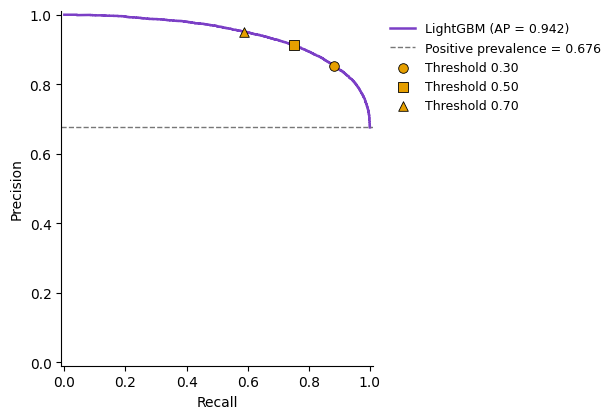

RQ3a: nhãn đã được kiểm tra theo đủ sáu mốc tương lai.
Train: 113,579 mẫu | Test: 30,662 mẫu | Seed: 42
Mẫu test dương: 20,719 (67.6%) | AP: 0.9419


,threshold,precision,recall,false_positive_rate,alarm_rate,TP,FP,FN,TN
0,0.3,0.8538,0.8831,0.3151,0.6989,18296,3133,2423,6810
1,0.5,0.9116,0.7516,0.1519,0.5571,15573,1510,5146,8433
2,0.7,0.9517,0.5890,0.0623,0.4182,12204,619,8515,9324


ECE, 10 khoảng đều: 0.1221
Đã cập nhật CSV, dự đoán, cấu hình và hình PNG/PDF.
Đây là kết quả theo mẫu, một seed; chưa chọn ngưỡng vận hành.


In [16]:
# RQ3a — Low-speed onset warning within the next 60 seconds.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display
from lightgbm import LGBMClassifier
from sklearn.metrics import (
    average_precision_score,
    confusion_matrix,
    precision_recall_curve,
    roc_auc_score,
)

RQ3_WARNING_VERIFIED = False
warning_seed = int(SEED)
warning_thresholds = [0.30, 0.50, 0.70]
warning_keys = ["flight", "cell", "t10"]
warning_features = [
    "speed", "s_lag1", "s_lag3", "s_ma1m",
    "n_veh", "n_lag1", "n_ma1m",
    "share_2w", "share_heavy", "cell_lat", "cell_lon",
]
report_dir = Path(REPORT_DIR)

# Use the explicit +60-second split, not mutable train/test aliases.
warning_base_train = model_sets[60]["train"]
warning_base_test = model_sets[60]["test"]

if set(warning_base_train["flight"]) & set(warning_base_test["flight"]):
    raise ValueError("Recording train/test bị giao nhau.")

# Independently check the six future speeds and the stored warning label.
warning_source = pd.read_parquet(
    FEATURE_FILE, columns=warning_keys + ["speed"]
)
if (
    warning_source[warning_keys].isna().any().any()
    or warning_source.duplicated(warning_keys).any()
):
    raise ValueError("Khóa dữ liệu nguồn thiếu hoặc trùng.")

warning_speed_index = warning_source.set_index(warning_keys)["speed"]

def prepare_warning_sample(frame, split_name):
    if (
        frame[warning_keys].isna().any().any()
        or frame.duplicated(warning_keys).any()
    ):
        raise ValueError(f"{split_name}: khóa mẫu thiếu hoặc trùng.")

    future_columns = []
    for offset in [10, 20, 30, 40, 50, 60]:
        lookup = pd.MultiIndex.from_arrays(
            [
                frame["flight"].to_numpy(),
                frame["cell"].to_numpy(),
                frame["t10"].to_numpy() + offset,
            ],
            names=warning_keys,
        )
        future_columns.append(
            warning_speed_index.reindex(lookup).to_numpy(dtype=float)
        )

    future = np.column_stack(future_columns)
    complete = np.isfinite(future).all(axis=1)
    stored = frame["y_cong_60s"]
    labelled = stored.notna().to_numpy()

    if not np.array_equal(labelled, complete):
        raise ValueError(
            f"{split_name}: tình trạng có nhãn không khớp "
            "điều kiện đủ sáu tốc độ tương lai."
        )

    expected_label = (future[complete] < 10).any(axis=1).astype(int)
    stored_label = stored.loc[complete].to_numpy(dtype=float)
    if not np.array_equal(stored_label, expected_label):
        raise ValueError(f"{split_name}: nhãn cảnh báo khác dữ liệu nguồn.")

    current_speed = frame["speed"].to_numpy(dtype=float)
    if not np.isfinite(current_speed).all():
        raise ValueError(f"{split_name}: tốc độ hiện tại không hợp lệ.")

    selected = frame.loc[complete & (current_speed >= 10)].copy()
    if selected.empty:
        raise ValueError(f"{split_name}: không có mẫu cảnh báo đủ điều kiện.")

    if not np.isfinite(
        selected[warning_features].to_numpy(dtype=float)
    ).all():
        raise ValueError(f"{split_name}: đầu vào chứa NaN/inf.")

    return selected

warning_train = prepare_warning_sample(warning_base_train, "train")
warning_test = prepare_warning_sample(warning_base_test, "test")

y_warning_train = warning_train["y_cong_60s"].astype(int)
y_warning_test = warning_test["y_cong_60s"].astype(int)

if set(y_warning_train.unique()) != {0, 1}:
    raise ValueError("Train cảnh báo cần đủ hai lớp.")
if set(y_warning_test.unique()) != {0, 1}:
    raise ValueError("Test chỉ có một lớp; cần báo riêng các metric xác định được.")

warning_model = LGBMClassifier(
    objective="binary",
    n_estimators=400,
    learning_rate=0.05,
    num_leaves=31,
    class_weight="balanced",
    random_state=warning_seed,
    verbosity=-1,
    n_jobs=2,
    deterministic=True,
    force_col_wise=True,
)

warning_model.fit(
    warning_train[warning_features],
    y_warning_train,
)

positive_column = list(warning_model.classes_).index(1)
warning_probability = warning_model.predict_proba(
    warning_test[warning_features]
)[:, positive_column]

if (
    not np.isfinite(warning_probability).all()
    or ((warning_probability < 0) | (warning_probability > 1)).any()
):
    raise ValueError("Điểm cảnh báo không hợp lệ.")

def expected_calibration_error(y_true, probability, bins=10):
    actual = np.asarray(y_true, dtype=float)
    scores = np.asarray(probability, dtype=float)
    bin_ids = np.minimum((scores * bins).astype(int), bins - 1)
    result = 0.0
    for bin_id in range(bins):
        mask = bin_ids == bin_id
        if mask.any():
            result += mask.mean() * abs(
                actual[mask].mean() - scores[mask].mean()
            )
    return float(result)

warning_ap = average_precision_score(
    y_warning_test, warning_probability
)
warning_roc_auc = roc_auc_score(
    y_warning_test, warning_probability
)
warning_ece = expected_calibration_error(
    y_warning_test, warning_probability, bins=10
)
warning_positive_rate = float(y_warning_test.mean())

warning_rows = []
for threshold in warning_thresholds:
    predicted = (warning_probability >= threshold).astype(int)
    tn, fp, fn, tp = confusion_matrix(
        y_warning_test, predicted, labels=[0, 1]
    ).ravel()

    warning_rows.append({
        "threshold": threshold,
        "precision": tp / (tp + fp) if tp + fp else np.nan,
        "recall": tp / (tp + fn),
        "F1": 2 * tp / (2 * tp + fp + fn),
        "false_positive_rate": fp / (fp + tn),
        "alarm_rate": (tp + fp) / len(warning_test),
        "TP": int(tp),
        "FP": int(fp),
        "FN": int(fn),
        "TN": int(tn),
        "AP": warning_ap,
        "ROC_AUC": warning_roc_auc,
        "ECE": warning_ece,
        "positive_rate": warning_positive_rate,
        "train_records": len(warning_train),
        "test_records": len(warning_test),
        "train_flights": warning_train["flight"].nunique(),
        "test_flights": warning_test["flight"].nunique(),
        "test_positive_samples": int(y_warning_test.sum()),
        "model_seed": warning_seed,
    })

warning_results = pd.DataFrame(warning_rows)

# Save exact scores and keys so later analyses can reuse them.
warning_predictions = warning_test[
    warning_keys + ["speed", "y_cong_60s"]
].copy()
warning_predictions["warning_score"] = warning_probability

report_dir.mkdir(parents=True, exist_ok=True)
warning_results.to_csv(
    report_dir / "table_rq3_warning.csv",
    index=False, encoding="utf-8-sig",
)
warning_predictions.to_parquet(
    Path(PROCESSED_DIR) / "rq3_warning_predictions.parquet",
    index=False,
)

warning_config = {
    "run_id": RUN_ID,
    "base_sample": "model_sets[60], retaining its recording split",
    "current_speed_min_kmh": 10,
    "future_offsets_seconds": [10, 20, 30, 40, 50, 60],
    "positive_label": "any future mean speed < 10 km/h",
    "complete_future_window_required": True,
    "features": warning_features,
    "parameters": warning_model.get_params(),
    "thresholds": warning_thresholds,
    "threshold_selected_from_test": False,
    "calibrated": False,
    "ece_bins": 10,
    "ece_bin_rule": "equal-width bins on [0, 1]",
    "evaluation_unit": "recording-cell-forecast-origin row",
}
with (report_dir / "rq3_warning_config.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(warning_config, file, indent=2, ensure_ascii=False)

# One compact PR figure; caption and interpretation stay outside.
precision_curve, recall_curve, _ = precision_recall_curve(
    y_warning_test, warning_probability
)

with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
}):
    fig, ax = plt.subplots(figsize=(6.3, 4.3))
    ax.plot(
        recall_curve, precision_curve,
        color="#7B3FC6", linewidth=1.8,
        label=f"LightGBM (AP = {warning_ap:.3f})",
    )
    ax.axhline(
        warning_positive_rate,
        color="#777777", linestyle="--", linewidth=1,
        label=f"Positive prevalence = {warning_positive_rate:.3f}",
    )

    for row, marker in zip(
        warning_results.itertuples(index=False), ["o", "s", "^"]
    ):
        if np.isfinite(row.precision):
            ax.scatter(
                row.recall, row.precision,
                marker=marker, s=48, color="#E69F00",
                edgecolors="black", linewidths=0.6,
                label=f"Threshold {row.threshold:.2f}",
                zorder=4,
            )

    ax.set(
        xlabel="Recall",
        ylabel="Precision",
        xlim=(-0.01, 1.01),
        ylim=(-0.01, 1.01),
    )
    ax.legend(
        frameon=False, loc="upper left",
        bbox_to_anchor=(1.02, 1), fontsize=9,
    )
    fig.tight_layout()

    for extension in ["png", "pdf"]:
        fig.savefig(
            report_dir / f"fig_rq3_warning_pr.{extension}",
            dpi=300, bbox_inches="tight", facecolor="white",
        )
    plt.show()
    plt.close(fig)

RQ3_WARNING_VERIFIED = True

print("RQ3a: nhãn đã được kiểm tra theo đủ sáu mốc tương lai.")
print(
    f"Train: {len(warning_train):,} mẫu | "
    f"Test: {len(warning_test):,} mẫu | Seed: {warning_seed}"
)
print(
    f"Mẫu test dương: {y_warning_test.sum():,} "
    f"({warning_positive_rate:.1%}) | AP: {warning_ap:.4f}"
)
display(
    warning_results[[
        "threshold", "precision", "recall",
        "false_positive_rate", "alarm_rate",
        "TP", "FP", "FN", "TN",
    ]].round(4)
)
print(f"ECE, 10 khoảng đều: {warning_ece:.4f}")
print("Đã cập nhật CSV, dự đoán, cấu hình và hình PNG/PDF.")
print("Đây là kết quả theo mẫu, một seed; chưa chọn ngưỡng vận hành.")

Caption:

Precision–recall performance for low-speed onset warning within 60 seconds on 30,662 eligible test samples. LightGBM achieved AP = 0.9419, with positive-label prevalence of 67.6%. Markers show the prespecified score thresholds of 0.30, 0.50 and 0.70; higher thresholds reduce recall while increasing precision. Results use seed 42 and describe recording–cell–time samples rather than distinct congestion episodes.

Kết luận RQ3a:

Trong tập kiểm tra gồm 30.662 mẫu đủ điều kiện, mô hình cảnh báo đạt AP = 0,9419. Tại ngưỡng điểm định trước 0,50, precision đạt 91,16%, recall đạt 75,16% và tỷ lệ báo nhầm trên mẫu âm là 15,19%. Hạ ngưỡng xuống 0,30 giúp phát hiện nhiều mẫu dương hơn nhưng làm tăng báo nhầm; nâng ngưỡng lên 0,70 giảm báo nhầm nhưng bỏ sót nhiều mẫu dương hơn. Kết quả cho thấy tiềm năng cảnh báo chuyển sang tốc độ thấp trong phạm vi dữ liệu được đánh giá, chưa xác nhận hiệu quả phát hiện từng đợt ùn tắc hoặc ngưỡng vận hành phù hợp.

## RQ3b · Contribution of vehicle-composition features
## RQ3b · Đóng góp của đặc trưng thành phần xe

Two LightGBM regressors predict speed 60 seconds ahead using the
same training and test rows, hyperparameters and model seed.
The full model uses all 11 predictors. The reduced model removes
only `share_2w` and `share_heavy`, which describe vehicle-type
shares of trajectory observations.

(Hai mô hình hồi quy LightGBM dự báo tốc độ sau 60 giây, dùng cùng
các dòng train/test, siêu tham số và seed. Bản đầy đủ dùng 11 biến.
Bản rút gọn chỉ bỏ `share_2w` và `share_heavy`, là các tỷ lệ điểm
quan sát quỹ đạo thuộc nhóm phương tiện tương ứng.)

Composition benefit is defined as MAE_without − MAE_with.
A positive value favours retaining the two features; a negative
value favours removing them under the evaluated settings.

(Lợi ích của thành phần xe được tính bằng MAE_không_có − MAE_có.
Giá trị dương ủng hộ giữ hai biến; giá trị âm ủng hộ bỏ hai biến
trong thiết lập được đánh giá.)

The hyperparameters were selected with the full feature set.
This experiment measures removal under fixed settings, rather
than comparing two separately tuned models. It evaluates the
joint contribution of the two features at one seed and does not
identify causal effects of vehicle composition on traffic speed.

(Siêu tham số đã được chọn với bộ biến đầy đủ. Thí nghiệm đo ảnh
hưởng của việc bỏ biến khi giữ nguyên thiết lập, không so sánh hai
mô hình được tuning riêng. Kết quả đánh giá đóng góp chung của hai
biến tại một seed, không xác định tác động nhân quả của thành phần
xe lên tốc độ giao thông.)

In [17]:
# RQ3b — Remove two composition features from the +60 s regressor.
import json
from pathlib import Path

import numpy as np
import pandas as pd

from IPython.display import display
from sklearn.base import clone
from sklearn.metrics import mean_absolute_error, mean_squared_error

RQ3_ABLATION_VERIFIED = False

# Use the explicit regression dataset; leave warning variables unchanged.
ablation_bundle = model_sets[60]
ablation_train = ablation_bundle["train"]
ablation_test = ablation_bundle["test"]
ablation_target = ablation_bundle["target"]
ablation_keys = ["flight", "cell", "t10"]

full_columns = list(final_lightgbm.feature_name_)
removed_columns = ["share_2w", "share_heavy"]

if ablation_target != "y_60s":
    raise ValueError("Thí nghiệm này yêu cầu nhãn y_60s.")

if len(full_columns) != 11 or len(set(full_columns)) != 11:
    raise ValueError("Mô hình đầy đủ phải có đúng 11 đầu vào khác nhau.")

if not set(removed_columns).issubset(full_columns):
    raise ValueError("Mô hình đầy đủ thiếu biến thành phần xe.")

if any(column.startswith("y_") for column in full_columns):
    raise ValueError("Nhãn tương lai xuất hiện trong đầu vào.")

without_mix_columns = [
    column for column in full_columns
    if column not in removed_columns
]

if set(ablation_train["flight"]) & set(ablation_test["flight"]):
    raise ValueError("Recording train/test bị giao nhau.")

for split_name, frame in [
    ("train", ablation_train), ("test", ablation_test)
]:
    if frame.empty:
        raise ValueError(f"{split_name}: tập dữ liệu rỗng.")
    if (
        frame[ablation_keys].isna().any().any()
        or frame.duplicated(ablation_keys).any()
    ):
        raise ValueError(f"{split_name}: khóa mẫu thiếu hoặc trùng.")
    if not np.isfinite(
        frame[full_columns + [ablation_target]].to_numpy(dtype=float)
    ).all():
        raise ValueError(f"{split_name}: đầu vào hoặc nhãn chứa NaN/inf.")

ablation_y_train = ablation_train[ablation_target]
ablation_y_test = ablation_test[ablation_target]

# clone copies settings, not the learned trees.
full_mix_model = clone(final_lightgbm)
without_mix_model = clone(final_lightgbm)

ablation_seed = full_mix_model.get_params()["random_state"]
if ablation_seed is None:
    raise ValueError("Cần seed cố định để so sánh hai cấu hình.")

print(f"RQ3b +60 s | cùng mẫu, cùng tham số | seed={ablation_seed}")
print("Huấn luyện bản đầy đủ: 11 biến...")
full_mix_model.fit(
    ablation_train[full_columns], ablation_y_train
)

print("Huấn luyện bản rút gọn: 9 biến...")
without_mix_model.fit(
    ablation_train[without_mix_columns], ablation_y_train
)

prediction_with_mix = full_mix_model.predict(
    ablation_test[full_columns]
)
prediction_without_mix = without_mix_model.predict(
    ablation_test[without_mix_columns]
)

for label, prediction in [
    ("with composition", prediction_with_mix),
    ("without composition", prediction_without_mix),
]:
    if (
        prediction.shape != (len(ablation_test),)
        or not np.isfinite(prediction).all()
    ):
        raise ValueError(f"{label}: dự đoán không hợp lệ.")

# Refit of the full configuration should reproduce the selected model.
np.testing.assert_allclose(
    prediction_with_mix,
    final_lightgbm.predict(ablation_test[full_columns]),
    rtol=1e-7,
    atol=1e-7,
    err_msg="Bản đầy đủ huấn luyện lại khác mô hình đã chọn.",
)

ablation_results = pd.DataFrame([
    {
        "feature_set": label,
        "n_features": n_features,
        "horizon_seconds": 60,
        "model_seed": ablation_seed,
        "train_rows": len(ablation_train),
        "test_rows": len(ablation_test),
        "MAE_kmh": mean_absolute_error(ablation_y_test, prediction),
        "RMSE_kmh": np.sqrt(
            mean_squared_error(ablation_y_test, prediction)
        ),
    }
    for label, n_features, prediction in [
        ("With vehicle composition", 11, prediction_with_mix),
        ("Without vehicle composition", 9, prediction_without_mix),
    ]
])

mae_with_mix = float(ablation_results.loc[0, "MAE_kmh"])
mae_without_mix = float(ablation_results.loc[1, "MAE_kmh"])
composition_benefit = mae_without_mix - mae_with_mix

ablation_results["MAE_change_vs_full_kmh"] = (
    ablation_results["MAE_kmh"] - mae_with_mix
)

ablation_predictions = ablation_test[
    ablation_keys + [ablation_target]
].copy()
ablation_predictions["prediction_with_mix"] = prediction_with_mix
ablation_predictions["prediction_without_mix"] = prediction_without_mix

report_dir = Path(REPORT_DIR)
ablation_results.to_csv(
    report_dir / "table_rq3_ablation.csv",
    index=False, encoding="utf-8-sig",
)
ablation_predictions.to_parquet(
    Path(PROCESSED_DIR) / "rq3_ablation_predictions.parquet",
    index=False,
)

ablation_config = {
    "run_id": RUN_ID,
    "horizon_seconds": 60,
    "selected_configuration": selected_lightgbm_version,
    "full_features": full_columns,
    "removed_features": removed_columns,
    "parameters": full_mix_model.get_params(),
    "separately_retuned": False,
    "benefit_definition": "MAE_without - MAE_with",
}

def ablation_json_value(value):
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"Không thể lưu JSON: {type(value).__name__}")

with (report_dir / "rq3_ablation_config.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(
        ablation_config, file, indent=2,
        ensure_ascii=False, default=ablation_json_value,
    )

RQ3_ABLATION_VERIFIED = True
display(ablation_results.round(4))
print(
    "Chênh lệch MAE (không có − có thành phần xe): "
    f"{composition_benefit:+.4f} km/h"
)
print(
    "Dương: bản có thành phần xe sai số thấp hơn. "
    "Âm: bản bỏ thành phần xe sai số thấp hơn."
)
print("Đây là so sánh một seed, cùng thiết lập; chưa kiểm định thống kê.")
print("Đã lưu bảng kết quả, dự đoán và cấu hình ablation.")

RQ3b +60 s | cùng mẫu, cùng tham số | seed=0
Huấn luyện bản đầy đủ: 11 biến...
Huấn luyện bản rút gọn: 9 biến...


,feature_set,n_features,horizon_seconds,model_seed,train_rows,test_rows,MAE_kmh,RMSE_kmh,MAE_change_vs_full_kmh
0,With vehicle composition,11,60,0,195230,49887,3.9691,5.5564,0.0000
1,Without vehicle composition,9,60,0,195230,49887,3.9597,5.5458,-0.0094


Chênh lệch MAE (không có − có thành phần xe): -0.0094 km/h
Dương: bản có thành phần xe sai số thấp hơn. Âm: bản bỏ thành phần xe sai số thấp hơn.
Đây là so sánh một seed, cùng thiết lập; chưa kiểm định thống kê.
Đã lưu bảng kết quả, dự đoán và cấu hình ablation.


Trong thí nghiệm ablation tại mốc +60 giây, loại bỏ đồng thời `share_2w` và `share_heavy` làm MAE giảm từ 3,9691 xuống 3,9597 km/h và RMSE giảm từ 5,5564 xuống 5,5458 km/h trên cùng 49.887 mẫu test. Mức giảm MAE khoảng 0,24% cho thấy hai cấu hình có hiệu quả gần tương đương; thí nghiệm này chưa cung cấp bằng chứng rằng hai đặc trưng thành phần xe cải thiện dự báo khi giữ nguyên các đặc trưng còn lại và cấu hình LightGBM đã chọn. Kết quả dựa trên seed 0, chưa đánh giá độ ổn định qua nhiều seed hoặc chứng minh hai đặc trưng vô ích trong các thiết lập khác.

## RQ3c · Prediction in held-out grid cells
## RQ3c · Dự báo tại các ô lưới được giữ riêng

This experiment excludes selected grid cells from model fitting
and evaluates them within the previously held-out test recordings.
LightGBM and Persistence are evaluated on exactly the same
eligible +60-second test samples.

(Thí nghiệm loại các ô được chọn khỏi quá trình huấn luyện và
đánh giá chúng trong các recording test đã giữ riêng trước đó.
LightGBM và Persistence được đánh giá trên cùng các mẫu test
đủ điều kiện tại mốc +60 giây.)

Candidate cells must contain at least 50 training rows and 20 test
rows before spatial exclusion. Using seed 42, the experiment
selects 20% of candidates, with a minimum of five where available.
Selection uses sample counts rather than prediction errors;
this is a retrospective, coverage-conditioned evaluation.

(Ô ứng viên cần có ít nhất 50 dòng train và 20 dòng test trước
khi loại theo không gian. Với seed 42, chọn 20% số ô ứng viên,
tối thiểu năm ô nếu đủ. Việc chọn dùng số mẫu, không dùng sai số
dự báo; đây là đánh giá hồi cứu có điều kiện về lượng dữ liệu.)

The model uses fixed, untuned LightGBM settings. Current and past
observations from each test cell remain available as predictors.
The experiment therefore evaluates transfer to excluded cells
within the study area, not forecasting without local observations
or transfer to a new city.

(Mô hình dùng tham số LightGBM cố định, chưa tuning. Quan sát hiện
tại và quá khứ tại từng ô test vẫn được dùng làm đầu vào. Vì vậy,
thí nghiệm đánh giá khả năng chuyển sang ô bị loại trong khu vực
nghiên cứu, không phải dự báo khi không có quan sát tại chỗ hoặc
chuyển sang thành phố mới.)

Results are compared with Persistence on this subset. A difference
from the main RQ2 error is not, by itself, a measure of the effect
of spatial exclusion because the training and test samples differ.

(Kết quả được so với Persistence trên tập con này. Chênh lệch với
sai số RQ2 chính không tự thể hiện tác động của việc loại ô, vì
mẫu huấn luyện và kiểm tra cũng khác nhau.)

In [18]:
# RQ3c — Fixed-parameter LightGBM on spatially excluded cells.
import json
from pathlib import Path

import numpy as np
import pandas as pd
from IPython.display import display
from lightgbm import LGBMRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error

RQ3_UNSEEN_VERIFIED = False

spatial_seed = 42
bundle = model_sets[60]
spatial_train = bundle["train"]
spatial_test = bundle["test"]
spatial_target = bundle["target"]
spatial_keys = ["flight", "cell", "t10"]
spatial_features = [
    "speed", "s_lag1", "s_lag3", "s_ma1m",
    "n_veh", "n_lag1", "n_ma1m",
    "share_2w", "share_heavy", "cell_lat", "cell_lon",
]

if spatial_target != "y_60s":
    raise ValueError("Thí nghiệm yêu cầu nhãn y_60s.")

if set(spatial_train["flight"]) & set(spatial_test["flight"]):
    raise ValueError("Recording train/test bị giao nhau.")

for label, frame in [("train", spatial_train), ("test", spatial_test)]:
    if (
        frame[spatial_keys].isna().any().any()
        or frame.duplicated(spatial_keys).any()
    ):
        raise ValueError(f"{label}: khóa mẫu thiếu hoặc trùng.")
    if not np.isfinite(
        frame[spatial_features + [spatial_target]].to_numpy(dtype=float)
    ).all():
        raise ValueError(f"{label}: đầu vào hoặc nhãn chứa NaN/inf.")

# Coverage before removing any cells.
cell_coverage = pd.concat(
    [
        spatial_train.groupby("cell").size().rename("train_rows_before"),
        spatial_test.groupby("cell").size().rename("test_rows_before"),
    ],
    axis=1,
).fillna(0).astype(int)

cell_coverage["eligible"] = (
    (cell_coverage["train_rows_before"] >= 50)
    & (cell_coverage["test_rows_before"] >= 20)
)
eligible_unseen_cells = sorted(
    cell_coverage.index[cell_coverage["eligible"]].tolist()
)

if len(eligible_unseen_cells) < 2:
    raise ValueError("Không đủ ô ứng viên cho thí nghiệm.")

number_unseen_cells = min(
    len(eligible_unseen_cells),
    max(5, int(np.ceil(len(eligible_unseen_cells) * 0.20))),
)

unseen_rng = np.random.RandomState(spatial_seed)
unseen_cells = np.sort(
    unseen_rng.choice(
        eligible_unseen_cells,
        size=number_unseen_cells,
        replace=False,
    )
)

unseen_train = spatial_train.loc[
    ~spatial_train["cell"].isin(unseen_cells)
].copy()
unseen_test = spatial_test.loc[
    spatial_test["cell"].isin(unseen_cells)
].copy()

if unseen_train.empty or unseen_test.empty:
    raise ValueError("Tập train hoặc test sau khi loại ô bị rỗng.")

if not set(unseen_train["cell"]).isdisjoint(set(unseen_cells)):
    raise ValueError("Ô giữ riêng vẫn còn trong train.")
if not set(unseen_train["flight"]).isdisjoint(set(unseen_test["flight"])):
    raise ValueError("Recording train/test bị giao nhau.")
if set(unseen_test["cell"]) != set(unseen_cells):
    raise ValueError("Danh sách ô test không khớp các ô đã chọn.")

# Fixed settings: do not copy the validation-tuned model.
unseen_model = LGBMRegressor(
    n_estimators=800,
    learning_rate=0.03,
    num_leaves=31,
    subsample=0.8,
    subsample_freq=1,
    colsample_bytree=0.8,
    random_state=spatial_seed,
    verbosity=-1,
    n_jobs=2,
    deterministic=True,
    force_col_wise=True,
)

print(
    f"RQ3c +60 s | {len(unseen_cells)} ô giữ riêng | "
    f"train={len(unseen_train):,} | test={len(unseen_test):,}"
)
unseen_model.fit(
    unseen_train[spatial_features],
    unseen_train[spatial_target],
)

unseen_prediction = unseen_model.predict(unseen_test[spatial_features])
unseen_persistence = unseen_test["speed"].to_numpy(dtype=float)
unseen_y = unseen_test[spatial_target].to_numpy(dtype=float)

if (
    unseen_prediction.shape != unseen_y.shape
    or not np.isfinite(unseen_prediction).all()
):
    raise ValueError("Dự đoán LightGBM không hợp lệ.")

unseen_results = pd.DataFrame([
    {
        "method": method,
        "horizon_seconds": 60,
        "selection_seed": spatial_seed,
        "model_seed": spatial_seed if method != "Persistence" else None,
        "unseen_cells": len(unseen_cells),
        "train_records": len(unseen_train),
        "test_records": len(unseen_test),
        "train_flights": unseen_train["flight"].nunique(),
        "test_flights": unseen_test["flight"].nunique(),
        "MAE_kmh": mean_absolute_error(unseen_y, prediction),
        "RMSE_kmh": np.sqrt(mean_squared_error(unseen_y, prediction)),
    }
    for method, prediction in [
        ("LightGBM fixed parameters", unseen_prediction),
        ("Persistence", unseen_persistence),
    ]
])

baseline_mae = float(
    unseen_results.loc[
        unseen_results["method"] == "Persistence", "MAE_kmh"
    ].iloc[0]
)
unseen_results["MAE_reduction_vs_persistence_pct"] = (
    100 * (1 - unseen_results["MAE_kmh"] / baseline_mae)
    if baseline_mae > 0 else np.nan
)

unseen_predictions = unseen_test[
    spatial_keys + [spatial_target]
].copy()
unseen_predictions["prediction_lightgbm"] = unseen_prediction
unseen_predictions["prediction_persistence"] = unseen_persistence

cell_coverage["selected_unseen"] = cell_coverage.index.isin(unseen_cells)
report_dir = Path(REPORT_DIR)

unseen_results.to_csv(
    report_dir / "table_rq3_unseen_cells.csv",
    index=False, encoding="utf-8-sig",
)
cell_coverage.rename_axis("cell").reset_index().to_csv(
    report_dir / "table_rq3_unseen_cell_selection.csv",
    index=False, encoding="utf-8-sig",
)
unseen_predictions.to_parquet(
    Path(PROCESSED_DIR) / "rq3_unseen_predictions.parquet",
    index=False,
)

spatial_config = {
    "run_id": RUN_ID,
    "horizon_seconds": 60,
    "selection_seed": spatial_seed,
    "minimum_train_rows": 50,
    "minimum_test_rows": 20,
    "candidate_fraction": 0.20,
    "minimum_selected_if_available": 5,
    "selection_uses_test_counts": True,
    "selection_uses_test_errors": False,
    "selected_cells": unseen_cells.tolist(),
    "features": spatial_features,
    "parameters": unseen_model.get_params(),
    "retuned_for_this_experiment": False,
}

def spatial_json_value(value):
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"Không thể lưu JSON: {type(value).__name__}")

with (report_dir / "rq3_unseen_config.json").open(
    "w", encoding="utf-8"
) as file:
    json.dump(
        spatial_config, file, indent=2,
        ensure_ascii=False, default=spatial_json_value,
    )

RQ3_UNSEEN_VERIFIED = True
display(unseen_results.round(4))
print("Các ô giữ riêng:", unseen_cells.tolist())
print("Đã kiểm tra train/test không giao nhau về cả recording và ô.")
print("Đã lưu bảng kết quả, danh sách chọn ô, dự đoán và cấu hình.")
print("Kết quả thuộc một lần chọn ô và một seed mô hình.")

RQ3c +60 s | 26 ô giữ riêng | train=150,038 | test=12,128


,method,horizon_seconds,selection_seed,model_seed,unseen_cells,train_records,test_records,train_flights,test_flights,MAE_kmh,RMSE_kmh,MAE_reduction_vs_persistence_pct
0,LightGBM fixed parameters,60,42,42.0,26,150038,12128,159,38,3.9224,5.4804,55.4925
1,Persistence,60,42,NaN,26,150038,12128,159,38,8.8129,11.7159,0.0000


Các ô giữ riêng: ['7392_42076', '7392_42080', '7393_42080', '7394_42074', '7395_42075', '7395_42076', '7396_42075', '7396_42080', '7397_42071', '7397_42075', '7397_42079', '7397_42080', '7398_42072', '7398_42074', '7398_42075', '7399_42070', '7399_42076', '7399_42083', '7399_42084', '7399_42085', '7401_42066', '7401_42069', '7401_42072', '7402_42066', '7403_42067', '7403_42068']
Đã kiểm tra train/test không giao nhau về cả recording và ô.
Đã lưu bảng kết quả, danh sách chọn ô, dự đoán và cấu hình.
Kết quả thuộc một lần chọn ô và một seed mô hình.


Trong thí nghiệm giữ riêng 26 ô lưới khỏi huấn luyện, LightGBM với tham số cố định đạt MAE 3,9224 km/h và RMSE 5,4804 km/h trên 12.128 mẫu test từ 38 recording. So với Persistence trên cùng mẫu, MAE giảm khoảng 55,49%. Kết quả cho thấy mô hình duy trì lợi ích dự báo tại các ô bị loại khỏi huấn luyện trong khu vực nghiên cứu, khi vẫn có quan sát hiện tại và lịch sử tại các ô đó. Phạm vi bằng chứng giới hạn ở một lần chọn ô và một seed mô hình; chưa xác nhận khả năng chuyển sang khu vực hoặc thành phố mới.

## Warning-score reliability and grouped forecast errors
## Độ tin cậy của điểm cảnh báo và sai số dự báo theo nhóm

The reliability diagram compares mean warning scores with observed
positive-label frequencies in ten fixed score bins. The diagonal
represents agreement; points above it indicate observed frequencies
higher than the mean scores, and points below indicate the reverse.
Sample counts are shown because support differs between bins.

(Biểu đồ đối chiếu điểm cảnh báo trung bình với tỷ lệ nhãn dương
thực tế trong mười khoảng điểm cố định. Đường chéo thể hiện sự
khớp nhau; điểm phía trên nghĩa là tỷ lệ thực tế cao hơn điểm
trung bình, phía dưới là ngược lại. Số mẫu được hiển thị vì lượng
dữ liệu giữa các khoảng khác nhau.)

This step diagnoses the existing scores. It does not fit a
calibration model, change predictions or select thresholds on test.
ECE depends on the binning scheme and is reported descriptively.

(Bước này kiểm tra điểm hiện có, không học mô hình hiệu chỉnh,
không thay đổi dự đoán hoặc chọn ngưỡng bằng test. ECE phụ thuộc
cách chia khoảng và được báo như một chỉ số mô tả.)

Separately, +60-second speed-prediction errors are grouped by cell
and recording. The selected-model and held-out-cell experiments
remain separate. Each group includes its sample count; a large
group MAE alone does not identify its cause.

(Sai số dự báo tốc độ +60 giây được tổng hợp riêng theo ô và
recording. Thí nghiệm mô hình đã chọn và thí nghiệm ô giữ riêng
được giữ tách biệt. Mỗi nhóm có số mẫu đi kèm; MAE nhóm cao chưa
tự xác định nguyên nhân.)

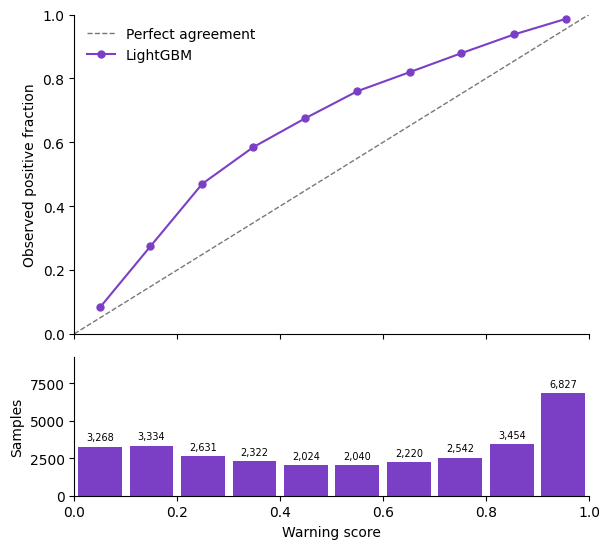

Warning-score ECE, 10 equal-width bins: 0.1221


,bin_lower,bin_upper,records,mean_probability,observed_frequency
0,0.0,0.1,3268,0.0505,0.0838
1,0.1,0.2,3334,0.1478,0.2738
2,0.2,0.3,2631,0.2487,0.4698
3,0.3,0.4,2322,0.3476,0.5844
4,0.4,0.5,2024,0.4486,0.6749
5,0.5,0.6,2040,0.5499,0.7598
6,0.6,0.7,2220,0.6515,0.8194
7,0.7,0.8,2542,0.7506,0.8780
8,0.8,0.9,3454,0.8549,0.9378
9,0.9,1.0,6827,0.9549,0.9862


Main speed model: 49,887 test rows | 134 cells | 40 recordings.
Held-out-cell model: 12,128 test rows | 26 cells.
Đã cập nhật hình PNG/PDF và các bảng chẩn đoán.
Không hiệu chỉnh mô hình, thay đổi dự đoán hoặc chọn lại ngưỡng.


In [19]:
# Warning reliability diagnostics and grouped +60 s forecast errors.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
from IPython.display import display

report_dir = Path(REPORT_DIR)
processed_dir = Path(PROCESSED_DIR)
diagnostic_keys = ["flight", "cell", "t10"]

def verify_keyed_predictions(saved, current, target, prediction_columns):
    required = diagnostic_keys + [target] + prediction_columns
    missing = sorted(set(required) - set(saved.columns))
    if missing:
        raise ValueError(f"File dự đoán thiếu cột: {missing}")

    for label, frame in [("saved", saved), ("current", current)]:
        if (
            frame[diagnostic_keys].isna().any().any()
            or frame.duplicated(diagnostic_keys).any()
        ):
            raise ValueError(f"{label}: khóa thiếu hoặc trùng.")

    current_index = pd.MultiIndex.from_frame(current[diagnostic_keys])
    saved_index = pd.MultiIndex.from_frame(saved[diagnostic_keys])
    if len(saved) != len(current) or not current_index.isin(saved_index).all():
        raise ValueError("File dự đoán không khớp tập mẫu hiện tại.")

    aligned = saved.set_index(diagnostic_keys).reindex(current_index)
    values = aligned[[target] + prediction_columns].to_numpy(dtype=float)
    if not np.isfinite(values).all():
        raise ValueError("Nhãn hoặc dự đoán chứa NaN/inf.")

    np.testing.assert_allclose(
        aligned[target].to_numpy(dtype=float),
        current[target].to_numpy(dtype=float),
        rtol=1e-7, atol=1e-7,
        err_msg="Nhãn đã lưu khác nhãn hiện tại.",
    )
    return aligned.reset_index()

# ----------------------------------------------------------
# 1. Reliability of the existing warning scores
# ----------------------------------------------------------
warning_saved = pd.read_parquet(
    processed_dir / "rq3_warning_predictions.parquet"
)
warning_aligned = verify_keyed_predictions(
    warning_saved,
    warning_test,
    "y_cong_60s",
    ["warning_score"],
)

scores = warning_aligned["warning_score"].to_numpy(dtype=float)
observed = warning_aligned["y_cong_60s"].to_numpy(dtype=float)

if ((scores < 0) | (scores > 1)).any():
    raise ValueError("Điểm cảnh báo nằm ngoài [0, 1].")
if not np.isin(observed, [0, 1]).all():
    raise ValueError("Nhãn cảnh báo phải là 0 hoặc 1.")

calibration = pd.DataFrame({
    "probability": scores,
    "observed": observed,
})
calibration["bin"] = np.minimum((scores * 10).astype(int), 9)

# Keep all ten bins, including empty bins.
cal_table = (
    calibration.groupby("bin")
    .agg(
        mean_probability=("probability", "mean"),
        observed_frequency=("observed", "mean"),
        records=("observed", "size"),
        positive_samples=("observed", "sum"),
    )
    .reindex(range(10))
    .rename_axis("bin")
    .reset_index()
)
for column in ["records", "positive_samples"]:
    cal_table[column] = cal_table[column].fillna(0).astype(int)

cal_table["bin_lower"] = cal_table["bin"] / 10
cal_table["bin_upper"] = (cal_table["bin"] + 1) / 10
cal_table["absolute_gap"] = (
    cal_table["observed_frequency"] - cal_table["mean_probability"]
).abs()
cal_table["sample_fraction"] = (
    cal_table["records"] / len(calibration)
)
cal_table["ece_contribution"] = (
    cal_table["sample_fraction"] * cal_table["absolute_gap"].fillna(0)
)
diagnostic_ece = float(cal_table["ece_contribution"].sum())

cal_table.to_csv(
    report_dir / "table_warning_calibration.csv",
    index=False, encoding="utf-8-sig",
)

# A shared score axis links reliability to sample support.
with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "axes.spines.top": False,
    "axes.spines.right": False,
    "figure.facecolor": "white",
    "axes.facecolor": "white",
}):
    fig, (ax, support_ax) = plt.subplots(
        2, 1, figsize=(6.2, 5.6), sharex=True,
        gridspec_kw={"height_ratios": [3, 1.3]},
    )

    ax.plot(
        [0, 1], [0, 1],
        linestyle="--", color="#777777", linewidth=1,
        label="Perfect agreement",
    )
    # NaN values in empty bins prevent lines crossing those bins.
    ax.plot(
        cal_table["mean_probability"],
        cal_table["observed_frequency"],
        "o-", color="#7B3FC6", linewidth=1.5, markersize=5,
        label="LightGBM",
    )
    ax.set(
        ylabel="Observed positive fraction",
        xlim=(0, 1), ylim=(0, 1),
    )
    ax.legend(frameon=False)

    centres = (cal_table["bin_lower"] + cal_table["bin_upper"]) / 2
    bars = support_ax.bar(
        centres, cal_table["records"],
        width=0.085, color="#7B3FC6",
    )
    support_ax.bar_label(
        bars,
        labels=[f"{n:,}" for n in cal_table["records"]],
        padding=3, fontsize=7, color="black", fontweight="normal",
    )
    support_ax.set(
        xlabel="Warning score",
        ylabel="Samples",
        ylim=(0, max(1, cal_table["records"].max()) * 1.35),
    )
    support_ax.set_xticks(np.linspace(0, 1, 6))

    fig.tight_layout()
    for extension in ["png", "pdf"]:
        fig.savefig(
            report_dir / f"fig_rq3_calibration.{extension}",
            dpi=300, bbox_inches="tight", facecolor="white",
        )
    plt.show()
    plt.close(fig)

# ----------------------------------------------------------
# 2. Selected regressor: errors on the main +60 s test set
# ----------------------------------------------------------
main_bundle = model_sets[60]
main_target = main_bundle["target"]

final_errors = verify_keyed_predictions(
    pd.read_parquet(processed_dir / "selected_predictions.parquet"),
    main_bundle["test"],
    main_target,
    ["prediction"],
)
final_errors["absolute_error"] = (
    final_errors[main_target] - final_errors["prediction"]
).abs()

error_cells = final_errors.groupby("cell").agg(
    MAE_kmh=("absolute_error", "mean"),
    records=("absolute_error", "size"),
    recordings=("flight", "nunique"),
)
error_flights = final_errors.groupby("flight").agg(
    MAE_kmh=("absolute_error", "mean"),
    records=("absolute_error", "size"),
    cells=("cell", "nunique"),
)

error_cells.to_csv(report_dir / "table_final_error_by_cell.csv")
error_flights.to_csv(report_dir / "table_final_error_by_flight.csv")

# ----------------------------------------------------------
# 3. Held-out-cell experiment: keep its errors separate
# ----------------------------------------------------------
unseen_rows = verify_keyed_predictions(
    pd.read_parquet(processed_dir / "rq3_unseen_predictions.parquet"),
    unseen_test,
    main_target,
    ["prediction_lightgbm", "prediction_persistence"],
)
unseen_rows["prediction"] = unseen_rows["prediction_lightgbm"]
unseen_rows["absolute_error"] = (
    unseen_rows[main_target] - unseen_rows["prediction"]
).abs()
unseen_rows["persistence_absolute_error"] = (
    unseen_rows[main_target] - unseen_rows["prediction_persistence"]
).abs()

unseen_cell_table = unseen_rows.groupby("cell").agg(
    MAE_kmh=("absolute_error", "mean"),
    persistence_MAE_kmh=("persistence_absolute_error", "mean"),
    records=("absolute_error", "size"),
    recordings=("flight", "nunique"),
)
unseen_cell_table["MAE_benefit_vs_persistence_kmh"] = (
    unseen_cell_table["persistence_MAE_kmh"]
    - unseen_cell_table["MAE_kmh"]
)
unseen_cell_table.to_csv(
    report_dir / "table_unseen_error_by_cell.csv"
)

print(f"Warning-score ECE, 10 equal-width bins: {diagnostic_ece:.4f}")
display(
    cal_table[[
        "bin_lower", "bin_upper", "records",
        "mean_probability", "observed_frequency",
    ]].round(4)
)
print(
    f"Main speed model: {len(final_errors):,} test rows | "
    f"{len(error_cells)} cells | {len(error_flights)} recordings."
)
print(
    f"Held-out-cell model: {len(unseen_rows):,} test rows | "
    f"{len(unseen_cell_table)} cells."
)
print("Đã cập nhật hình PNG/PDF và các bảng chẩn đoán.")
print("Không hiệu chỉnh mô hình, thay đổi dự đoán hoặc chọn lại ngưỡng.")

Kiểm tra độ tin cậy trên 30.662 mẫu test cho thấy tỷ lệ nhãn dương thực tế cao hơn điểm cảnh báo trung bình trong cả mười khoảng điểm. ECE với mười khoảng đều đạt 0,1221. Mặc dù mô hình đạt AP cao, các điểm đầu ra chưa nên được diễn giải trực tiếp thành xác suất xảy ra chuyển trạng thái tốc độ thấp. Kết quả này mô tả mô hình chưa hiệu chỉnh; nếu cần cung cấp xác suất nguy cơ, phải xây dựng bước hiệu chỉnh bằng dữ liệu trong tập huấn luyện và đánh giá riêng.

### Spatial error maps (Bản đồ sai số theo không gian)

Cells are reconstructed from the exported projected-grid metadata.
Cell identifiers represent grid indices, not latitude and longitude.
The two MAE maps use the same colour scale and geographic extent.

(Các ô được dựng từ metadata lưới chiếu đã xuất. Mã ô biểu diễn
chỉ số lưới, không phải vĩ độ và kinh độ. Hai bản đồ MAE dùng cùng
thang màu và phạm vi địa lý.)

MAE is averaged over test rows within each cell. Sample counts
describe observation support and should accompany interpretation.
Blank locations contain no mapped values for that experiment;
they do not indicate zero error.

(MAE được tính trung bình trên các dòng test trong từng ô.
Số mẫu cho biết lượng dữ liệu hỗ trợ và cần được xem cùng khi
diễn giải. Vùng không tô màu không có giá trị được vẽ trong thí
nghiệm tương ứng, không có nghĩa sai số bằng không.)

The street background provides present-day geographic context
for observations collected in 2018. Shared colours aid reading,
but differences between experiments do not isolate the effect
of spatial exclusion.

(Nền đường cung cấp bối cảnh địa lý hiện tại cho quan sát thu thập
năm 2018. Dùng chung màu giúp đọc hình, nhưng chênh lệch giữa hai
thí nghiệm không tách riêng tác động của việc loại ô khỏi train.)

In [8]:
# Spatial maps using verified metric-grid metadata.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.patches import Rectangle
from matplotlib.collections import PatchCollection
from matplotlib.colors import Normalize
from pyproj import CRS, Transformer

try:
    import contextily as ctx
except ImportError as exc:
    raise ImportError(
        "Thiếu contextily. Chạy `%pip install contextily` "
        "trong một ô Colab rồi chạy lại ô này."
    ) from exc

with Path(MANIFEST_FILE).open(encoding="utf-8") as file:
    map_manifest = json.load(file)

if map_manifest["run_id"] != RUN_ID:
    raise ValueError("Manifest không thuộc run hiện tại.")
if map_manifest["cell_encoding"] != "grid_x_grid_y":
    raise ValueError("Mã hóa ô không khớp cách dựng lưới.")

map_crs = CRS.from_user_input(map_manifest["grid_crs"])
map_size = float(map_manifest["grid_size_m"])
map_origin_x = float(map_manifest["grid_origin_x_m"])
map_origin_y = float(map_manifest["grid_origin_y_m"])

if map_crs != CRS.from_epsg(32634) or map_size != 100:
    raise ValueError("Thí nghiệm này yêu cầu EPSG:32634 và ô 100 m.")

if not np.isfinite([map_origin_x, map_origin_y]).all():
    raise ValueError("Gốc lưới không hợp lệ.")

# Reference cells also define a common map extent.
map_reference = pd.read_parquet(
    FEATURE_FILE, columns=["cell", "lat", "lon"]
).drop_duplicates()

if map_reference["cell"].duplicated().any():
    raise ValueError("Một mã ô có nhiều tọa độ tâm khác nhau.")

indices = map_reference["cell"].astype(str).str.extract(
    r"^(-?\d+)_(-?\d+)$"
)
if indices.isna().any().any():
    raise ValueError("Mã ô không đúng định dạng grid_x_grid_y.")

map_reference["x0"] = (
    map_origin_x + indices[0].to_numpy(dtype=float) * map_size
)
map_reference["y0"] = (
    map_origin_y + indices[1].to_numpy(dtype=float) * map_size
)

# Check reconstructed centres against the exported coordinates.
to_grid = Transformer.from_crs("EPSG:4326", map_crs, always_xy=True)
centre_x, centre_y = to_grid.transform(
    map_reference["lon"].to_numpy(),
    map_reference["lat"].to_numpy(),
)
centre_difference = np.hypot(
    centre_x - (map_reference["x0"].to_numpy() + map_size / 2),
    centre_y - (map_reference["y0"].to_numpy() + map_size / 2),
)
if (
    not np.isfinite(centre_difference).all()
    or centre_difference.max() > 1.0
):
    raise ValueError("Tâm ô dựng lại lệch tọa độ đã xuất quá 1 m.")

map_pad = 200.0
map_extent = (
    map_reference["x0"].min() - map_pad,
    map_reference["x0"].max() + map_size + map_pad,
    map_reference["y0"].min() - map_pad,
    map_reference["y0"].max() + map_size + map_pad,
)

map_style = {
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
}

def grid_map(
    table, value, title, unit, filename,
    cmap="viridis", vmin=0, vmax=None,
):
    data = (
        table.copy() if "cell" in table.columns
        else table.reset_index()
    )
    if data["cell"].isna().any() or data["cell"].duplicated().any():
        raise ValueError("Bảng bản đồ có mã ô thiếu hoặc trùng.")

    mapped_values = data[value].to_numpy(dtype=float)
    if (
        len(data) == 0
        or not np.isfinite(mapped_values).all()
        or (mapped_values < 0).any()
    ):
        raise ValueError("Giá trị bản đồ thiếu hoặc không hợp lệ.")

    data = data.merge(
        map_reference[["cell", "x0", "y0"]],
        on="cell", how="left", validate="one_to_one",
    )
    if data[["x0", "y0"]].isna().any().any():
        raise ValueError("Bảng sai số chứa ô không có trong dữ liệu nguồn.")

    upper = float(mapped_values.max()) if vmax is None else float(vmax)
    if upper <= vmin:
        upper = float(vmin) + 1
    if mapped_values.min() < vmin or mapped_values.max() > upper:
        raise ValueError("Thang màu không bao phủ toàn bộ giá trị.")

    with plt.rc_context(map_style):
        fig, ax = plt.subplots(figsize=(6.4, 7.0))
        xmin, xmax, ymin, ymax = map_extent
        ax.set_xlim(xmin, xmax)
        ax.set_ylim(ymin, ymax)
        ax.set_aspect("equal")

        # Reuse the Notebook 01 approach:
        # identify the app, bound requests, and reuse the same background.
        import inspect

        required_options = {
            "headers", "timeout", "n_connections", "use_cache"
        }
        available_options = set(
            inspect.signature(ctx.bounds2img).parameters
        )
        if not required_options.issubset(available_options):
            plt.close(fig)
            raise RuntimeError(
                "Phiên bản contextily thiếu tùy chọn tải nền cần thiết. "
                "Cần xử lý tại ô môi trường, không cài thêm trong ô vẽ."
            )

        # Persistent cache for revisiting this map extent.
        basemap_cache_dir = Path(REPORT_DIR) / ".basemap_cache"
        basemap_cache_dir.mkdir(parents=True, exist_ok=True)
        ctx.set_cache_dir(str(basemap_cache_dir))

        provider = ctx.providers.OpenStreetMap.Mapnik
        map_zoom = 15

        to_web = Transformer.from_crs(
            map_crs, "EPSG:3857", always_xy=True
        )
        web_bounds = to_web.transform_bounds(
            xmin, ymin, xmax, ymax, densify_pts=21
        )

        # Keep the projected background in RAM for subsequent figures.
        background_store = globals().setdefault(
            "_pneuma_background_store", {}
        )
        background_key = (
            provider.build_url(),
            map_zoom,
            tuple(web_bounds),
            map_crs.to_string(),
        )

        try:
            if background_key not in background_store:
                image_web, extent_web = ctx.bounds2img(
                    *web_bounds,
                    zoom=map_zoom,
                    source=provider,
                    headers={
                        "User-Agent":
                        "pNEUMA-Research-Notebook/1.0 "
                        "(academic visualization)"
                    },
                    use_cache=True,
                    max_retries=0,
                    n_connections=1,
                    timeout=15,
                )

                if (
                    image_web.ndim != 3
                    or image_web.shape[2] not in (3, 4)
                    or image_web.size == 0
                ):
                    raise ValueError("Ảnh nền không đúng định dạng.")

                # Catch a repeated identical placeholder across multiple tiles.
                # This is a limited check, not complete image-content validation.
                if (
                    image_web.shape[0] % 256 == 0
                    and image_web.shape[1] % 256 == 0
                ):
                    tiles = [
                        image_web[y:y + 256, x:x + 256]
                        for y in range(0, image_web.shape[0], 256)
                        for x in range(0, image_web.shape[1], 256)
                    ]
                    if len(tiles) > 1 and all(
                        np.array_equal(tiles[0], tile)
                        for tile in tiles[1:]
                    ):
                        raise ValueError(
                            "Nền gồm các ô ảnh giống hệt nhau; "
                            "có thể máy chủ đang trả ảnh thông báo."
                        )

                image_grid, extent_grid = ctx.warp_tiles(
                    image_web,
                    extent_web,
                    t_crs=map_crs.to_string(),
                )
                background_store[background_key] = (
                    image_grid, extent_grid
                )

            image_grid, extent_grid = background_store[background_key]
            ax.imshow(
                image_grid,
                extent=extent_grid,
                interpolation="bilinear",
                alpha=0.65,
                zorder=0,
            )
            ax.set_xlim(xmin, xmax)
            ax.set_ylim(ymin, ymax)
            ctx.add_attribution(
                ax, provider.attribution, font_size=6
            )

        except Exception as exc:
            plt.close(fig)
            raise RuntimeError(
                "Chưa lấy được nền đường hợp lệ; hình này chưa được xuất. "
                "Không chạy lặp liên tục hoặc đổi nguồn để vượt lỗi. "
                f"Chi tiết: {exc}"
            ) from exc

        patches = [
            Rectangle((x, y), map_size, map_size)
            for x, y in zip(data["x0"], data["y0"])
        ]
        collection = PatchCollection(
            patches,
            cmap=cmap,
            norm=Normalize(vmin=vmin, vmax=upper),
            edgecolor="#EEEEEE",
            linewidth=0.35,
            zorder=2,
        )
        collection.set_array(data[value].to_numpy(dtype=float))
        ax.add_collection(collection)

        fig.colorbar(
            collection, ax=ax, shrink=0.72, pad=0.025, label=unit
        )

        # Scale in projected metres.
        sx = xmin + 0.07 * (xmax - xmin)
        sy = ymin + 0.09 * (ymax - ymin)
        ax.plot([sx, sx + 200], [sy, sy], color="black", linewidth=2)
        ax.text(
            sx + 100, sy + 30, "200 m",
            ha="center", va="bottom", fontsize=9,
        )

        # Projected grid north, explicitly labelled.
        ax.annotate(
            "", xy=(0.94, 0.95), xytext=(0.94, 0.86),
            xycoords="axes fraction",
            arrowprops={"arrowstyle": "->", "color": "black"},
        )
        ax.text(
            0.94, 0.845, "Grid N", transform=ax.transAxes,
            ha="center", va="top", fontsize=8,
        )
        ax.set_axis_off()
        fig.tight_layout()

        for extension in ["png", "pdf"]:
            fig.savefig(
                Path(REPORT_DIR) / f"{filename}.{extension}",
                dpi=300, bbox_inches="tight", facecolor="white",
            )
        plt.show()
        plt.close(fig)

    print(f"{title}: {len(data):,} cells.")
    if "records" in data.columns:
        print(
            f"Test rows: {data['records'].sum():,}; "
            f"per cell: {data['records'].min():,}"
            f"–{data['records'].max():,}."
        )
    print(f"Saved: {filename}.png and .pdf")

print("Map helper ready: verified 100 m grid with street basemap.")

Map helper ready: verified 100 m grid with street basemap.


### Spatial benefit in held-out cells
### Lợi ích dự báo tại các ô giữ riêng

The map shows cell-level MAE differences:
Persistence minus LightGBM. Blue indicates lower LightGBM error;
orange indicates lower Persistence error. Hatched cells belong
to the observed grid but are not evaluated in this experiment.

(Bản đồ thể hiện chênh lệch MAE từng ô: Persistence trừ LightGBM.
Xanh nghĩa là LightGBM có sai số thấp hơn; cam nghĩa là Persistence
có sai số thấp hơn. Ô gạch chéo thuộc lưới quan sát nhưng không
được đánh giá trong thí nghiệm này.)

The adjacent bars compare overall MAE on the same test samples.
Overall MAE is calculated across individual samples, not by
giving each cell equal weight.

(Các thanh bên cạnh so sánh MAE chung trên cùng các mẫu test.
MAE chung được tính trên từng mẫu, không gán trọng số bằng nhau
cho mỗi ô.)

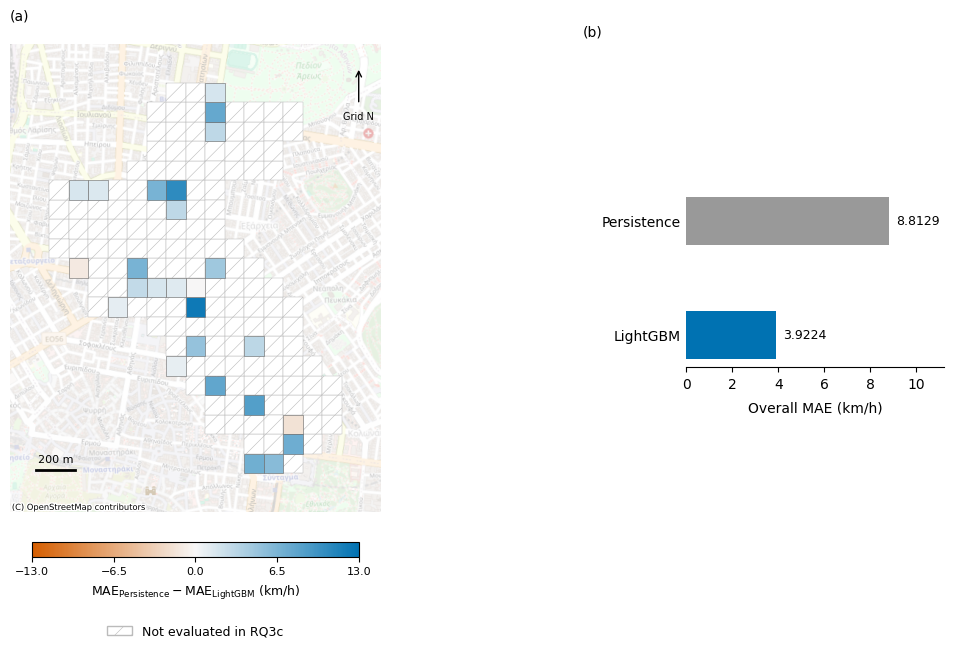

Caption

Spatial transfer of +60-second speed prediction to 26 grid cells excluded from model fitting. (a) Cell-level MAE of Persistence minus that of LightGBM: blue indicates lower LightGBM error, orange indicates lower Persistence error, and zero indicates equal MAE. Hatching marks the other 128 observed cells, which are not evaluated in this experiment. (b) Overall MAE across the same 12,128 test samples from 38 held-out recordings. LightGBM reduces overall MAE by 55.49% and has lower cell-level MAE in 23 of 26 cells (3 higher; 0 tied). Overall MAE weights test samples equally; cell support ranges from 20 to 1,107 samples. Results use one cell-selection seed and one model seed (both 42), fixed LightGBM parameters, and available current and historical observations at test cells. The street background provides present-day context for traffic observations collected in 2018.

Đã cập nhật hình PNG/PDF, bảng từng ô và caption riêng.


In [14]:
# RQ3c — Final figure: spatial benefit and overall MAE.
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from matplotlib.collections import PatchCollection
from matplotlib.patches import Rectangle, Patch
from matplotlib.colors import TwoSlopeNorm, LinearSegmentedColormap
from pyproj import Transformer
from IPython.display import display, Markdown

# ----------------------------------------------------------
# 1. Calculate all results from the saved test predictions.
# ----------------------------------------------------------
pred = pd.read_parquet(
    Path(PROCESSED_DIR) / "rq3_unseen_predictions.parquet"
)
keys = ["flight", "cell", "t10"]
required = keys + [
    "y_60s", "prediction_lightgbm", "prediction_persistence"
]
missing = sorted(set(required) - set(pred.columns))
if missing:
    raise ValueError(f"Thiếu cột: {missing}")

if (
    pred.empty
    or pred[keys].isna().any().any()
    or pred.duplicated(keys).any()
):
    raise ValueError("Dữ liệu dự đoán rỗng hoặc khóa thiếu/trùng.")

values = pred[required[3:]].to_numpy(dtype=float)
if not np.isfinite(values).all():
    raise ValueError("Nhãn hoặc dự đoán chứa NaN/inf.")

pred["error_lightgbm"] = (
    pred["y_60s"] - pred["prediction_lightgbm"]
).abs()
pred["error_persistence"] = (
    pred["y_60s"] - pred["prediction_persistence"]
).abs()

cell_results = (
    pred.groupby("cell", as_index=False)
    .agg(
        MAE_lightgbm=("error_lightgbm", "mean"),
        MAE_persistence=("error_persistence", "mean"),
        records=("error_lightgbm", "size"),
        recordings=("flight", "nunique"),
    )
)
cell_results["MAE_benefit_kmh"] = (
    cell_results["MAE_persistence"] - cell_results["MAE_lightgbm"]
)

mae_lgbm = float(pred["error_lightgbm"].mean())
mae_persistence = float(pred["error_persistence"].mean())
reduction_pct = (
    100 * (1 - mae_lgbm / mae_persistence)
    if mae_persistence > 0 else np.nan
)

# ----------------------------------------------------------
# 2. Reuse verified coordinates and the existing street background.
# ----------------------------------------------------------
needed = [
    "map_reference", "map_extent", "map_crs", "map_size",
    "_pneuma_background_store", "ctx",
]
missing = [name for name in needed if name not in globals()]
if missing:
    raise RuntimeError(
        "Chạy phần chuẩn bị lưới và nền đường trước. Thiếu: "
        + ", ".join(missing)
    )

reference = map_reference[["cell", "x0", "y0"]].copy()
if reference["cell"].isna().any() or reference["cell"].duplicated().any():
    raise ValueError("Lưới tham chiếu có mã ô thiếu/trùng.")
if not set(cell_results["cell"]).issubset(set(reference["cell"])):
    raise ValueError("Có ô test không thuộc lưới tham chiếu.")

mapped = reference.merge(
    cell_results, on="cell", how="left", validate="one_to_one"
)
inside = mapped.loc[mapped["records"].notna()].copy()
outside = mapped.loc[mapped["records"].isna()].copy()

xmin, xmax, ymin, ymax = map_extent
to_web = Transformer.from_crs(
    map_crs, "EPSG:3857", always_xy=True
)
web_bounds = to_web.transform_bounds(
    xmin, ymin, xmax, ymax, densify_pts=21
)
provider = ctx.providers.OpenStreetMap.Mapnik
background_key = (
    provider.build_url(), 15, tuple(web_bounds), map_crs.to_string()
)
if background_key not in _pneuma_background_store:
    raise RuntimeError(
        "Chưa có nền đúng phạm vi. Chạy lại phần tải nền đã sửa trước."
    )

background_image, background_extent = (
    _pneuma_background_store[background_key]
)

benefit = inside["MAE_benefit_kmh"].to_numpy(dtype=float)
limit = max(1.0, float(np.ceil(np.abs(benefit).max())))
colour_map = LinearSegmentedColormap.from_list(
    "rq3_spatial_benefit",
    ["#D55E00", "#F7F7F7", "#0072B2"],
)
colour_norm = TwoSlopeNorm(vmin=-limit, vcenter=0, vmax=limit)

tolerance = 1e-9
n_better = int((benefit > tolerance).sum())
n_worse = int((benefit < -tolerance).sum())
n_tied = len(inside) - n_better - n_worse

# ----------------------------------------------------------
# 3. Draw only the evidence. Explanations go in the caption.
# ----------------------------------------------------------
with plt.rc_context({
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
    "hatch.linewidth": 0.4,
}):
    fig = plt.figure(figsize=(10.6, 6.6))
    layout = fig.add_gridspec(
        1, 2, width_ratios=[1.25, 1],
        left=0.04, right=0.97,
        top=0.95, bottom=0.24,
        wspace=0.38,
    )
    map_ax = fig.add_subplot(layout[0, 0])
    right_ax = fig.add_subplot(layout[0, 1])
    right_ax.set_axis_off()

    map_ax.imshow(
        background_image,
        extent=background_extent,
        alpha=0.30,
        zorder=0,
    )

    if not outside.empty:
        map_ax.add_collection(PatchCollection(
            [
                Rectangle((x, y), map_size, map_size)
                for x, y in zip(outside["x0"], outside["y0"])
            ],
            facecolor="white",
            edgecolor="#BBBBBB",
            linewidth=0.35,
            hatch="//",
            zorder=1,
        ))

    layer = PatchCollection(
        [
            Rectangle((x, y), map_size, map_size)
            for x, y in zip(inside["x0"], inside["y0"])
        ],
        cmap=colour_map,
        norm=colour_norm,
        edgecolor="#666666",
        linewidth=0.4,
        zorder=2,
    )
    layer.set_array(benefit)
    map_ax.add_collection(layer)

    map_ax.set_xlim(xmin, xmax)
    map_ax.set_ylim(ymin, ymax)
    map_ax.set_aspect("equal")
    map_ax.set_axis_off()
    map_ax.set_title("(a)", loc="left", fontsize=10)

    # Metric scale and projected grid north.
    sx = xmin + 0.07 * (xmax - xmin)
    sy = ymin + 0.09 * (ymax - ymin)
    map_ax.plot(
        [sx, sx + 200], [sy, sy],
        color="black", linewidth=2, zorder=5,
    )
    map_ax.text(
        sx + 100, sy + 30, "200 m",
        ha="center", va="bottom", fontsize=8, zorder=5,
    )
    map_ax.annotate(
        "", xy=(0.94, 0.95), xytext=(0.94, 0.87),
        xycoords="axes fraction",
        arrowprops={"arrowstyle": "->", "color": "black"},
    )
    map_ax.text(
        0.94, 0.855, "Grid N",
        transform=map_ax.transAxes,
        ha="center", va="top", fontsize=7,
    )
    ctx.add_attribution(
        map_ax, provider.attribution, font_size=6
    )

    # Horizontal colour bar: the measured difference is explicit.
    colour_ax = map_ax.inset_axes([0.06, -0.095, 0.88, 0.032])
    colourbar = fig.colorbar(
        layer, cax=colour_ax, orientation="horizontal"
    )
    colourbar.set_ticks([-limit, -limit / 2, 0, limit / 2, limit])
    colourbar.ax.tick_params(labelsize=8)
    colourbar.set_label(
        r"$\mathrm{MAE}_{\mathrm{Persistence}}"
        r" - \mathrm{MAE}_{\mathrm{LightGBM}}$ (km/h)",
        fontsize=9, labelpad=5,
    )

    map_ax.legend(
        handles=[
            Patch(
                facecolor="white", edgecolor="#BBBBBB",
                hatch="//", label="Not evaluated in RQ3c",
            )
        ],
        loc="upper center",
        bbox_to_anchor=(0.5, -0.23),
        frameon=False, fontsize=9,
        borderaxespad=0,
    )

    right_ax.set_title("(b)", loc="left", fontsize=10)

    # Reserve space for method names inside the right panel.
    bar_ax = right_ax.inset_axes([0.28, 0.31, 0.70, 0.38])
    bars = bar_ax.barh(
        [0, 1],
        [mae_persistence, mae_lgbm],
        height=0.42,
        color=["#999999", "#0072B2"],
    )
    bar_ax.set_yticks([0, 1], ["Persistence", "LightGBM"])
    bar_ax.invert_yaxis()
    bar_ax.set_xlim(0, max(mae_persistence, mae_lgbm) * 1.27)
    bar_ax.set_xlabel("Overall MAE (km/h)", labelpad=7)
    bar_ax.bar_label(
        bars,
        labels=[f"{mae_persistence:.4f}", f"{mae_lgbm:.4f}"],
        padding=5, fontsize=9,
    )
    bar_ax.tick_params(axis="y", length=0)
    bar_ax.spines["top"].set_visible(False)
    bar_ax.spines["right"].set_visible(False)
    bar_ax.spines["left"].set_visible(False)

    for extension in ["png", "pdf"]:
        fig.savefig(
            Path(REPORT_DIR) / f"fig_rq3_spatial_transfer.{extension}",
            dpi=300, bbox_inches="tight", facecolor="white",
        )
    plt.show()
    plt.close(fig)

cell_results.to_csv(
    Path(REPORT_DIR) / "table_rq3_spatial_benefit.csv",
    index=False, encoding="utf-8-sig",
)

# Caption is displayed separately and saved alongside the figure.
caption = (
    f"Spatial transfer of +60-second speed prediction to "
    f"{len(inside)} grid cells excluded from model fitting. "
    f"(a) Cell-level MAE of Persistence minus that of LightGBM: "
    f"blue indicates lower LightGBM error, orange indicates lower "
    f"Persistence error, and zero indicates equal MAE. "
    f"Hatching marks the other {len(outside)} observed cells, "
    f"which are not evaluated in this experiment. "
    f"(b) Overall MAE across the same {len(pred):,} test samples "
    f"from {pred['flight'].nunique()} held-out recordings. "
    f"LightGBM reduces overall MAE by {reduction_pct:.2f}% "
    f"and has lower cell-level MAE in {n_better} of {len(inside)} cells "
    f"({n_worse} higher; {n_tied} tied). "
    f"Overall MAE weights test samples equally; cell support ranges "
    f"from {int(inside['records'].min()):,} to "
    f"{int(inside['records'].max()):,} samples. "
    f"Results use one cell-selection seed and one model seed "
    f"(both 42), fixed LightGBM parameters, and available current "
    f"and historical observations at test cells. "
    f"The street background provides present-day context "
    f"for traffic observations collected in 2018."
)

(Path(REPORT_DIR) / "caption_rq3_spatial_transfer.txt").write_text(
    caption + "\n", encoding="utf-8"
)

display(Markdown("Caption\n\n" + caption))
print("Đã cập nhật hình PNG/PDF, bảng từng ô và caption riêng.")

**Caption đặt dưới hình:**

> Khả năng dự báo tốc độ trước 60 giây tại 26 ô lưới được loại khỏi huấn luyện. (a) Chênh lệch MAE giữa Persistence và LightGBM: màu xanh biểu thị LightGBM có sai số thấp hơn, màu cam biểu thị Persistence có sai số thấp hơn; các ô gạch chéo không được đánh giá trong thí nghiệm này. (b) MAE chung trên cùng 12.128 mẫu test thuộc 38 recording giữ riêng. LightGBM giảm MAE chung 55,49% và đạt sai số thấp hơn tại 23/26 ô. Mỗi ô có 20–1.107 mẫu; MAE chung được tính với trọng số bằng nhau cho từng mẫu. Nền đường hiện tại cung cấp bối cảnh địa lý cho dữ liệu giao thông năm 2018.

**Kết luận và diễn giải đặt trong phần kết quả:**

> LightGBM với tham số cố định đạt MAE 3,9224 km/h tại các ô không dùng để huấn luyện, so với 8,8129 km/h của Persistence. Mô hình có sai số thấp hơn tại 23/26 ô, cho thấy lợi ích dự báo xuất hiện ở phần lớn các ô được chọn; tuy nhiên, Persistence vẫn tốt hơn tại ba ô còn lại. Kết quả này ủng hộ khả năng dự báo tại các ô được giữ riêng trong khu vực nghiên cứu, khi vẫn có thông tin hiện tại và lịch sử tại những ô đó. Bằng chứng giới hạn ở một lần chọn ô theo điều kiện số mẫu và một seed mô hình, đều bằng 42; chưa chứng minh khả năng chuyển sang thành phố mới hoặc tách riêng tác động của việc loại ô khỏi huấn luyện.

<a id="explain"></a>

# Part IV · SHAP and diagnosis (Phần IV · SHAP và chẩn đoán)

## SHAP explanations and stability
## Giải thích SHAP và độ ổn định

Phân tích này giải thích mô hình LightGBM đã chọn để dự báo tốc độ
+60 giây, không phải mô hình phân loại cảnh báo. Tối đa 5.000 mẫu
test được chọn ngẫu nhiên với seed cố định. Đặc trưng được xếp
theo trung bình độ lớn tuyệt đối của SHAP; giá trị cao hơn thể hiện
đóng góp lớn hơn vào dự đoán trên mẫu được giải thích.

Hình tổng hợp cho biết độ lớn và chiều đóng góp: SHAP dương nâng
dự đoán so với mức tham chiếu, SHAP âm hạ dự đoán. Màu của điểm
biểu diễn giá trị đặc trưng thấp hoặc cao trong từng hàng, không
biểu diễn sai số dự báo.

Ba hình phụ mô tả quan hệ giữa giá trị đặc trưng và đóng góp SHAP
của ba biến đứng đầu. Đây là cách mô hình sử dụng thông tin,
không phải bằng chứng về tác động nhân quả đối với giao thông.

Độ ổn định được kiểm tra bằng cách huấn luyện lại cùng cấu hình
với seed 0, 1 và 2, rồi tính SHAP trên cùng tối đa 2.000 mẫu.
Số biến chung trong top 5 đo sự ổn định của thành viên nhóm đầu;
không chứng minh thứ hạng hoặc chiều đóng góp hoàn toàn ổn định.
Các biến lịch sử tương quan có thể phân chia đóng góp với nhau.

Đã khôi phục LightGBM: tuned | +60 giây | seed: 0
Calculating SHAP on 5,000 test samples...


/tmp/ipykernel_6076/1450710403.py:209: FutureWarning: The NumPy global RNG was seeded by calling `np.random.seed`. In a future version this function will no longer use the global RNG. Pass `rng` explicitly to opt-in to the new behaviour and silence this warning.
  shap.summary_plot(


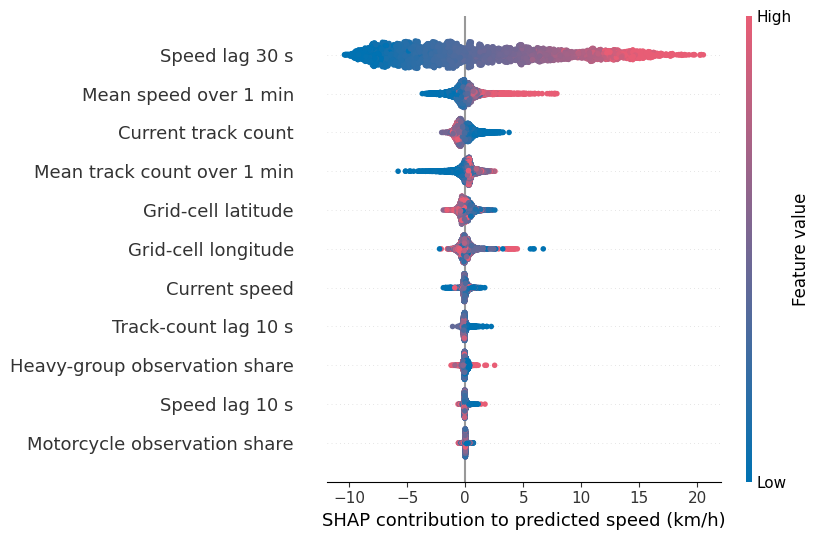

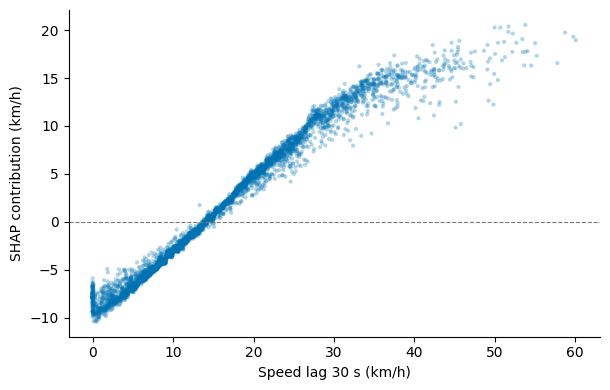

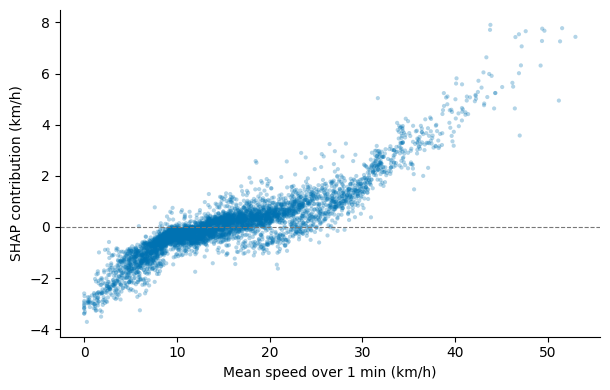

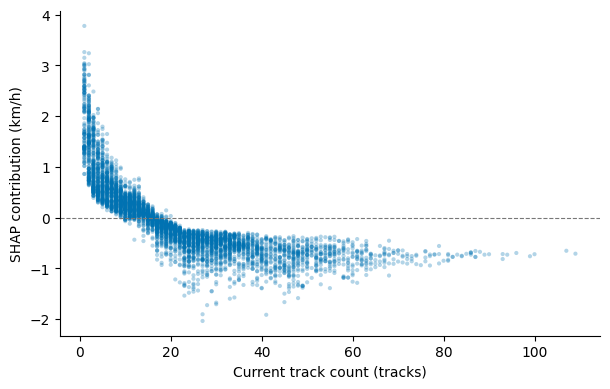

SHAP stability: fitting seed 0...
SHAP stability: fitting seed 1...
SHAP stability: fitting seed 2...


,feature,display_name,mean_absolute_SHAP,rank
0,s_lag3,Speed lag 30 s,5.7987,1
1,s_ma1m,Mean speed over 1 min,0.8239,2
2,n_veh,Current track count,0.5740,3
3,n_ma1m,Mean track count over 1 min,0.5192,4
4,cell_lat,Grid-cell latitude,0.3678,5
5,cell_lon,Grid-cell longitude,0.3629,6
6,speed,Current speed,0.1714,7
7,n_lag1,Track-count lag 10 s,0.1488,8
8,share_heavy,Heavy-group observation share,0.1333,9
9,s_lag1,Speed lag 10 s,0.1027,10


,seed,sample_rows,top_5_features,common_top_5_count
0,0,2000,"s_lag3, s_ma1m, n_veh, n_ma1m, cell_lon",5
1,1,2000,"s_lag3, s_ma1m, n_veh, n_ma1m, cell_lon",5
2,2,2000,"s_lag3, s_ma1m, n_veh, n_ma1m, cell_lon",5


Caption hình tổng hợp

Đóng góp SHAP vào dự báo tốc độ +60 giây của LightGBM bản tuned, trên 5,000 mẫu test được chọn với seed 42. Các hàng được xếp theo trung bình độ lớn tuyệt đối của SHAP. Mỗi điểm là một mẫu; vị trí ngang thể hiện đóng góp nâng hoặc hạ dự đoán so với mức tham chiếu, đơn vị km/h. Màu xanh biểu diễn giá trị đặc trưng thấp, màu hồng biểu diễn giá trị cao trong từng hàng. Kết quả giải thích mô hình, không xác định tác động nhân quả.

Nhận xét theo kết quả

Trên mẫu được giải thích, ba đặc trưng có trung bình độ lớn đóng góp SHAP cao nhất là Speed lag 30 s: 5.799 km/h; Mean speed over 1 min: 0.824 km/h; Current track count: 0.574 km/h. Các giá trị này đo đóng góp vào dự đoán, không phải sai số MAE hoặc tác động nhân quả. Trên cùng 2,000 mẫu dùng để kiểm tra ba seed, có 5/5 đặc trưng cùng xuất hiện trong top 5 của cả ba lần huấn luyện. Phép kiểm tra này chỉ mô tả sự ổn định của nhóm đặc trưng đứng đầu trên một cách chia dữ liệu.

Đã lưu PNG/PDF, caption riêng, bảng SHAP và cấu hình.


In [16]:
# SHAP for the selected +60-second speed regressor.
import json
from pathlib import Path

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import shap

from matplotlib.colors import LinearSegmentedColormap
from sklearn.base import clone
from IPython.display import display, Markdown

SHAP_VERIFIED = False
report_dir = Path(REPORT_DIR)
sample_seed = 42
stability_seeds = [0, 1, 2]

# Restore and verify the saved model before explaining it.
import hashlib
import joblib

def shap_file_hash(path):
    checksum = hashlib.sha256()
    with Path(path).open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            checksum.update(chunk)
    return checksum.hexdigest()

model_path = Path(MODEL_DIR) / "selected_lightgbm.joblib"
handover_path = Path(MODEL_DIR) / "handover.json"

for path in [model_path, handover_path]:
    if not path.is_file():
        raise FileNotFoundError(f"Thiếu checkpoint đã lưu: {path}")

with handover_path.open(encoding="utf-8") as file:
    shap_handover = json.load(file)

if (
    shap_handover["run_id"] != RUN_ID
    or shap_handover["horizon_seconds"] != 60
):
    raise ValueError("Checkpoint không thuộc run và mốc +60 giây hiện tại.")

for path, expected_hash in [
    (model_path, shap_handover["model_sha256"]),
    (FEATURE_FILE, shap_handover["feature_sha256"]),
    (
        Path(REPORT_DIR) / "split_manifest.json",
        shap_handover["split_manifest_sha256"],
    ),
]:
    if shap_file_hash(path) != expected_hash:
        raise ValueError(f"File không khớp checkpoint: {path}")

bundle = model_sets[60]
target = bundle["target"]
if target != shap_handover["target"]:
    raise ValueError("Nhãn hiện tại khác nhãn của checkpoint.")

# Load the model generated and verified by this notebook.
restored_model = joblib.load(model_path)
features = list(restored_model.feature_name_)
if features != shap_handover["predictors_in_order"]:
    raise ValueError("Thứ tự đầu vào mô hình khác thông tin bàn giao.")

final_lightgbm = restored_model
selected_lightgbm_version = shap_handover["selected_version"]

print(
    "Đã khôi phục LightGBM:",
    selected_lightgbm_version,
    "| +60 giây | seed:",
    shap_handover["model_seed"],
)

if target != "y_60s":
    raise ValueError("SHAP này dành cho mô hình tốc độ +60 giây.")
if any(name.startswith("y_") for name in features):
    raise ValueError("Nhãn tương lai xuất hiện trong đầu vào.")

shap_train = bundle["train"]
shap_test = bundle["test"]
if set(shap_train["flight"]) & set(shap_test["flight"]):
    raise ValueError("Recording train/test giao nhau.")

for label, frame in [("train", shap_train), ("test", shap_test)]:
    if frame.empty or not np.isfinite(
        frame[features + [target]].to_numpy(dtype=float)
    ).all():
        raise ValueError(f"{label}: dữ liệu rỗng hoặc chứa NaN/inf.")

display_names = {
    "speed": "Current speed",
    "s_lag1": "Speed lag 10 s",
    "s_lag3": "Speed lag 30 s",
    "s_ma1m": "Mean speed over 1 min",
    "n_veh": "Current track count",
    "n_lag1": "Track-count lag 10 s",
    "n_ma1m": "Mean track count over 1 min",
    "share_2w": "Motorcycle observation share",
    "share_heavy": "Heavy-group observation share",
    "cell_lat": "Grid-cell latitude",
    "cell_lon": "Grid-cell longitude",
}
if set(features) != set(display_names):
    raise ValueError("Danh sách đầu vào khác bộ 11 biến đã khai báo.")

# Sample positions, keeping keys for traceability.
sample_positions = np.random.RandomState(sample_seed).choice(
    len(shap_test), size=min(5000, len(shap_test)), replace=False
)
sample_rows = shap_test.iloc[sample_positions].copy()
X_shap = sample_rows[features].copy()
X_shap_display = X_shap.rename(columns=display_names)
shap_sample_size = len(X_shap)

def checked_shap(model, inputs):
    explainer = shap.TreeExplainer(
        model,
        model_output="raw",
        feature_perturbation="tree_path_dependent",
    )
    values = np.asarray(
        explainer.shap_values(inputs, check_additivity=True),
        dtype=float,
    )
    if values.shape != inputs.shape or not np.isfinite(values).all():
        raise ValueError("Kết quả SHAP không đúng dạng hồi quy một đầu ra.")

    base = np.asarray(explainer.expected_value, dtype=float).reshape(-1)
    if base.size != 1 or not np.isfinite(base).all():
        raise ValueError("Giá trị tham chiếu SHAP không hợp lệ.")

    np.testing.assert_allclose(
        base[0] + values.sum(axis=1),
        model.predict(inputs),
        rtol=1e-5, atol=1e-5,
        err_msg="Tổng SHAP không khớp dự đoán mô hình.",
    )
    return values, float(base[0])

print(f"Calculating SHAP on {shap_sample_size:,} test samples...")
shap_values, shap_base_value = checked_shap(final_lightgbm, X_shap)

shap_importance = pd.DataFrame({
    "feature": features,
    "display_name": [display_names[name] for name in features],
    "mean_absolute_SHAP": np.abs(shap_values).mean(axis=0),
}).sort_values(
    ["mean_absolute_SHAP", "feature"],
    ascending=[False, True],
).reset_index(drop=True)
shap_importance["rank"] = np.arange(1, len(features) + 1)

# Save values, inputs and keys for reproducing the figures.
shap_detail = sample_rows[
    ["flight", "cell", "t10", target] + features
].copy().reset_index(drop=True)
for position, feature in enumerate(features):
    shap_detail[f"SHAP_{feature}"] = shap_values[:, position]
shap_detail["SHAP_base_value"] = shap_base_value
shap_detail.to_parquet(
    Path(PROCESSED_DIR) / "shap_explanations.parquet",
    index=False,
)
shap_importance.to_csv(
    report_dir / "table_shap.csv",
    index=False, encoding="utf-8-sig",
)

# ----------------------------------------------------------
# Figures: no long titles or conclusions inside the figure.
# ----------------------------------------------------------
shap_style = {
    "font.family": "DejaVu Sans",
    "font.size": 10,
    "font.weight": "normal",
    "axes.titleweight": "normal",
    "axes.labelweight": "normal",
    "text.color": "black",
    "axes.labelcolor": "black",
    "xtick.color": "black",
    "ytick.color": "black",
    "figure.facecolor": "white",
    "axes.facecolor": "white",
}
shap_colours = LinearSegmentedColormap.from_list(
    "feature_value", ["#0072B2", "#E85D75"]
)

def save_shap_figure(fig, stem):
    for extension in ["png", "pdf"]:
        fig.savefig(
            report_dir / f"{stem}.{extension}",
            dpi=300, bbox_inches="tight", facecolor="white",
        )
    plt.show()
    plt.close(fig)

captions = {}

with plt.rc_context(shap_style):
    # Fix randomness used for distributing overlapping points.
    random_state_before = np.random.get_state()
    try:
        np.random.seed(sample_seed)
        shap.summary_plot(
            shap_values,
            X_shap_display,
            show=False,
            max_display=len(features),
            cmap=shap_colours,
            plot_size=(8.4, 5.5),
        )
    finally:
        np.random.set_state(random_state_before)

    fig = plt.gcf()
    fig.axes[0].set_xlabel("SHAP contribution to predicted speed (km/h)")
    fig.axes[0].set_title("")
    save_shap_figure(fig, "fig_shap")

captions["fig_shap"] = (
    f"Đóng góp SHAP vào dự báo tốc độ +60 giây của LightGBM "
    f"bản {selected_lightgbm_version}, trên {shap_sample_size:,} mẫu test "
    f"được chọn với seed {sample_seed}. Các hàng được xếp theo trung bình "
    f"độ lớn tuyệt đối của SHAP. Mỗi điểm là một mẫu; vị trí ngang thể hiện "
    f"đóng góp nâng hoặc hạ dự đoán so với mức tham chiếu, đơn vị km/h. "
    f"Màu xanh biểu diễn giá trị đặc trưng thấp, màu hồng biểu diễn giá trị "
    f"cao trong từng hàng. Kết quả giải thích mô hình, không xác định "
    f"tác động nhân quả."
)

top_three_features = shap_importance["feature"].head(3).tolist()
units = {
    "speed": "km/h", "s_lag1": "km/h", "s_lag3": "km/h",
    "s_ma1m": "km/h", "n_veh": "tracks", "n_lag1": "tracks",
    "n_ma1m": "tracks", "share_2w": "fraction",
    "share_heavy": "fraction",
    "cell_lat": "degrees", "cell_lon": "degrees",
}

for feature in top_three_features:
    column = features.index(feature)
    stem = f"fig_shap_dep_{feature}"

    with plt.rc_context(shap_style):
        fig, ax = plt.subplots(figsize=(6.2, 4))
        ax.scatter(
            X_shap[feature],
            shap_values[:, column],
            s=9, alpha=0.30,
            color="#0072B2", edgecolors="none",
            rasterized=True,
        )
        ax.axhline(0, color="#777777", linestyle="--", linewidth=0.8)
        ax.set(
            xlabel=f"{display_names[feature]} ({units[feature]})",
            ylabel="SHAP contribution (km/h)",
        )
        ax.spines["top"].set_visible(False)
        ax.spines["right"].set_visible(False)
        fig.tight_layout()
        save_shap_figure(fig, stem)

    captions[stem] = (
        f"Quan hệ giữa {display_names[feature]} và đóng góp SHAP của biến "
        f"này vào dự báo tốc độ +60 giây trên {shap_sample_size:,} mẫu test. "
        f"Mỗi điểm là một mẫu; SHAP dương nâng dự đoán và SHAP âm hạ dự đoán "
        f"so với mức tham chiếu. Sự phân tán theo chiều dọc còn phản ánh "
        f"bối cảnh các đặc trưng khác trong mô hình; không diễn giải thành "
        f"tác động nhân quả."
    )

# ----------------------------------------------------------
# Stability: same 2,000-or-fewer samples, same settings, three seeds.
# ----------------------------------------------------------
stability_sample = X_shap.iloc[:min(2000, len(X_shap))].copy()
stability_rows = []
stability_details = []
top_five_sets = []

for seed in stability_seeds:
    print(f"SHAP stability: fitting seed {seed}...")
    stability_model = clone(final_lightgbm)
    stability_model.set_params(random_state=seed)

    stability_model.fit(
        shap_train[features], shap_train[target]
    )
    values, _ = checked_shap(stability_model, stability_sample)

    ranked = pd.DataFrame({
        "feature": features,
        "mean_absolute_SHAP": np.abs(values).mean(axis=0),
    }).sort_values(
        ["mean_absolute_SHAP", "feature"],
        ascending=[False, True],
    ).reset_index(drop=True)

    ranked["rank"] = np.arange(1, len(features) + 1)
    ranked["seed"] = seed
    stability_details.append(ranked)

    top_five = ranked["feature"].head(5).tolist()
    top_five_sets.append(set(top_five))
    stability_rows.append({
        "seed": seed,
        "sample_rows": len(stability_sample),
        "top_5_features": ", ".join(top_five),
    })

common_top_five = set.intersection(*top_five_sets)
shap_stability = pd.DataFrame(stability_rows)
shap_stability["common_top_5_count"] = len(common_top_five)

shap_stability.to_csv(
    report_dir / "table_shap_stability.csv",
    index=False, encoding="utf-8-sig",
)
pd.concat(stability_details, ignore_index=True).to_csv(
    report_dir / "table_shap_stability_details.csv",
    index=False, encoding="utf-8-sig",
)

metadata = {
    "run_id": RUN_ID,
    "model": "LightGBM regressor",
    "version": selected_lightgbm_version,
    "horizon_seconds": 60,
    "parameters": final_lightgbm.get_params(),
    "predictor_order": features,
    "feature_perturbation": "tree_path_dependent",
    "sample_seed": sample_seed,
    "SHAP_sample_rows": shap_sample_size,
    "stability_sample_rows": len(stability_sample),
    "stability_seeds": stability_seeds,
    "common_top_5_features": sorted(common_top_five),
    "additivity_verified": True,
}

def shap_json_value(value):
    if isinstance(value, np.generic):
        return value.item()
    raise TypeError(f"Không thể lưu JSON: {type(value).__name__}")

with (report_dir / "params_best.json").open("w", encoding="utf-8") as file:
    json.dump(
        metadata, file, indent=2,
        ensure_ascii=False, default=shap_json_value,
    )

# Captions remain outside the image files.
for stem, caption in captions.items():
    (report_dir / f"caption_{stem}.txt").write_text(
        caption + "\n", encoding="utf-8"
    )

top_text = "; ".join(
    f"{row.display_name}: {row.mean_absolute_SHAP:.3f} km/h"
    for row in shap_importance.head(3).itertuples(index=False)
)
interpretation = (
    f"Trên mẫu được giải thích, ba đặc trưng có trung bình độ lớn "
    f"đóng góp SHAP cao nhất là {top_text}. Các giá trị này đo đóng góp "
    f"vào dự đoán, không phải sai số MAE hoặc tác động nhân quả. "
    f"Trên cùng {len(stability_sample):,} mẫu dùng để kiểm tra ba seed, "
    f"có {len(common_top_five)}/5 đặc trưng cùng xuất hiện trong top 5 "
    f"của cả ba lần huấn luyện. Phép kiểm tra này chỉ mô tả sự ổn định "
    f"của nhóm đặc trưng đứng đầu trên một cách chia dữ liệu."
)
(report_dir / "interpretation_shap.txt").write_text(
    interpretation + "\n", encoding="utf-8"
)

SHAP_VERIFIED = True
display(shap_importance.round(4))
display(shap_stability)
display(Markdown("Caption hình tổng hợp\n\n" + captions["fig_shap"]))
display(Markdown("Nhận xét theo kết quả\n\n" + interpretation))
print("Đã lưu PNG/PDF, caption riêng, bảng SHAP và cấu hình.")

Caption:

Đóng góp SHAP vào dự báo tốc độ +60 giây của LightGBM đã tinh chỉnh trên 5.000 mẫu test. Các đặc trưng được xếp theo trung bình độ lớn tuyệt đối của SHAP. Mỗi điểm đại diện cho một mẫu; vị trí bên phải hoặc trái mốc 0 thể hiện đóng góp nâng hoặc hạ dự đoán so với mức tham chiếu. Màu hồng biểu thị giá trị đặc trưng cao, màu xanh biểu thị giá trị thấp trong từng hàng. Tốc độ trễ 30 giây có đóng góp lớn nhất. Các đóng góp giải thích dự đoán của mô hình, không biểu diễn sai số hoặc tác động nhân quả.

Kết luận và diễn giải:

Trên 5.000 mẫu được giải thích, tốc độ trễ 30 giây có trung bình độ lớn đóng góp SHAP cao nhất, đạt 5,7987 km/h, tiếp theo là tốc độ trung bình một phút và số track hiện tại. Kết quả cho thấy mô hình đã chọn sử dụng mạnh thông tin lịch sử tốc độ. Hai biến thành phần xe có đóng góp thấp hơn, phù hợp với việc phép ablation chưa ghi nhận lợi ích dự báo khi giữ chúng. Trên cùng 2.000 mẫu kiểm tra với seed 0, 1 và 2, cả năm đặc trưng đứng đầu đều được giữ nguyên. Đây là bằng chứng về nhóm đặc trưng nổi bật trong thiết lập được đánh giá; các biến lịch sử tương quan có thể chia sẻ đóng góp, nên chưa thể suy ra vai trò nhân quả hoặc mức cần thiết của từng biến.

## Evidence-based diagnosis
## Chẩn đoán dựa trên kết quả

Phần này tổng hợp các phép đo đã thực hiện thành nhận xét có
phạm vi rõ ràng. Kết quả được đọc từ các file đã lưu; mô hình
đã chọn được nạp lại để tính sai số trên train và đối chiếu
dự đoán test.

Tỷ lệ MAE test/train mô tả chênh lệch sai số giữa hai tập,
không tự chứng minh hoặc loại trừ quá khớp và rò rỉ dữ liệu.
Kết quả tuning và ablation thuộc thí nghiệm một seed; kiểm tra
SHAP ba seed chỉ đánh giá nhóm đặc trưng đứng đầu.

Bảng này phục vụ rà soát và viết phần Discussion. Mỗi nhận xét
cần được đối chiếu với bảng hoặc hình của thí nghiệm tương ứng.
Không yêu cầu mô hình phải thắng Persistence để xác nhận code
đã thực hiện đúng.

In [17]:
# Diagnosis from saved evidence and the selected +60-second checkpoint.
import hashlib
import json
from pathlib import Path

import joblib
import numpy as np
import pandas as pd
from IPython.display import display

report_dir = Path(REPORT_DIR)
processed_dir = Path(PROCESSED_DIR)
model_dir = Path(MODEL_DIR)

def load_evidence(filename, columns):
    path = report_dir / filename
    if not path.is_file():
        raise FileNotFoundError(f"Thiếu kết quả đã lưu: {path}")
    frame = pd.read_csv(path)
    missing = sorted(set(columns) - set(frame.columns))
    if missing:
        raise ValueError(f"{filename}: thiếu cột {missing}.")
    if frame.empty:
        raise ValueError(f"{filename}: bảng rỗng.")
    return frame

tuning = load_evidence(
    "table_tuning.csv",
    ["configuration", "MAE_kmh", "validation_MAE_kmh"],
)
ablation = load_evidence(
    "table_rq3_ablation.csv", ["feature_set", "MAE_kmh"],
)
warning = load_evidence(
    "table_rq3_warning.csv", ["AP", "positive_rate", "ECE"],
)
transfer = load_evidence(
    "table_rq3_unseen_cells.csv", ["method", "MAE_kmh"],
)
stability = load_evidence(
    "table_shap_stability.csv", ["seed", "top_5_features"],
)

def one_value(frame, label_column, label, value_column):
    selected = frame.loc[
        frame[label_column].eq(label), value_column
    ]
    if len(selected) != 1:
        raise ValueError(f"Cần đúng một dòng cho {label}.")
    value = float(selected.iloc[0])
    if not np.isfinite(value):
        raise ValueError(f"{label}: giá trị không hợp lệ.")
    return value

# Restore the checkpoint and verify its source files.
handover_path = model_dir / "handover.json"
with handover_path.open(encoding="utf-8") as file:
    handover = json.load(file)

if handover["run_id"] != RUN_ID or handover["horizon_seconds"] != 60:
    raise ValueError("Checkpoint không thuộc run và mốc +60 giây hiện tại.")

def diagnosis_hash(path):
    checksum = hashlib.sha256()
    with Path(path).open("rb") as file:
        for chunk in iter(lambda: file.read(1024 * 1024), b""):
            checksum.update(chunk)
    return checksum.hexdigest()

model_path = model_dir / "selected_lightgbm.joblib"
prediction_path = processed_dir / "selected_predictions.parquet"

for path, expected_hash in [
    (model_path, handover["model_sha256"]),
    (prediction_path, handover["prediction_sha256"]),
    (FEATURE_FILE, handover["feature_sha256"]),
    (report_dir / "split_manifest.json",
     handover["split_manifest_sha256"]),
]:
    if diagnosis_hash(path) != expected_hash:
        raise ValueError(f"File khác checkpoint đã kiểm chứng: {path}")

diagnosis_model = joblib.load(model_path)
features = handover["predictors_in_order"]
if list(diagnosis_model.feature_name_) != features:
    raise ValueError("Thứ tự đầu vào mô hình khác checkpoint.")

bundle = model_sets[60]
training = bundle["train"]
testing = bundle["test"]
target = bundle["target"]

if target != handover["target"]:
    raise ValueError("Nhãn hiện tại khác nhãn checkpoint.")
if set(training["flight"]) & set(testing["flight"]):
    raise ValueError("Recording train/test giao nhau.")

for label, frame in [("train", training), ("test", testing)]:
    if frame.empty or not np.isfinite(
        frame[features + [target]].to_numpy(dtype=float)
    ).all():
        raise ValueError(f"{label}: dữ liệu rỗng hoặc chứa NaN/inf.")

# Match saved test predictions by keys.
keys = ["flight", "cell", "t10"]
saved = pd.read_parquet(prediction_path)
for label, frame in [("saved", saved), ("test", testing)]:
    if frame[keys].isna().any().any() or frame.duplicated(keys).any():
        raise ValueError(f"{label}: khóa thiếu hoặc trùng.")

test_index = pd.MultiIndex.from_frame(testing[keys])
saved_index = pd.MultiIndex.from_frame(saved[keys])
if len(saved) != len(testing) or not test_index.isin(saved_index).all():
    raise ValueError("Dự đoán lưu không thuộc đúng tập test hiện tại.")

aligned = saved.set_index(keys).reindex(test_index)
np.testing.assert_allclose(
    aligned[target], testing[target], rtol=1e-7, atol=1e-7
)
test_prediction = diagnosis_model.predict(testing[features])
np.testing.assert_allclose(
    test_prediction, aligned["prediction"],
    rtol=1e-7, atol=1e-7,
)

train_prediction = diagnosis_model.predict(training[features])
train_mae = float(np.mean(
    np.abs(training[target].to_numpy() - train_prediction)
))
test_mae = float(np.mean(
    np.abs(testing[target].to_numpy() - test_prediction)
))
persistence_mae = float(np.mean(
    np.abs(testing[target].to_numpy() - testing["speed"].to_numpy())
))

original_mae = one_value(
    tuning, "configuration", "original", "MAE_kmh"
)
tuned_mae = one_value(
    tuning, "configuration", "tuned", "MAE_kmh"
)
mae_with = one_value(
    ablation, "feature_set", "With vehicle composition", "MAE_kmh"
)
mae_without = one_value(
    ablation, "feature_set", "Without vehicle composition", "MAE_kmh"
)
transfer_mae = one_value(
    transfer, "method", "LightGBM fixed parameters", "MAE_kmh"
)
transfer_baseline = one_value(
    transfer, "method", "Persistence", "MAE_kmh"
)

# These metrics are repeated across threshold rows; require consistency.
warning_metrics = {}
for column in ["AP", "positive_rate", "ECE"]:
    values = warning[column].to_numpy(dtype=float)
    if (
        not np.isfinite(values).all()
        or not np.allclose(values, values[0])
    ):
        raise ValueError(f"Chỉ số cảnh báo {column} không nhất quán.")
    warning_metrics[column] = float(values[0])

if set(stability["seed"]) != {0, 1, 2} or len(stability) != 3:
    raise ValueError("Bảng SHAP cần đúng ba seed 0, 1, 2.")

top_sets = [
    {name.strip() for name in text.split(",")}
    for text in stability["top_5_features"]
]
if any(len(names) != 5 for names in top_sets):
    raise ValueError("Danh sách top 5 SHAP không hợp lệ.")
common_count = len(set.intersection(*top_sets))

diagnosis = pd.DataFrame([
    {
        "question": "MAE mô hình đã chọn trên train",
        "value": train_mae,
        "unit": "km/h",
        "interpretation": "Sai số trên dữ liệu dùng huấn luyện.",
        "source_file": "selected_lightgbm.joblib; model_sets[60]",
    },
    {
        "question": "MAE mô hình đã chọn trên test",
        "value": test_mae,
        "unit": "km/h",
        "interpretation": "Kết quả một seed; không thay benchmark năm seed.",
        "source_file": "selected_predictions.parquet",
    },
    {
        "question": "MAE test / MAE train",
        "value": test_mae / train_mae if train_mae > 0 else np.nan,
        "unit": "ratio",
        "interpretation":
            "Mô tả chênh lệch; riêng tỷ lệ chưa kết luận quá khớp hoặc rò rỉ.",
        "source_file": "selected_lightgbm.joblib; model_sets[60]",
    },
    {
        "question": "Lợi ích so với Persistence",
        "value": persistence_mae - test_mae,
        "unit": "km/h",
        "interpretation": "Dương: mô hình đã chọn có MAE thấp hơn.",
        "source_file": "selected_predictions.parquet; model_sets[60]",
    },
    {
        "question": "Lợi ích tuning trên test",
        "value": original_mae - tuned_mae,
        "unit": "km/h",
        "interpretation":
            "Dương: tuned có MAE thấp hơn; quyết định chọn dựa trên validation.",
        "source_file": "table_tuning.csv",
    },
    {
        "question": "Lợi ích hai biến thành phần xe",
        "value": mae_without - mae_with,
        "unit": "km/h",
        "interpretation":
            "Dương: có biến tốt hơn; âm: bỏ biến tốt hơn trong thiết lập này.",
        "source_file": "table_rq3_ablation.csv",
    },
    {
        "question": "AP cảnh báo",
        "value": warning_metrics["AP"],
        "unit": "dimensionless",
        "interpretation":
            "Đánh giá xếp hạng; không phải tỷ lệ dự báo đúng.",
        "source_file": "table_rq3_warning.csv",
    },
    {
        "question": "Tỷ lệ mẫu cảnh báo mang nhãn dương",
        "value": warning_metrics["positive_rate"],
        "unit": "fraction",
        "interpretation": "Bối cảnh cần đọc cùng AP và precision/recall.",
        "source_file": "table_rq3_warning.csv",
    },
    {
        "question": "ECE cảnh báo",
        "value": warning_metrics["ECE"],
        "unit": "fraction",
        "interpretation":
            "Chênh lệch theo 10 khoảng điểm; chưa thực hiện hiệu chỉnh.",
        "source_file": "table_rq3_warning.csv",
    },
    {
        "question": "Lợi ích trên tập ô giữ riêng",
        "value": transfer_baseline - transfer_mae,
        "unit": "km/h",
        "interpretation":
            "So hai phương pháp trên cùng mẫu; một lần chọn ô và một seed.",
        "source_file": "table_rq3_unseen_cells.csv",
    },
    {
        "question": "Đặc trưng chung trong top 5 SHAP",
        "value": common_count,
        "unit": "features out of 5",
        "interpretation":
            "Ba seed trên cùng mẫu; không xác nhận nhân quả.",
        "source_file": "table_shap_stability.csv",
    },
])

diagnosis.to_csv(
    report_dir / "table_diagnosis.csv",
    index=False, encoding="utf-8-sig",
)
display(diagnosis.round(4))
print("Đã cập nhật table_diagnosis.csv.")
print("Không huấn luyện lại; chưa kết luận chỉ từ tỷ lệ test/train.")

,question,value,unit,interpretation,source_file
0,MAE mô hình đã chọn trên train,3.7193,km/h,Sai số trên dữ liệu dùng huấn luyện.,selected_lightgbm.joblib; model_sets[60]
1,MAE mô hình đã chọn trên test,3.9691,km/h,Kết quả một seed; không thay benchmark năm seed.,selected_predictions.parquet
2,MAE test / MAE train,1.0672,ratio,Mô tả chênh lệch; riêng tỷ lệ chưa kết luận qu...,selected_lightgbm.joblib; model_sets[60]
3,Lợi ích so với Persistence,4.9069,km/h,Dương: mô hình đã chọn có MAE thấp hơn.,selected_predictions.parquet; model_sets[60]
4,Lợi ích tuning trên test,0.0229,km/h,Dương: tuned có MAE thấp hơn; quyết định chọn ...,table_tuning.csv
5,Lợi ích hai biến thành phần xe,-0.0094,km/h,Dương: có biến tốt hơn; âm: bỏ biến tốt hơn tr...,table_rq3_ablation.csv
6,AP cảnh báo,0.9419,dimensionless,Đánh giá xếp hạng; không phải tỷ lệ dự báo đúng.,table_rq3_warning.csv
7,Tỷ lệ mẫu cảnh báo mang nhãn dương,0.6757,fraction,Bối cảnh cần đọc cùng AP và precision/recall.,table_rq3_warning.csv
8,ECE cảnh báo,0.1221,fraction,Chênh lệch theo 10 khoảng điểm; chưa thực hiện...,table_rq3_warning.csv
9,Lợi ích trên tập ô giữ riêng,4.8905,km/h,So hai phương pháp trên cùng mẫu; một lần chọn...,table_rq3_unseen_cells.csv


Đã cập nhật table_diagnosis.csv.
Không huấn luyện lại; chưa kết luận chỉ từ tỷ lệ test/train.


<a id="paper"></a>

# Part V · Evidence and conclusions (Phần V · Bằng chứng và kết luận)

### Tổng hợp bằng chứng để viết bài

Thu thập kết quả đã lưu của RQ1, RQ2, RQ3 và SHAP. Mỗi con số được ghi kèm thí nghiệm, phạm vi đánh giá, đơn vị và bảng nguồn để kiểm tra khi viết bài.

Kết quả benchmark năm seed và kết quả mô hình đã chọn một seed được ghi thành các mục riêng. Precision và recall của cảnh báo được ghi theo từng ngưỡng.

### Cách đọc đầu ra

- Danh sách bảng nguồn cho biết các bảng đã được thu thập.
- CSV tổng hợp giúp truy lại nguồn của từng con số.
- HTML giúp xem các bảng theo từng nội dung.
- Manifest ghi nhận phiên bản các file tại thời điểm tổng hợp.

Khi viết bài, đọc mỗi kết quả cùng phạm vi đánh giá và giới hạn diễn giải của thí nghiệm tương ứng.


In [18]:
# Bước 7 — Tổng hợp bằng chứng đã lưu để viết paper
from pathlib import Path
from datetime import datetime, timezone
from html import escape
import hashlib
import json

import numpy as np
import pandas as pd
from IPython.display import display

report_dir = Path(REPORT_DIR)

# Mỗi mục giữ riêng phạm vi và ý nghĩa của kết quả.
sources = [
    {
        "experiment": "RQ1 — Liên hệ giữa các biến và tốc độ",
        "file": "table_rq1_associations.csv",
        "group": "variable",
        "scope": (
            "Phân tích mô tả: hệ số gộp và phân bố hệ số "
            "trong từng chuỗi recording–ô lưới."
        ),
        "metrics": [
            "pooled_pearson_r",
            "pooled_spearman_r",
            "within_series_spearman_median",
            "within_series_spearman_p25",
            "within_series_spearman_p75",
        ],
        "unit": "hệ số tương quan",
        "allow_missing": True,
    },
    {
        "experiment": "RQ2 — So sánh mô hình, năm seed",
        "file": "table_rq2_all_horizons.csv",
        "group": "model",
        "scope": (
            "Hai mốc +30/+60 giây; mỗi mô hình chạy năm seed. "
            "Trong từng mốc, các phương pháp dùng cùng mẫu test."
        ),
        "metrics": [
            "MAE_mean", "MAE_sd", "RMSE_mean", "RMSE_sd",
        ],
        "unit": "km/h",
    },
    {
        "experiment": "RQ2 — Trước và sau tinh chỉnh",
        "file": "table_tuning.csv",
        "group": "configuration",
        "scope": (
            "+60 giây, một seed; chọn cấu hình bằng validation "
            "trên các recording train, rồi đánh giá trên test."
        ),
        "metrics": [
            "validation_MAE_kmh", "MAE_kmh", "RMSE_kmh",
        ],
        "unit": "km/h",
    },
    {
        "experiment": "RQ3a — Cảnh báo tốc độ thấp",
        "file": "table_rq3_warning.csv",
        "group": "threshold",
        "scope": (
            "Mẫu hiện chưa có tốc độ thấp và đủ sáu khoảng tương lai; "
            "precision/recall phụ thuộc ngưỡng. Các cửa sổ có thể chồng lấp."
        ),
        "metrics": [
            "precision", "recall", "AP", "ECE", "positive_rate",
        ],
        "unit": "tỷ lệ/điểm từ 0 đến 1",
    },
    {
        "experiment": "RQ3b — Bỏ hai biến thành phần xe",
        "file": "table_rq3_ablation.csv",
        "group": "feature_set",
        "scope": (
            "+60 giây, một seed; cùng mẫu và tham số mô hình; "
            "so sánh có/không có share_2w và share_heavy."
        ),
        "metrics": [
            "MAE_kmh", "RMSE_kmh", "MAE_change_vs_full_kmh",
        ],
        "unit": "km/h",
    },
    {
        "experiment": "RQ3c — Dự báo tại các ô giữ riêng",
        "file": "table_rq3_unseen_cells.csv",
        "group": "method",
        "scope": (
            "+60 giây; ô test bị loại khỏi train, recording test "
            "cũng được giữ riêng. Hai phương pháp đánh giá trên cùng mẫu; "
            "một lần chọn ô và một seed mô hình."
        ),
        "metrics": ["MAE_kmh", "RMSE_kmh"],
        "unit": "km/h",
    },
    {
        "experiment": "SHAP — Đóng góp của đặc trưng",
        "file": "table_shap.csv",
        "group": "feature",
        "scope": (
            "Mô hình LightGBM đã chọn, +60 giây; tối đa 5.000 mẫu test. "
            "Trung bình độ lớn đóng góp vào dự đoán."
        ),
        "metrics": ["mean_absolute_SHAP"],
        "unit": "km/h",
    },
    {
        "experiment": "SHAP — Độ ổn định nhóm năm biến đứng đầu",
        "file": "table_shap_stability.csv",
        "group": "seed",
        "scope": (
            "Ba seed 0/1/2, cùng cấu hình và cùng mẫu giải thích "
            "tối đa 2.000 dòng. Đếm giao của ba nhóm top 5."
        ),
        "metrics": ["common_top_5_count"],
        "unit": "đặc trưng, tối đa 5",
    },
]

# Giữ bối cảnh có sẵn trong từng bảng nguồn.
context_columns = [
    "horizon_seconds", "target", "model_seed", "selection_seed",
    "train_rows", "test_rows", "train_records", "test_records",
    "train_flights", "test_flights", "unseen_cells", "n_features",
    "rows", "series_total", "series_computed", "pooled_status",
    "sample_rows", "top_5_features", "selected_by_validation",
]

frames = {}
evidence = []

for spec in sources:
    path = report_dir / spec["file"]
    if not path.is_file():
        raise FileNotFoundError(
            f"Thiếu bảng nguồn: {path}\n"
            "Chạy lại ô tạo bảng tương ứng trước khi tổng hợp."
        )

    frame = pd.read_csv(path)
    required = {spec["group"], *spec["metrics"]}
    missing = required - set(frame.columns)
    if frame.empty or missing:
        raise ValueError(
            f"{path.name}: bảng rỗng hoặc thiếu cột {sorted(missing)}."
        )

    frames[spec["file"]] = frame

    for source_row, row in frame.iterrows():
        context = {
            column: row[column]
            for column in context_columns
            if column in frame.columns and pd.notna(row[column])
        }

        for metric in spec["metrics"]:
            value = pd.to_numeric(
                pd.Series([row[metric]]), errors="raise"
            ).iloc[0]

            if pd.isna(value):
                if not spec.get("allow_missing", False):
                    raise ValueError(
                        f"{path.name}: thiếu giá trị {metric}, "
                        f"dòng {source_row}."
                    )
                status = "Không tính được; xem trạng thái trong bảng nguồn"
            elif not np.isfinite(value):
                raise ValueError(
                    f"{path.name}: {metric} có giá trị không hữu hạn."
                )
            else:
                status = "Có giá trị"

            evidence.append({
                "run_id": RUN_ID,
                "experiment": spec["experiment"],
                "group": str(row[spec["group"]]),
                "scope": spec["scope"],
                "metric": metric,
                "value": value,
                "unit": spec["unit"],
                "status": status,
                "context": json.dumps(
                    context, ensure_ascii=False, default=str
                ),
                "source_file": spec["file"],
                "source_row": int(source_row),
            })

# Đọc nhận xét từ bảng chẩn đoán vừa chạy.
diagnosis_path = report_dir / "table_diagnosis.csv"
if not diagnosis_path.is_file():
    raise FileNotFoundError("Chạy ô chẩn đoán ngay phía trên trước.")

diagnosis = pd.read_csv(diagnosis_path)
required = {"question", "value", "unit", "interpretation", "source_file"}
if diagnosis.empty or not required.issubset(diagnosis.columns):
    raise ValueError("table_diagnosis.csv rỗng hoặc chưa đúng cấu trúc.")

frames[diagnosis_path.name] = diagnosis

for source_row, row in diagnosis.iterrows():
    evidence.append({
        "run_id": RUN_ID,
        "experiment": "Chẩn đoán — Các phép so sánh đã kiểm tra",
        "group": row["question"],
        "scope": row["interpretation"],
        "metric": row["question"],
        "value": row["value"],
        "unit": row["unit"],
        "status": "Có giá trị" if pd.notna(row["value"]) else "Không tính được",
        "context": json.dumps(
            {"derived_from": row["source_file"]},
            ensure_ascii=False,
        ),
        "source_file": diagnosis_path.name,
        "source_row": int(source_row),
    })

master = pd.DataFrame(evidence)
master_path = report_dir / "table_paper_evidence_master.csv"
master.to_csv(master_path, index=False, encoding="utf-8-sig")

# Xuất HTML để mở và tra cứu các bảng theo từng thí nghiệm.
html_parts = [
    """<!doctype html>
<html lang="vi"><head><meta charset="utf-8">
<title>Bằng chứng nghiên cứu pNEUMA</title>
<style>
body {font:15px Arial,sans-serif; color:#111;
      max-width:1200px; margin:32px auto; padding:0 20px;}
h1,h2,th {font-weight:normal; color:#111;}
p {line-height:1.55;}
.table-wrap {overflow-x:auto;}
table {border-collapse:collapse; width:100%; margin:16px 0 28px;}
th,td {padding:9px; border-bottom:1px solid #ddd; text-align:left;}
th {background:#edf3f7;}
tr:nth-child(even) {background:#f7f9fb;}
</style></head><body>
<h1>Bằng chứng nghiên cứu pNEUMA</h1>
<p>Mỗi phần giữ phạm vi đánh giá và bảng nguồn riêng.
Giá trị thiếu được hiển thị bằng dấu —.
AP và ECE lặp lại ở các ngưỡng trong bảng cảnh báo vì chúng
được tính từ toàn bộ tập điểm cảnh báo.</p>"""
]

for spec in sources:
    html_parts.extend([
        f"<h2>{escape(spec['experiment'])}</h2>",
        f"<p>{escape(spec['scope'])}</p>",
        f"<p>Nguồn: {escape(spec['file'])}</p>",
        '<div class="table-wrap">',
        frames[spec["file"]].to_html(
            index=False, border=0, escape=True, na_rep="—",
            float_format=lambda value: f"{value:.4f}",
        ),
        "</div>",
    ])

html_parts.extend([
    "<h2>Chẩn đoán và giới hạn diễn giải</h2>",
    '<div class="table-wrap">',
    diagnosis.to_html(
        index=False, border=0, escape=True, na_rep="—",
        float_format=lambda value: f"{value:.4f}",
    ),
    "</div></body></html>",
])

html_path = report_dir / "paper_tables.html"
html_path.write_text("\n".join(html_parts), encoding="utf-8")

# Ghi dấu vân tay các file tại thời điểm tổng hợp.
def evidence_sha256(path):
    hasher = hashlib.sha256()
    with Path(path).open("rb") as file:
        for block in iter(lambda: file.read(1024 * 1024), b""):
            hasher.update(block)
    return hasher.hexdigest()

collected_files = [
    report_dir / name for name in frames
] + [master_path, html_path]

manifest = {
    "run_id": RUN_ID,
    "created_at_utc": datetime.now(timezone.utc).isoformat(),
    "status": "Đã tổng hợp các bảng nguồn; cần rà diễn giải trước khi viết paper",
    "evidence_rows": len(master),
    "files": {
        path.name: evidence_sha256(path)
        for path in collected_files
    },
    "note": (
        "Hash ghi nhận phiên bản file khi tổng hợp. "
        "Ô này không thực hiện lại kiểm tra chia tập hoặc huấn luyện."
    ),
}

(report_dir / "evidence_manifest.json").write_text(
    json.dumps(manifest, ensure_ascii=False, indent=2),
    encoding="utf-8",
)

inventory = pd.DataFrame([
    {
        "Nội dung": spec["experiment"],
        "Bảng nguồn": spec["file"],
        "Số dòng nguồn": len(frames[spec["file"]]),
    }
    for spec in sources
])

display(inventory)
print(f"Đã tổng hợp {len(master):,} dòng bằng chứng.")
print("Đã lưu:")
for name in [
    "table_paper_evidence_master.csv",
    "paper_tables.html",
    "evidence_manifest.json",
]:
    print("-", report_dir / name)

,Nội dung,Bảng nguồn,Số dòng nguồn
0,RQ1 — Liên hệ giữa các biến và tốc độ,table_rq1_associations.csv,3
1,"RQ2 — So sánh mô hình, năm seed",table_rq2_all_horizons.csv,10
2,RQ2 — Trước và sau tinh chỉnh,table_tuning.csv,2
3,RQ3a — Cảnh báo tốc độ thấp,table_rq3_warning.csv,3
4,RQ3b — Bỏ hai biến thành phần xe,table_rq3_ablation.csv,2
5,RQ3c — Dự báo tại các ô giữ riêng,table_rq3_unseen_cells.csv,2
6,SHAP — Đóng góp của đặc trưng,table_shap.csv,11
7,SHAP — Độ ổn định nhóm năm biến đứng đầu,table_shap_stability.csv,3


Đã tổng hợp 111 dòng bằng chứng.
Đã lưu:
- /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report/table_paper_evidence_master.csv
- /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report/paper_tables.html
- /content/drive/MyDrive/PNEUMA_Nhom9_Research/runs/pneuma_4days_100m_v1/report/evidence_manifest.json


### Diễn giải kết quả và bàn giao

#### RQ2 — Khả năng dự báo tốc độ

Trong benchmark năm seed, LightGBM có MAE trung bình thấp nhất trong các phương pháp được thử ở cả hai mốc: 4,6858 km/h tại +30 giây và 3,9922 km/h tại +60 giây.

Ở mốc +60 giây, mô hình được chọn bằng validation trên tập train đạt MAE test 3,9691 km/h, so với 8,8760 km/h của Persistence. MAE giảm khoảng 55,3%. Tinh chỉnh chỉ cải thiện thêm 0,0229 km/h so với cấu hình ban đầu trong lần đánh giá này.

Hai mốc dự báo có tập mẫu đủ điều kiện khác nhau. Vì vậy, kết quả trên chưa đủ để kết luận dự báo xa hơn luôn dễ hơn.

#### RQ3a — Khả năng cảnh báo tốc độ thấp

Trên 30.662 mẫu test đủ sáu khoảng tương lai, tỷ lệ nhãn dương là 67,6% và AP đạt 0,9419.

Tại ngưỡng 0,50:
- Trong 100 mẫu được cảnh báo, khoảng 91 mẫu cảnh báo đúng: precision.
- Trong 100 mẫu thực sự có tốc độ thấp trong cửa sổ tương lai, mô hình phát hiện khoảng 75 mẫu: recall.

ECE bằng 0,1221 cho thấy điểm cảnh báo còn lệch so với tần suất quan sát. Kết quả hỗ trợ khả năng xếp hạng nguy cơ; việc dùng điểm này như xác suất và chọn ngưỡng vận hành cần đánh giá thêm. Các mẫu có cửa sổ tương lai chồng lấp nên không tương ứng với những sự kiện độc lập.

#### RQ3b — Giá trị bổ sung của thành phần xe

Với cùng mẫu, tham số và seed, mô hình có hai biến thành phần xe đạt MAE 3,9691 km/h; mô hình bỏ hai biến đạt 3,9597 km/h.

Chênh lệch −0,0094 km/h cho thấy chưa quan sát được lợi ích bổ sung của hai biến trong thiết lập này. Chênh lệch nhỏ, mới được đánh giá ở một seed và chưa kiểm định thống kê.

#### RQ3c — Dự báo tại các ô giữ riêng

Trên 12.128 mẫu thuộc 26 ô bị loại khỏi huấn luyện và 38 recording test, LightGBM tham số cố định đạt MAE 3,9224 km/h, so với 8,8129 km/h của Persistence. MAE giảm khoảng 55,49% khi so trên cùng mẫu.

Kết quả cho thấy mô hình duy trì lợi ích dự báo tại các ô giữ riêng trong khu vực nghiên cứu. Các mẫu vẫn có tốc độ hiện tại và lịch sử tại ô để làm đầu vào. Phạm vi bằng chứng hiện gồm một lần chọn ô và một seed; chưa xác nhận khả năng chuyển sang thành phố khác.

#### SHAP — Mô hình dựa vào những thông tin nào?

Trên 5.000 mẫu giải thích, tốc độ cách thời điểm hiện tại 30 giây có đóng góp SHAP tuyệt đối trung bình lớn nhất, tiếp theo là tốc độ trung bình một phút và các biến số lượng track.

Ba seed có cùng năm đặc trưng đứng đầu khi đánh giá trên cùng tập 2.000 mẫu. Kết quả hỗ trợ độ ổn định của nhóm đặc trưng quan trọng trong phép kiểm tra này. SHAP giải thích đóng góp vào dự đoán của mô hình; diễn giải quan hệ nhân quả cần bằng chứng khác.

### Các file dùng khi viết bài

- `table_paper_evidence_master.csv`: tra nguồn và phạm vi của từng con số.
- `paper_tables.html`: xem các bảng kết quả theo từng nội dung.
- `evidence_manifest.json`: ghi nhận phiên bản các file khi tổng hợp.
- Các hình PNG/PDF cùng caption đã lưu: chọn theo câu hỏi nghiên cứu mà hình trả lời.

Khi đưa kết quả vào bài, giữ kèm mốc dự báo, tập đánh giá, cấu hình và số seed tương ứng.

## Reading and methodology references (Tài liệu về cách đọc và phương pháp)

- [Rule et al., 2019: computational research notebooks](https://journals.plos.org/ploscompbiol/article?id=10.1371/journal.pcbi.1007007) — narrative and reproducibility guidance. (Hướng dẫn diễn giải và tái lập.)
- [Annotated workflow examples accompanying the article](https://github.com/jupyter-guide/ten-rules-jupyter) — workflow-first organization. (Ví dụ tổ chức bắt đầu từ workflow.)
- [scikit-learn: common pitfalls](https://scikit-learn.org/stable/common_pitfalls.html) — separation of fitting and evaluation. (Tách học và đánh giá.)

## Completion checklist (Kiểm tra hoàn thành)

| Requirement (Yêu cầu) | Where it is handled (Nơi thực hiện) |
|---|---|
| Only two notebooks, no manual directory creation (Chỉ hai notebook, không tự tạo thư mục) | Configuration creates project, raw and run directories (Cấu hình tự tạo dự án, raw và thư mục chạy) |
| Independent raw pipeline (Pipeline raw độc lập) | 01 imports the supplied raw source, parses and aggregates it (01 nhập raw được cung cấp, đọc và tổng hợp) |
| Clear English–Vietnamese research narrative (Diễn giải nghiên cứu Anh–Việt) | Research introduction and code walkthroughs in both files (Giới thiệu và hướng dẫn code trong hai file) |
| SQL, EDA and maps for RQ1 (SQL, EDA và bản đồ RQ1) | 01 after temporal validation (01 sau kiểm tra thời gian) |
| Five forecasting methods and RQ2 (Năm phương pháp và RQ2) | 02 on matched eligible rows and held-out flights (02 cùng hàng hợp lệ, tách flight) |
| RQ3, SHAP and diagnosis (RQ3, SHAP và chẩn đoán) | 02 after model comparison and validation selection (02 sau so mô hình và chọn bằng validation) |
| English empirical figures/tables and evidence register (Hình/bảng tiếng Anh và bảng bằng chứng tổng) | Export code in the relevant research sections (Code xuất ở phần nghiên cứu tương ứng) |
| Reproducibility (Tái lập) | Raw import hashes, feature/split/model manifests, package versions, run ID (Hash raw, manifest dữ liệu/chia/mô hình, thư viện và RUN_ID) |

These are implemented steps, not claims that results have already been produced. Run in order and review the outputs before writing the paper. Preserve a separate RUN_ID when repeating the experiment; investigate differences in raw hashes, preprocessing, split, parameters and environment before interpreting changed scores.
(Đây là các bước đã soạn, không phải tuyên bố đã có kết quả. Chạy theo thứ tự và rà đầu ra trước khi viết paper. Giữ RUN_ID riêng khi lặp thí nghiệm; rà hash raw, xử lý, cách chia, tham số và môi trường trước khi diễn giải điểm thay đổi.)
